# Thesis Model — 3 Dual-Branch ResNet50 Variants

Three independent ablations comparing fusion strategies for paired clinical + dermoscopic skin-lesion images:

1. **Baseline** — concat fusion (no attention)
2. **Bidirectional Cross Attention** — clinical↔dermoscopic mutual attention
3. **Channel Attention** — per-branch Squeeze-and-Excitation, then concat

**Each section is fully self-contained:** restart the kernel, jump to any section's heading, and run its cells top-to-bottom. No section depends on another having been executed.

Checkpoints saved per model: `thesis_baseline_best.pth` · `thesis_bicross_best.pth` · `thesis_channel_best.pth`.

# ══════════════════════════════════════════════════════════════════════
# SECTION 1 — Baseline (Concat Fusion)
# ══════════════════════════════════════════════════════════════════════

**Self-contained section.** Restart kernel → run cells 1.1 → 1.15 top-to-bottom without depending on other sections.

Trains a `DualBranchBaseline`, saves to `thesis_baseline_best.pth`, then visualizes.

### 1.1 — Imports

In [1]:
import os, copy, time, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    roc_curve, auc, precision_score, recall_score, accuracy_score,
    cohen_kappa_score, matthews_corrcoef, balanced_accuracy_score,
    precision_recall_curve, average_precision_score, log_loss
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('mps' if torch.backends.mps.is_available() else
                      'cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')

DERM7PT_DIR = Path('dataset') / 'Derm7pt'
MILK_DIR    = Path('dataset') / 'milk10k'

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


Device: cuda
PyTorch: 2.6.0+cu124


### 1.2 — Data loading (Derm7pt + MILK10k)

In [2]:
# ── Derm7pt ──────────────────────────────────────────────────────────────────
derm_df = pd.read_csv(DERM7PT_DIR / 'meta' / 'meta.csv')
derm_df['clinic_path'] = derm_df['clinic'].apply(lambda x: str(DERM7PT_DIR / 'images' / x))
derm_df['derm_path']   = derm_df['derm'].apply(lambda x: str(DERM7PT_DIR / 'images' / x))
derm_df['diagnosis']   = derm_df['diagnosis'].str.strip().str.lower()

# ── Diagnosis grouping: 20 → 5 classes ───────────────────────────────────────
diagnosis_groups = {
    'melanoma': 'MEL', 'melanoma (less than 0.76 mm)': 'MEL', 'melanoma (in situ)': 'MEL',
    'melanoma (0.76 to 1.5 mm)': 'MEL', 'melanoma (more than 1.5 mm)': 'MEL',
    'melanoma metastasis': 'MEL',
    'clark nevus': 'NV', 'reed or spitz nevus': 'NV', 'dermal nevus': 'NV',
    'blue nevus': 'NV', 'congenital nevus': 'NV', 'combined nevus': 'NV',
    'recurrent nevus': 'NV',
    'basal cell carcinoma': 'BCC',
    'seborrheic keratosis': 'SK',
    'lentigo': 'MISC', 'dermatofibroma': 'MISC', 'vascular lesion': 'MISC',
    'melanosis': 'MISC', 'miscellaneous': 'MISC',
}
derm_df['diagnosis_group'] = derm_df['diagnosis'].map(diagnosis_groups)

class_names = sorted(derm_df['diagnosis_group'].dropna().unique())
label_map   = {name: i for i, name in enumerate(class_names)}

# ── MILK10k ──────────────────────────────────────────────────────────────────
milk_meta = pd.read_csv(MILK_DIR / 'MILK10k_Training_Metadata.csv')
milk_gt   = pd.read_csv(MILK_DIR / 'MILK10k_Training_GroundTruth.csv')

milk_class_map = {'MEL': 'MEL', 'NV': 'NV', 'BCC': 'BCC', 'BKL': 'SK', 'DF': 'MISC', 'VASC': 'MISC'}
drop_classes   = {'AKIEC', 'SCCKA', 'INF', 'BEN_OTH', 'MAL_OTH'}

gt_cols = [c for c in milk_gt.columns if c != 'lesion_id']
milk_gt['raw_class'] = milk_gt[gt_cols].idxmax(axis=1)
milk_gt = milk_gt[~milk_gt['raw_class'].isin(drop_classes)].copy()
milk_gt['diagnosis_group'] = milk_gt['raw_class'].map(milk_class_map)

clinic_meta = (milk_meta[milk_meta['image_type'] == 'clinical: close-up']
               [['lesion_id', 'isic_id']].rename(columns={'isic_id': 'clinic_isic'}))
derm_meta   = (milk_meta[milk_meta['image_type'] == 'dermoscopic']
               [['lesion_id', 'isic_id']].rename(columns={'isic_id': 'derm_isic'}))
paths = clinic_meta.merge(derm_meta, on='lesion_id')

milk_df = milk_gt[['lesion_id', 'diagnosis_group']].merge(paths, on='lesion_id')
milk_df['clinic_path'] = milk_df.apply(
    lambda r: str(MILK_DIR / 'MILK10k_Training_Input' / r['lesion_id'] / f"{r['clinic_isic']}.jpg"), axis=1)
milk_df['derm_path'] = milk_df.apply(
    lambda r: str(MILK_DIR / 'MILK10k_Training_Input' / r['lesion_id'] / f"{r['derm_isic']}.jpg"), axis=1)
milk_df['source'] = 'MILK10k'

# ── Combine Derm7pt + MILK10k ────────────────────────────────────────────────
derm7_clean = derm_df[['clinic_path', 'derm_path', 'diagnosis_group']].copy()
derm7_clean['source'] = 'Derm7pt'
combined = pd.concat(
    [derm7_clean, milk_df[['clinic_path', 'derm_path', 'diagnosis_group', 'source']]],
    ignore_index=True
)
combined['label'] = combined['diagnosis_group'].map(label_map)
df = combined.dropna(subset=['label']).reset_index(drop=True)

print(f'Combined: {len(df)} samples | {len(class_names)} classes')
print(df['diagnosis_group'].value_counts().to_string())

Combined: 5372 samples | 5 classes
diagnosis_group
BCC     2564
NV      1321
MEL      702
SK       589
MISC     196


### 1.3 — Dataset class

In [3]:
class SkinLesionDualDataset(Dataset):
    """Returns (clinic_img, derm_img, label) for each sample."""
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        clinic_img = Image.open(row['clinic_path']).convert('RGB')
        derm_img   = Image.open(row['derm_path']).convert('RGB')
        if self.transform:
            clinic_img = self.transform(clinic_img)
            derm_img   = self.transform(derm_img)
        return clinic_img, derm_img, torch.tensor(row['label'], dtype=torch.long)

### 1.4 — Transforms & stratified split

In [4]:
# ── Transforms ────────────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# ── Stratified 70/15/15 split ─────────────────────────────────────────────────
labels  = df['label'].values.astype(int)
indices = np.arange(len(df))
train_idx, temp_idx = train_test_split(indices, test_size=0.30, stratify=labels, random_state=SEED)
val_idx,  test_idx  = train_test_split(temp_idx, test_size=0.50, stratify=labels[temp_idx], random_state=SEED)

# ── Class weights ─────────────────────────────────────────────────────────────
train_labels   = labels[train_idx]
class_counts   = np.bincount(train_labels)
sample_weights = (1.0 / class_counts)[train_labels]
loss_weights   = torch.tensor(
    [len(train_labels) / (len(class_names) * c) for c in class_counts],
    dtype=torch.float32
).to(device)
print(f'Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}')
print('Loss weights:', dict(zip(class_names, loss_weights.cpu().numpy().round(3))))

Train: 3760 | Val: 806 | Test: 806
Loss weights: {'BCC': 0.419, 'MEL': 1.532, 'MISC': 5.489, 'NV': 0.813, 'SK': 1.825}


### 1.5 — DataLoaders

In [5]:
# ── DataLoaders ──────────────────────────────────────────────────────────────
_NUM_WORKERS = 0 if device.type in ('mps', 'cpu') or os.name == 'nt' else min(8, os.cpu_count() or 4)
_PIN_MEMORY  = device.type == 'cuda'

def make_loaders(batch_size=32):
    train_ds = SkinLesionDualDataset(df.iloc[train_idx], train_transform)
    val_ds   = SkinLesionDualDataset(df.iloc[val_idx],   val_transform)
    test_ds  = SkinLesionDualDataset(df.iloc[test_idx],  val_transform)
    samp = WeightedRandomSampler(sample_weights, len(train_labels), replacement=True)
    kw = dict(num_workers=_NUM_WORKERS, pin_memory=_PIN_MEMORY,
              persistent_workers=(_NUM_WORKERS > 0))
    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=samp, **kw)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, **kw)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, **kw)
    return train_loader, val_loader, test_loader, test_ds

### 1.6 — ResNet50 backbone

In [6]:
class ResNet50Backbone(nn.Module):
    """ResNet50 feature extractor — returns spatial feature maps [B, 2048, 7, 7]."""
    def __init__(self, pretrained=True):
        super().__init__()
        base = models.resnet50(weights=models.ResNet50_Weights.DEFAULT if pretrained else None)
        self.features = nn.Sequential(
            base.conv1, base.bn1, base.relu, base.maxpool,
            base.layer1, base.layer2, base.layer3, base.layer4
        )

    def forward(self, x):
        return self.features(x)

### 1.7 — Hyperparameters & loaders

In [7]:
# ── Fixed hyperparameters ─────────────────────────────────────────────────────
LR             = 0.000750
DROPOUT        = 0.32
NUM_HEADS      = 4
EMBED_DIM      = 256
WEIGHT_DECAY   = 0.000957
BATCH_SIZE     = 64
FINAL_EPOCHS   = 60
PATIENCE       = 20
UNFREEZE_EPOCH = 5
GRAD_CLIP      = 1.0

train_loader, val_loader, test_loader, test_ds = make_loaders(BATCH_SIZE)
print(f'Loaders: train={len(train_loader.dataset):,}  val={len(val_loader.dataset):,}  test={len(test_loader.dataset):,}')

Loaders: train=3,760  val=806  test=806


### 1.8 — Model: Baseline

In [8]:
class DualBranchBaseline(nn.Module):
    """Dual-branch concat fusion with Conv1×1 (no attention)."""
    def __init__(self, num_classes=5, dropout=0.32):
        super().__init__()
        self.resnet_clinic = ResNet50Backbone(pretrained=True)
        self.resnet_derm   = ResNet50Backbone(pretrained=True)
        self.fusion = nn.Sequential(
            nn.Conv2d(4096, 1024, kernel_size=1, bias=False),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def _freeze_backbones(self):
        for m in [self.resnet_clinic, self.resnet_derm]:
            for p in m.parameters(): p.requires_grad = False
            for p in m.features[7].parameters(): p.requires_grad = True

    def unfreeze_resnets(self):
        for m in [self.resnet_clinic, self.resnet_derm]:
            for p in m.features[6].parameters(): p.requires_grad = True

    def forward(self, clinic_img, derm_img):
        feat_c = self.resnet_clinic(clinic_img)
        feat_d = self.resnet_derm(derm_img)
        x = self.fusion(torch.cat([feat_c, feat_d], dim=1))
        x = self.pool(x).flatten(1)
        return self.classifier(x), None


# Parameter count
_m = DualBranchBaseline(num_classes=len(class_names), dropout=DROPOUT)
_m._freeze_backbones()
total     = sum(p.numel() for p in _m.parameters())
trainable = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'Baseline: {total:,} total params, {trainable:,} trainable in warm-up ({trainable/total*100:.1f}%)')
del _m

Baseline: 51,740,805 total params, 34,654,213 trainable in warm-up (67.0%)


### 1.9 — EarlyStopping + train/validate helpers

In [9]:
class EarlyStopping:
    """Stops training if val_loss doesn't improve for `patience` consecutive epochs."""
    def __init__(self, patience=20, min_delta=1e-4):
        self.patience  = patience
        self.min_delta = min_delta
        self.counter   = 0
        self.best_loss = float('inf')
        self.best_state = None
        self.stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter    = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

    def restore(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


def train_one_epoch(model, loader, optimizer, criterion, grad_clip):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for clinic_imgs, derm_imgs, labels_batch in loader:
        clinic_imgs  = clinic_imgs.to(device)
        derm_imgs    = derm_imgs.to(device)
        labels_batch = labels_batch.to(device)
        optimizer.zero_grad()
        logits, _ = model(clinic_imgs, derm_imgs)
        loss      = criterion(logits, labels_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        total_loss += loss.item() * clinic_imgs.size(0)
        correct    += logits.argmax(1).eq(labels_batch).sum().item()
        total      += clinic_imgs.size(0)
    return total_loss / total, correct / total


def validate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for clinic_imgs, derm_imgs, labels_batch in loader:
            clinic_imgs  = clinic_imgs.to(device)
            derm_imgs    = derm_imgs.to(device)
            labels_batch = labels_batch.to(device)
            logits, _    = model(clinic_imgs, derm_imgs)
            loss         = criterion(logits, labels_batch)
            total_loss  += loss.item() * clinic_imgs.size(0)
            correct     += logits.argmax(1).eq(labels_batch).sum().item()
            total       += clinic_imgs.size(0)
    return total_loss / total, correct / total

### 1.10 — Training

In [10]:
# ── Train Baseline ───────────────────────────────────────────────────────
model = DualBranchBaseline(num_classes=len(class_names), dropout=DROPOUT).to(device)
model._freeze_backbones()

criterion  = nn.CrossEntropyLoss(weight=loss_weights)
optimizer  = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY
)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=UNFREEZE_EPOCH)
early_stop = EarlyStopping(patience=PATIENCE)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
early_stop_epoch = None
start = time.time()

for epoch in range(FINAL_EPOCHS):
    if epoch == UNFREEZE_EPOCH:
        model.unfreeze_resnets()
        optimizer = optim.Adam(model.parameters(), lr=LR / 4, weight_decay=WEIGHT_DECAY)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=FINAL_EPOCHS - UNFREEZE_EPOCH
        )
        print(f'  Epoch {epoch+1}: unfroze layer3+4, lr → {LR/4:.2e}')

    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, GRAD_CLIP)
    va_loss, va_acc = validate(model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)

    early_stop(va_loss, model)
    print(f'  Ep {epoch+1:2d}/{FINAL_EPOCHS} | '
          f'train {tr_loss:.4f}/{tr_acc:.4f} | val {va_loss:.4f}/{va_acc:.4f} | '
          f'es {early_stop.counter}/{PATIENCE}')

    if early_stop.stop:
        early_stop_epoch = epoch + 1
        print(f'  → Early stop at epoch {early_stop_epoch}. Restoring best weights.')
        early_stop.restore(model)
        break

elapsed = (time.time() - start) / 60
print(f'\nDone in {elapsed:.1f} min | best val loss: {early_stop.best_loss:.4f}')

torch.save({
    'model_state_dict': model.state_dict(),
    'class_names':      class_names,
    'label_map':        label_map,
    'history':          history,
    'best_val_loss':    early_stop.best_loss,
    'early_stop_epoch': early_stop_epoch,
}, 'thesis_baseline_best.pth')
print(f'Saved: thesis_baseline_best.pth')

  Ep  1/60 | train 0.8098/0.4822 | val 1.1251/0.5831 | es 0/20
  Ep  2/60 | train 0.4957/0.6340 | val 1.2655/0.3883 | es 1/20
  Ep  3/60 | train 0.4012/0.7074 | val 1.0805/0.5248 | es 0/20
  Ep  4/60 | train 0.3084/0.7447 | val 1.0439/0.6501 | es 0/20
  Ep  5/60 | train 0.2598/0.7777 | val 1.0424/0.5980 | es 0/20
  Epoch 6: unfroze layer3+4, lr → 1.88e-04
  Ep  6/60 | train 0.2736/0.7822 | val 1.0383/0.6625 | es 0/20
  Ep  7/60 | train 0.2231/0.8130 | val 1.1451/0.5533 | es 1/20
  Ep  8/60 | train 0.2075/0.8290 | val 1.0878/0.6824 | es 2/20
  Ep  9/60 | train 0.2083/0.8439 | val 1.1755/0.6551 | es 3/20
  Ep 10/60 | train 0.1850/0.8572 | val 1.0459/0.6427 | es 4/20
  Ep 11/60 | train 0.1820/0.8500 | val 1.1194/0.6886 | es 5/20
  Ep 12/60 | train 0.1753/0.8609 | val 1.1848/0.7060 | es 6/20
  Ep 13/60 | train 0.1562/0.8745 | val 1.1726/0.6104 | es 7/20
  Ep 14/60 | train 0.1425/0.8854 | val 1.0705/0.7432 | es 8/20
  Ep 15/60 | train 0.1401/0.8902 | val 1.1782/0.7357 | es 9/20
  Ep 16/60 |

### 1.11 — Evaluation

In [11]:
# ── Evaluate on test set ──────────────────────────────────────────────────────
# Reload best checkpoint to make this cell self-contained
ckpt = torch.load('thesis_baseline_best.pth', map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

preds_list, labels_list, probs_list, attn_list = [], [], [], []
with torch.no_grad():
    for clinic_imgs, derm_imgs, lb in test_loader:
        logits, attn_w = model(clinic_imgs.to(device), derm_imgs.to(device))
        probs = F.softmax(logits, dim=1)
        preds_list.extend(logits.argmax(1).cpu().numpy())
        labels_list.extend(lb.numpy())
        probs_list.extend(probs.cpu().numpy())
        if attn_w is not None:
            aw = attn_w[0] if isinstance(attn_w, tuple) else attn_w
            attn_list.extend(aw.cpu().numpy())

y_true  = np.array(labels_list)
y_pred  = np.array(preds_list)
y_probs = np.array(probs_list)
attn_arr = np.array(attn_list) if attn_list else None

metrics = {
    'accuracy':          accuracy_score(y_true, y_pred),
    'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
    'f1_macro':          f1_score(y_true, y_pred, average='macro',    zero_division=0),
    'f1_weighted':       f1_score(y_true, y_pred, average='weighted', zero_division=0),
    'cohen_kappa':       cohen_kappa_score(y_true, y_pred),
    'mcc':               matthews_corrcoef(y_true, y_pred),
    'log_loss':          log_loss(y_true, y_probs),
}

print('Test-set metrics:')
for k, v in metrics.items():
    print(f'  {k:<20}: {v:.4f}')

print('\nPer-class report:')
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

Test-set metrics:
  accuracy            : 0.6861
  balanced_accuracy   : 0.6770
  f1_macro            : 0.6320
  f1_weighted         : 0.7082
  cohen_kappa         : 0.5705
  mcc                 : 0.5844
  log_loss            : 0.8270

Per-class report:
              precision    recall  f1-score   support

         BCC       0.93      0.68      0.79       384
         MEL       0.58      0.58      0.58       106
        MISC       0.51      0.66      0.58        29
          NV       0.78      0.73      0.75       198
          SK       0.34      0.73      0.46        89

    accuracy                           0.69       806
   macro avg       0.63      0.68      0.63       806
weighted avg       0.77      0.69      0.71       806



### 1.12 — Training curves

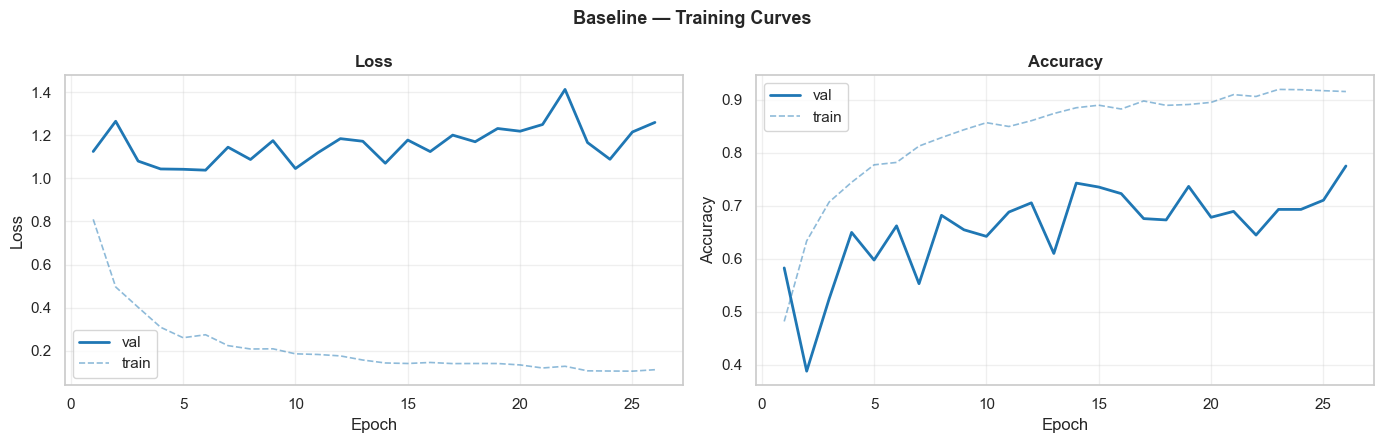

In [12]:
# ── Training & validation curves ──────────────────────────────────────────────
epochs = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(epochs, history['val_loss'],   color='#1f77b4', lw=2,   label='val')
axes[0].plot(epochs, history['train_loss'], color='#1f77b4', lw=1.2, ls='--', alpha=0.5, label='train')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss', fontweight='bold'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history['val_acc'],    color='#1f77b4', lw=2,   label='val')
axes[1].plot(epochs, history['train_acc'],  color='#1f77b4', lw=1.2, ls='--', alpha=0.5, label='train')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy', fontweight='bold'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle(f'Baseline — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 1.13 — Confusion matrix

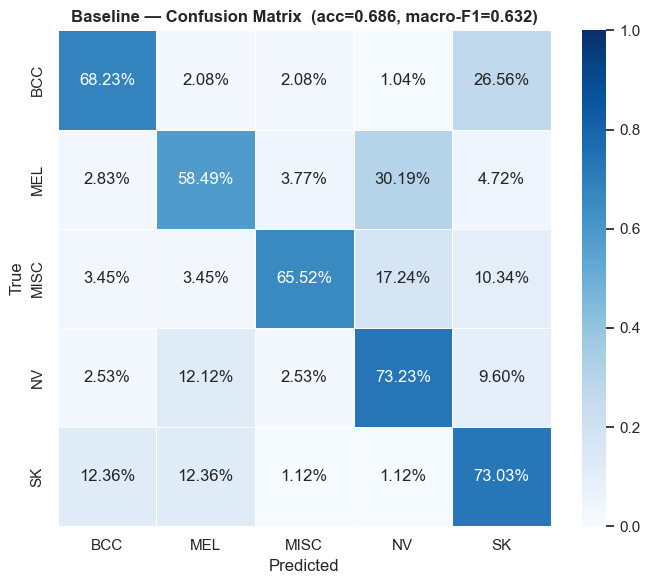

In [13]:
# ── Normalized confusion matrix ──────────────────────────────────────────────
cm_norm = confusion_matrix(y_true, y_pred, normalize='true')
plt.figure(figsize=(7, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', vmin=0, vmax=1,
            xticklabels=class_names, yticklabels=class_names, linewidths=0.5)
plt.title(f'Baseline — Confusion Matrix  (acc={metrics["accuracy"]:.3f}, '
          f'macro-F1={metrics["f1_macro"]:.3f})', fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

### 1.14 — ROC curves (one-vs-rest)

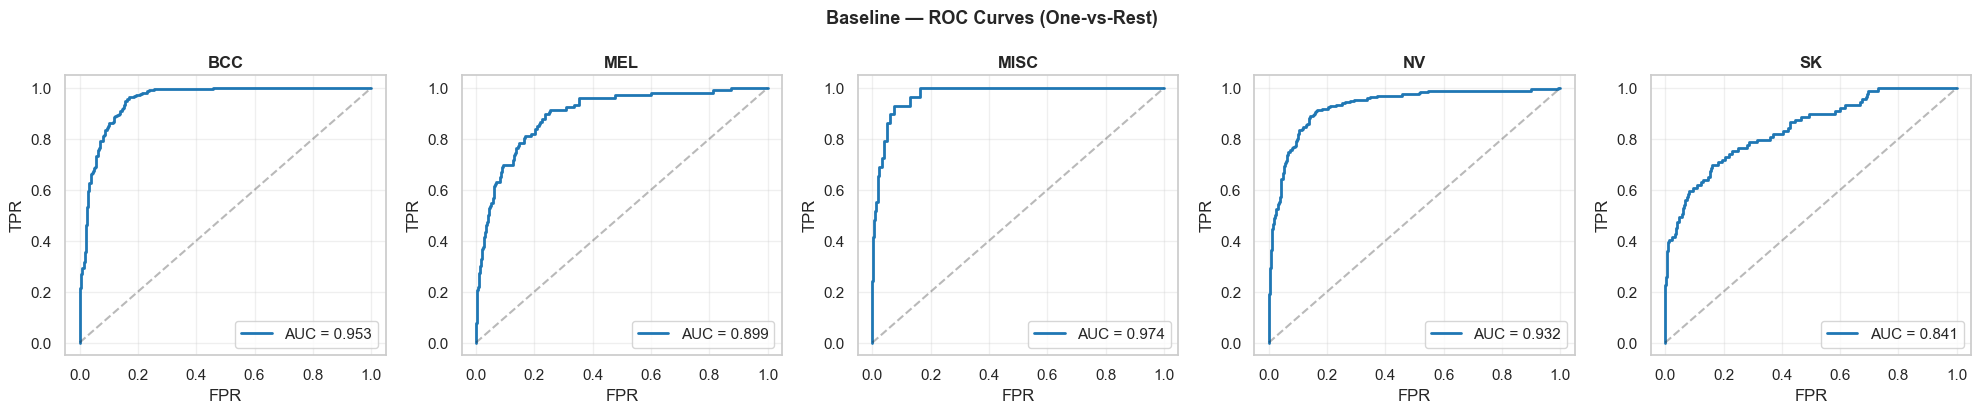

In [14]:
# ── ROC curves (one-vs-rest per class) ───────────────────────────────────────
yb = label_binarize(y_true, classes=range(len(class_names)))
fig, axes = plt.subplots(1, len(class_names), figsize=(20, 4.2))
for i, (cls, ax) in enumerate(zip(class_names, axes)):
    fpr, tpr, _ = roc_curve(yb[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color='#1f77b4', lw=2, label=f'AUC = {roc_auc:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_title(cls, fontweight='bold')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.suptitle(f'Baseline — ROC Curves (One-vs-Rest)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════
# SECTION 2 — Bidirectional Cross Attention
# ══════════════════════════════════════════════════════════════════════

**Self-contained section.** Restart kernel → run cells 2.1 → 2.15 top-to-bottom without depending on other sections.

Trains a `DualBranchBiCrossAttn`, saves to `thesis_bicross_best.pth`, then visualizes.

### 2.1 — Imports

In [15]:
import os, copy, time, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    roc_curve, auc, precision_score, recall_score, accuracy_score,
    cohen_kappa_score, matthews_corrcoef, balanced_accuracy_score,
    precision_recall_curve, average_precision_score, log_loss
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('mps' if torch.backends.mps.is_available() else
                      'cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')

DERM7PT_DIR = Path('dataset') / 'Derm7pt'
MILK_DIR    = Path('dataset') / 'milk10k'

Device: cuda
PyTorch: 2.6.0+cu124


### 2.2 — Data loading (Derm7pt + MILK10k)

In [16]:
# ── Derm7pt ──────────────────────────────────────────────────────────────────
derm_df = pd.read_csv(DERM7PT_DIR / 'meta' / 'meta.csv')
derm_df['clinic_path'] = derm_df['clinic'].apply(lambda x: str(DERM7PT_DIR / 'images' / x))
derm_df['derm_path']   = derm_df['derm'].apply(lambda x: str(DERM7PT_DIR / 'images' / x))
derm_df['diagnosis']   = derm_df['diagnosis'].str.strip().str.lower()

# ── Diagnosis grouping: 20 → 5 classes ───────────────────────────────────────
diagnosis_groups = {
    'melanoma': 'MEL', 'melanoma (less than 0.76 mm)': 'MEL', 'melanoma (in situ)': 'MEL',
    'melanoma (0.76 to 1.5 mm)': 'MEL', 'melanoma (more than 1.5 mm)': 'MEL',
    'melanoma metastasis': 'MEL',
    'clark nevus': 'NV', 'reed or spitz nevus': 'NV', 'dermal nevus': 'NV',
    'blue nevus': 'NV', 'congenital nevus': 'NV', 'combined nevus': 'NV',
    'recurrent nevus': 'NV',
    'basal cell carcinoma': 'BCC',
    'seborrheic keratosis': 'SK',
    'lentigo': 'MISC', 'dermatofibroma': 'MISC', 'vascular lesion': 'MISC',
    'melanosis': 'MISC', 'miscellaneous': 'MISC',
}
derm_df['diagnosis_group'] = derm_df['diagnosis'].map(diagnosis_groups)

class_names = sorted(derm_df['diagnosis_group'].dropna().unique())
label_map   = {name: i for i, name in enumerate(class_names)}

# ── MILK10k ──────────────────────────────────────────────────────────────────
milk_meta = pd.read_csv(MILK_DIR / 'MILK10k_Training_Metadata.csv')
milk_gt   = pd.read_csv(MILK_DIR / 'MILK10k_Training_GroundTruth.csv')

milk_class_map = {'MEL': 'MEL', 'NV': 'NV', 'BCC': 'BCC', 'BKL': 'SK', 'DF': 'MISC', 'VASC': 'MISC'}
drop_classes   = {'AKIEC', 'SCCKA', 'INF', 'BEN_OTH', 'MAL_OTH'}

gt_cols = [c for c in milk_gt.columns if c != 'lesion_id']
milk_gt['raw_class'] = milk_gt[gt_cols].idxmax(axis=1)
milk_gt = milk_gt[~milk_gt['raw_class'].isin(drop_classes)].copy()
milk_gt['diagnosis_group'] = milk_gt['raw_class'].map(milk_class_map)

clinic_meta = (milk_meta[milk_meta['image_type'] == 'clinical: close-up']
               [['lesion_id', 'isic_id']].rename(columns={'isic_id': 'clinic_isic'}))
derm_meta   = (milk_meta[milk_meta['image_type'] == 'dermoscopic']
               [['lesion_id', 'isic_id']].rename(columns={'isic_id': 'derm_isic'}))
paths = clinic_meta.merge(derm_meta, on='lesion_id')

milk_df = milk_gt[['lesion_id', 'diagnosis_group']].merge(paths, on='lesion_id')
milk_df['clinic_path'] = milk_df.apply(
    lambda r: str(MILK_DIR / 'MILK10k_Training_Input' / r['lesion_id'] / f"{r['clinic_isic']}.jpg"), axis=1)
milk_df['derm_path'] = milk_df.apply(
    lambda r: str(MILK_DIR / 'MILK10k_Training_Input' / r['lesion_id'] / f"{r['derm_isic']}.jpg"), axis=1)
milk_df['source'] = 'MILK10k'

# ── Combine Derm7pt + MILK10k ────────────────────────────────────────────────
derm7_clean = derm_df[['clinic_path', 'derm_path', 'diagnosis_group']].copy()
derm7_clean['source'] = 'Derm7pt'
combined = pd.concat(
    [derm7_clean, milk_df[['clinic_path', 'derm_path', 'diagnosis_group', 'source']]],
    ignore_index=True
)
combined['label'] = combined['diagnosis_group'].map(label_map)
df = combined.dropna(subset=['label']).reset_index(drop=True)

print(f'Combined: {len(df)} samples | {len(class_names)} classes')
print(df['diagnosis_group'].value_counts().to_string())

Combined: 5372 samples | 5 classes
diagnosis_group
BCC     2564
NV      1321
MEL      702
SK       589
MISC     196


### 2.3 — Dataset class

In [17]:
class SkinLesionDualDataset(Dataset):
    """Returns (clinic_img, derm_img, label) for each sample."""
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        clinic_img = Image.open(row['clinic_path']).convert('RGB')
        derm_img   = Image.open(row['derm_path']).convert('RGB')
        if self.transform:
            clinic_img = self.transform(clinic_img)
            derm_img   = self.transform(derm_img)
        return clinic_img, derm_img, torch.tensor(row['label'], dtype=torch.long)

### 2.4 — Transforms & stratified split

In [18]:
# ── Transforms ────────────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# ── Stratified 70/15/15 split ─────────────────────────────────────────────────
labels  = df['label'].values.astype(int)
indices = np.arange(len(df))
train_idx, temp_idx = train_test_split(indices, test_size=0.30, stratify=labels, random_state=SEED)
val_idx,  test_idx  = train_test_split(temp_idx, test_size=0.50, stratify=labels[temp_idx], random_state=SEED)

# ── Class weights ─────────────────────────────────────────────────────────────
train_labels   = labels[train_idx]
class_counts   = np.bincount(train_labels)
sample_weights = (1.0 / class_counts)[train_labels]
loss_weights   = torch.tensor(
    [len(train_labels) / (len(class_names) * c) for c in class_counts],
    dtype=torch.float32
).to(device)
print(f'Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}')
print('Loss weights:', dict(zip(class_names, loss_weights.cpu().numpy().round(3))))

Train: 3760 | Val: 806 | Test: 806
Loss weights: {'BCC': 0.419, 'MEL': 1.532, 'MISC': 5.489, 'NV': 0.813, 'SK': 1.825}


### 2.5 — DataLoaders

In [19]:
# ── DataLoaders ──────────────────────────────────────────────────────────────
_NUM_WORKERS = 0 if device.type in ('mps', 'cpu') or os.name == 'nt' else min(8, os.cpu_count() or 4)
_PIN_MEMORY  = device.type == 'cuda'

def make_loaders(batch_size=32):
    train_ds = SkinLesionDualDataset(df.iloc[train_idx], train_transform)
    val_ds   = SkinLesionDualDataset(df.iloc[val_idx],   val_transform)
    test_ds  = SkinLesionDualDataset(df.iloc[test_idx],  val_transform)
    samp = WeightedRandomSampler(sample_weights, len(train_labels), replacement=True)
    kw = dict(num_workers=_NUM_WORKERS, pin_memory=_PIN_MEMORY,
              persistent_workers=(_NUM_WORKERS > 0))
    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=samp, **kw)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, **kw)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, **kw)
    return train_loader, val_loader, test_loader, test_ds

### 2.6 — ResNet50 backbone

In [20]:
class ResNet50Backbone(nn.Module):
    """ResNet50 feature extractor — returns spatial feature maps [B, 2048, 7, 7]."""
    def __init__(self, pretrained=True):
        super().__init__()
        base = models.resnet50(weights=models.ResNet50_Weights.DEFAULT if pretrained else None)
        self.features = nn.Sequential(
            base.conv1, base.bn1, base.relu, base.maxpool,
            base.layer1, base.layer2, base.layer3, base.layer4
        )

    def forward(self, x):
        return self.features(x)

### 2.7 — Hyperparameters & loaders

In [21]:
# ── Fixed hyperparameters ─────────────────────────────────────────────────────
LR             = 0.000750
DROPOUT        = 0.32
NUM_HEADS      = 4
EMBED_DIM      = 256
WEIGHT_DECAY   = 0.000957
BATCH_SIZE     = 64
FINAL_EPOCHS   = 60
PATIENCE       = 20
UNFREEZE_EPOCH = 5
GRAD_CLIP      = 1.0

train_loader, val_loader, test_loader, test_ds = make_loaders(BATCH_SIZE)
print(f'Loaders: train={len(train_loader.dataset):,}  val={len(val_loader.dataset):,}  test={len(test_loader.dataset):,}')

Loaders: train=3,760  val=806  test=806


### 2.8 — Model: BiCrossAttn

In [22]:
class CrossAttentionFusion(nn.Module):
    """
    Unidirectional cross-attention building block.
      Q  ← projected clinical features
      K,V ← projected dermoscopic features
    Returns fused [B, embed_dim] vector and attention weights [B, 49, 49].
    """
    def __init__(self, in_dim=2048, embed_dim=512, num_heads=8, dropout=0.1):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.q_proj = nn.Linear(in_dim, embed_dim)
        self.k_proj = nn.Linear(in_dim, embed_dim)
        self.v_proj = nn.Linear(in_dim, embed_dim)
        self.attn   = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm1  = nn.LayerNorm(embed_dim)
        self.ffn    = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim * 2, embed_dim),
        )
        self.norm2 = nn.LayerNorm(embed_dim)
        self.pool  = nn.AdaptiveAvgPool1d(1)

    def forward(self, clinic_feat, derm_feat):
        c = clinic_feat.flatten(2).transpose(1, 2)
        d = derm_feat.flatten(2).transpose(1, 2)
        Q = self.q_proj(c); K = self.k_proj(d); V = self.v_proj(d)
        attn_out, attn_weights = self.attn(Q, K, V, need_weights=True, average_attn_weights=True)
        x = self.norm1(Q + attn_out)
        x = self.norm2(x + self.ffn(x))
        fused = self.pool(x.transpose(1, 2)).squeeze(-1)
        return fused, attn_weights


class BidirectionalCrossAttnFusion(nn.Module):
    """Bidirectional cross-attention:  clinic→derm + derm→clinic, concat then project."""
    def __init__(self, in_dim=2048, embed_dim=256, num_heads=4, dropout=0.32):
        super().__init__()
        self.c2d  = CrossAttentionFusion(in_dim, embed_dim, num_heads, dropout)
        self.d2c  = CrossAttentionFusion(in_dim, embed_dim, num_heads, dropout)
        self.proj = nn.Linear(embed_dim * 2, embed_dim)

    def forward(self, clinic_feat, derm_feat):
        fused_c2d, attn_c2d = self.c2d(clinic_feat, derm_feat)
        fused_d2c, attn_d2c = self.d2c(derm_feat, clinic_feat)
        fused = self.proj(torch.cat([fused_c2d, fused_d2c], dim=1))
        return fused, (attn_c2d, attn_d2c)


class DualBranchBiCrossAttn(nn.Module):
    """Bidirectional cross-attention fusion (no channel attention)."""
    def __init__(self, num_classes=5, embed_dim=256, num_heads=4, dropout=0.32):
        super().__init__()
        self.resnet_clinic = ResNet50Backbone(pretrained=True)
        self.resnet_derm   = ResNet50Backbone(pretrained=True)
        self.fusion        = BidirectionalCrossAttnFusion(
            in_dim=2048, embed_dim=embed_dim, num_heads=num_heads, dropout=dropout
        )
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.BatchNorm1d(embed_dim // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(embed_dim // 2, num_classes),
        )

    def _freeze_backbones(self):
        for m in [self.resnet_clinic, self.resnet_derm]:
            for p in m.parameters(): p.requires_grad = False
            for p in m.features[7].parameters(): p.requires_grad = True

    def unfreeze_resnets(self):
        for m in [self.resnet_clinic, self.resnet_derm]:
            for p in m.features[6].parameters(): p.requires_grad = True

    def forward(self, clinic_img, derm_img):
        feat_c = self.resnet_clinic(clinic_img)
        feat_d = self.resnet_derm(derm_img)
        fused, attn_weights = self.fusion(feat_c, feat_d)
        return self.classifier(fused), attn_weights


# Parameter count
_m = DualBranchBiCrossAttn(num_classes=len(class_names), embed_dim=EMBED_DIM,
                            num_heads=NUM_HEADS, dropout=DROPOUT)
_m._freeze_backbones()
total     = sum(p.numel() for p in _m.parameters())
trainable = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'BiCrossAttn: {total:,} total params, {trainable:,} trainable in warm-up ({trainable/total*100:.1f}%)')
del _m

BiCrossAttn: 51,382,661 total params, 34,296,069 trainable in warm-up (66.7%)


### 2.9 — EarlyStopping + train/validate helpers

In [23]:
class EarlyStopping:
    """Stops training if val_loss doesn't improve for `patience` consecutive epochs."""
    def __init__(self, patience=20, min_delta=1e-4):
        self.patience  = patience
        self.min_delta = min_delta
        self.counter   = 0
        self.best_loss = float('inf')
        self.best_state = None
        self.stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter    = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

    def restore(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


def train_one_epoch(model, loader, optimizer, criterion, grad_clip):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for clinic_imgs, derm_imgs, labels_batch in loader:
        clinic_imgs  = clinic_imgs.to(device)
        derm_imgs    = derm_imgs.to(device)
        labels_batch = labels_batch.to(device)
        optimizer.zero_grad()
        logits, _ = model(clinic_imgs, derm_imgs)
        loss      = criterion(logits, labels_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        total_loss += loss.item() * clinic_imgs.size(0)
        correct    += logits.argmax(1).eq(labels_batch).sum().item()
        total      += clinic_imgs.size(0)
    return total_loss / total, correct / total


def validate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for clinic_imgs, derm_imgs, labels_batch in loader:
            clinic_imgs  = clinic_imgs.to(device)
            derm_imgs    = derm_imgs.to(device)
            labels_batch = labels_batch.to(device)
            logits, _    = model(clinic_imgs, derm_imgs)
            loss         = criterion(logits, labels_batch)
            total_loss  += loss.item() * clinic_imgs.size(0)
            correct     += logits.argmax(1).eq(labels_batch).sum().item()
            total       += clinic_imgs.size(0)
    return total_loss / total, correct / total

### 2.10 — Training

In [24]:
# ── Train BiCrossAttn ───────────────────────────────────────────────────────
model = DualBranchBiCrossAttn(num_classes=len(class_names), embed_dim=EMBED_DIM, num_heads=NUM_HEADS, dropout=DROPOUT).to(device)
model._freeze_backbones()

criterion  = nn.CrossEntropyLoss(weight=loss_weights)
optimizer  = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY
)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=UNFREEZE_EPOCH)
early_stop = EarlyStopping(patience=PATIENCE)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
early_stop_epoch = None
start = time.time()

for epoch in range(FINAL_EPOCHS):
    if epoch == UNFREEZE_EPOCH:
        model.unfreeze_resnets()
        optimizer = optim.Adam(model.parameters(), lr=LR / 4, weight_decay=WEIGHT_DECAY)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=FINAL_EPOCHS - UNFREEZE_EPOCH
        )
        print(f'  Epoch {epoch+1}: unfroze layer3+4, lr → {LR/4:.2e}')

    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, GRAD_CLIP)
    va_loss, va_acc = validate(model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)

    early_stop(va_loss, model)
    print(f'  Ep {epoch+1:2d}/{FINAL_EPOCHS} | '
          f'train {tr_loss:.4f}/{tr_acc:.4f} | val {va_loss:.4f}/{va_acc:.4f} | '
          f'es {early_stop.counter}/{PATIENCE}')

    if early_stop.stop:
        early_stop_epoch = epoch + 1
        print(f'  → Early stop at epoch {early_stop_epoch}. Restoring best weights.')
        early_stop.restore(model)
        break

elapsed = (time.time() - start) / 60
print(f'\nDone in {elapsed:.1f} min | best val loss: {early_stop.best_loss:.4f}')

torch.save({
    'model_state_dict': model.state_dict(),
    'class_names':      class_names,
    'label_map':        label_map,
    'history':          history,
    'best_val_loss':    early_stop.best_loss,
    'early_stop_epoch': early_stop_epoch,
}, 'thesis_bicross_best.pth')
print(f'Saved: thesis_bicross_best.pth')

  Ep  1/60 | train 0.7888/0.5000 | val 1.3972/0.2357 | es 0/20
  Ep  2/60 | train 0.5619/0.6019 | val 1.2634/0.2916 | es 0/20
  Ep  3/60 | train 0.4302/0.6660 | val 0.9765/0.5757 | es 0/20
  Ep  4/60 | train 0.3626/0.7074 | val 0.8336/0.7159 | es 0/20
  Ep  5/60 | train 0.2916/0.7652 | val 0.8815/0.6117 | es 1/20
  Epoch 6: unfroze layer3+4, lr → 1.88e-04
  Ep  6/60 | train 0.2991/0.7668 | val 0.8695/0.6886 | es 2/20
  Ep  7/60 | train 0.2806/0.7848 | val 0.8432/0.6836 | es 3/20
  Ep  8/60 | train 0.2524/0.7910 | val 0.9001/0.6849 | es 4/20
  Ep  9/60 | train 0.2195/0.8306 | val 0.8822/0.6960 | es 5/20
  Ep 10/60 | train 0.2076/0.8426 | val 1.0760/0.6166 | es 6/20
  Ep 11/60 | train 0.1992/0.8481 | val 0.9900/0.6489 | es 7/20
  Ep 12/60 | train 0.1630/0.8689 | val 1.0594/0.6117 | es 8/20
  Ep 13/60 | train 0.1698/0.8734 | val 1.0813/0.5670 | es 9/20
  Ep 14/60 | train 0.1579/0.8747 | val 1.0199/0.6824 | es 10/20
  Ep 15/60 | train 0.1487/0.8931 | val 0.9685/0.7196 | es 11/20
  Ep 16/60

### 2.11 — Evaluation

In [25]:
# ── Evaluate on test set ──────────────────────────────────────────────────────
# Reload best checkpoint to make this cell self-contained
ckpt = torch.load('thesis_bicross_best.pth', map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

preds_list, labels_list, probs_list, attn_list = [], [], [], []
with torch.no_grad():
    for clinic_imgs, derm_imgs, lb in test_loader:
        logits, attn_w = model(clinic_imgs.to(device), derm_imgs.to(device))
        probs = F.softmax(logits, dim=1)
        preds_list.extend(logits.argmax(1).cpu().numpy())
        labels_list.extend(lb.numpy())
        probs_list.extend(probs.cpu().numpy())
        if attn_w is not None:
            aw = attn_w[0] if isinstance(attn_w, tuple) else attn_w
            attn_list.extend(aw.cpu().numpy())

y_true  = np.array(labels_list)
y_pred  = np.array(preds_list)
y_probs = np.array(probs_list)
attn_arr = np.array(attn_list) if attn_list else None

metrics = {
    'accuracy':          accuracy_score(y_true, y_pred),
    'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
    'f1_macro':          f1_score(y_true, y_pred, average='macro',    zero_division=0),
    'f1_weighted':       f1_score(y_true, y_pred, average='weighted', zero_division=0),
    'cohen_kappa':       cohen_kappa_score(y_true, y_pred),
    'mcc':               matthews_corrcoef(y_true, y_pred),
    'log_loss':          log_loss(y_true, y_probs),
}

print('Test-set metrics:')
for k, v in metrics.items():
    print(f'  {k:<20}: {v:.4f}')

print('\nPer-class report:')
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

Test-set metrics:
  accuracy            : 0.7395
  balanced_accuracy   : 0.7037
  f1_macro            : 0.6765
  f1_weighted         : 0.7488
  cohen_kappa         : 0.6310
  mcc                 : 0.6342
  log_loss            : 0.7480

Per-class report:
              precision    recall  f1-score   support

         BCC       0.91      0.78      0.84       384
         MEL       0.54      0.65      0.59       106
        MISC       0.62      0.72      0.67        29
          NV       0.77      0.78      0.78       198
          SK       0.45      0.58      0.51        89

    accuracy                           0.74       806
   macro avg       0.66      0.70      0.68       806
weighted avg       0.77      0.74      0.75       806



### 2.12 — Training curves

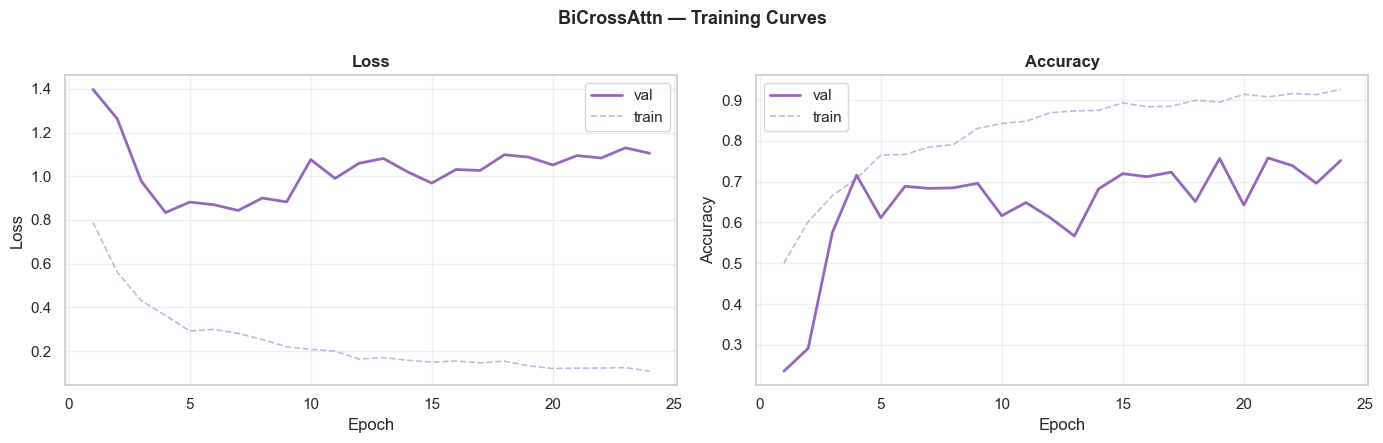

In [26]:
# ── Training & validation curves ──────────────────────────────────────────────
epochs = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(epochs, history['val_loss'],   color='#9467bd', lw=2,   label='val')
axes[0].plot(epochs, history['train_loss'], color='#9467bd', lw=1.2, ls='--', alpha=0.5, label='train')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss', fontweight='bold'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history['val_acc'],    color='#9467bd', lw=2,   label='val')
axes[1].plot(epochs, history['train_acc'],  color='#9467bd', lw=1.2, ls='--', alpha=0.5, label='train')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy', fontweight='bold'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle(f'BiCrossAttn — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 2.13 — Confusion matrix

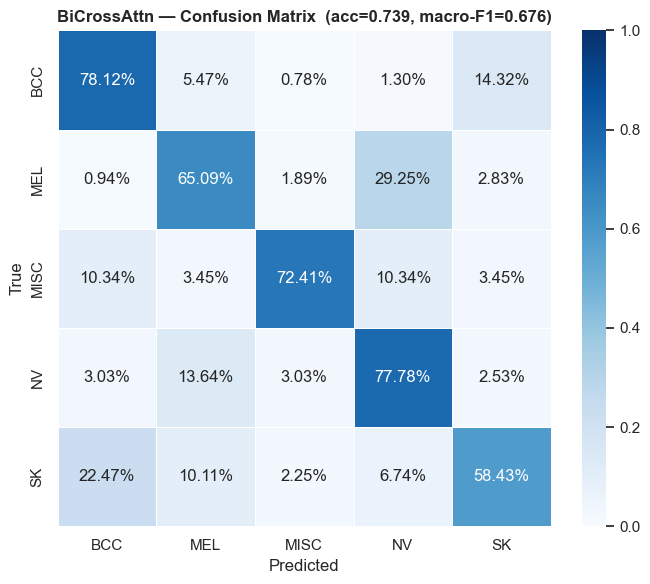

In [27]:
# ── Normalized confusion matrix ──────────────────────────────────────────────
cm_norm = confusion_matrix(y_true, y_pred, normalize='true')
plt.figure(figsize=(7, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', vmin=0, vmax=1,
            xticklabels=class_names, yticklabels=class_names, linewidths=0.5)
plt.title(f'BiCrossAttn — Confusion Matrix  (acc={metrics["accuracy"]:.3f}, '
          f'macro-F1={metrics["f1_macro"]:.3f})', fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

### 2.14 — ROC curves (one-vs-rest)

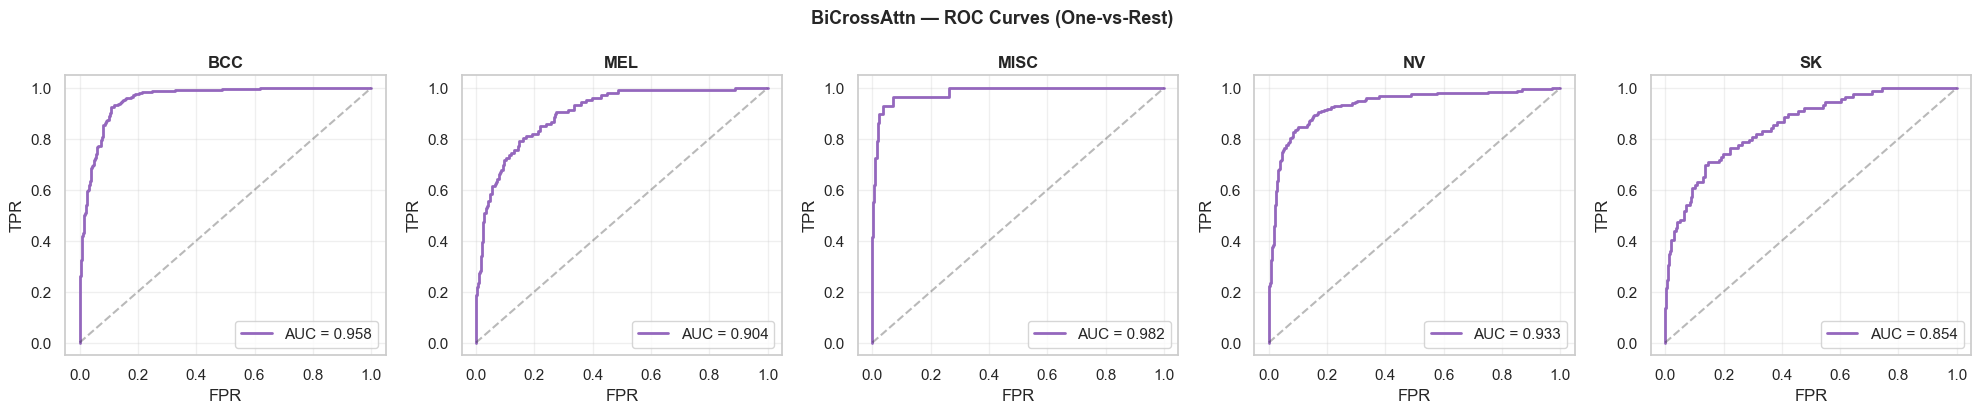

In [28]:
# ── ROC curves (one-vs-rest per class) ───────────────────────────────────────
yb = label_binarize(y_true, classes=range(len(class_names)))
fig, axes = plt.subplots(1, len(class_names), figsize=(20, 4.2))
for i, (cls, ax) in enumerate(zip(class_names, axes)):
    fpr, tpr, _ = roc_curve(yb[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color='#9467bd', lw=2, label=f'AUC = {roc_auc:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_title(cls, fontweight='bold')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.suptitle(f'BiCrossAttn — ROC Curves (One-vs-Rest)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 2.15 — Attention visualization

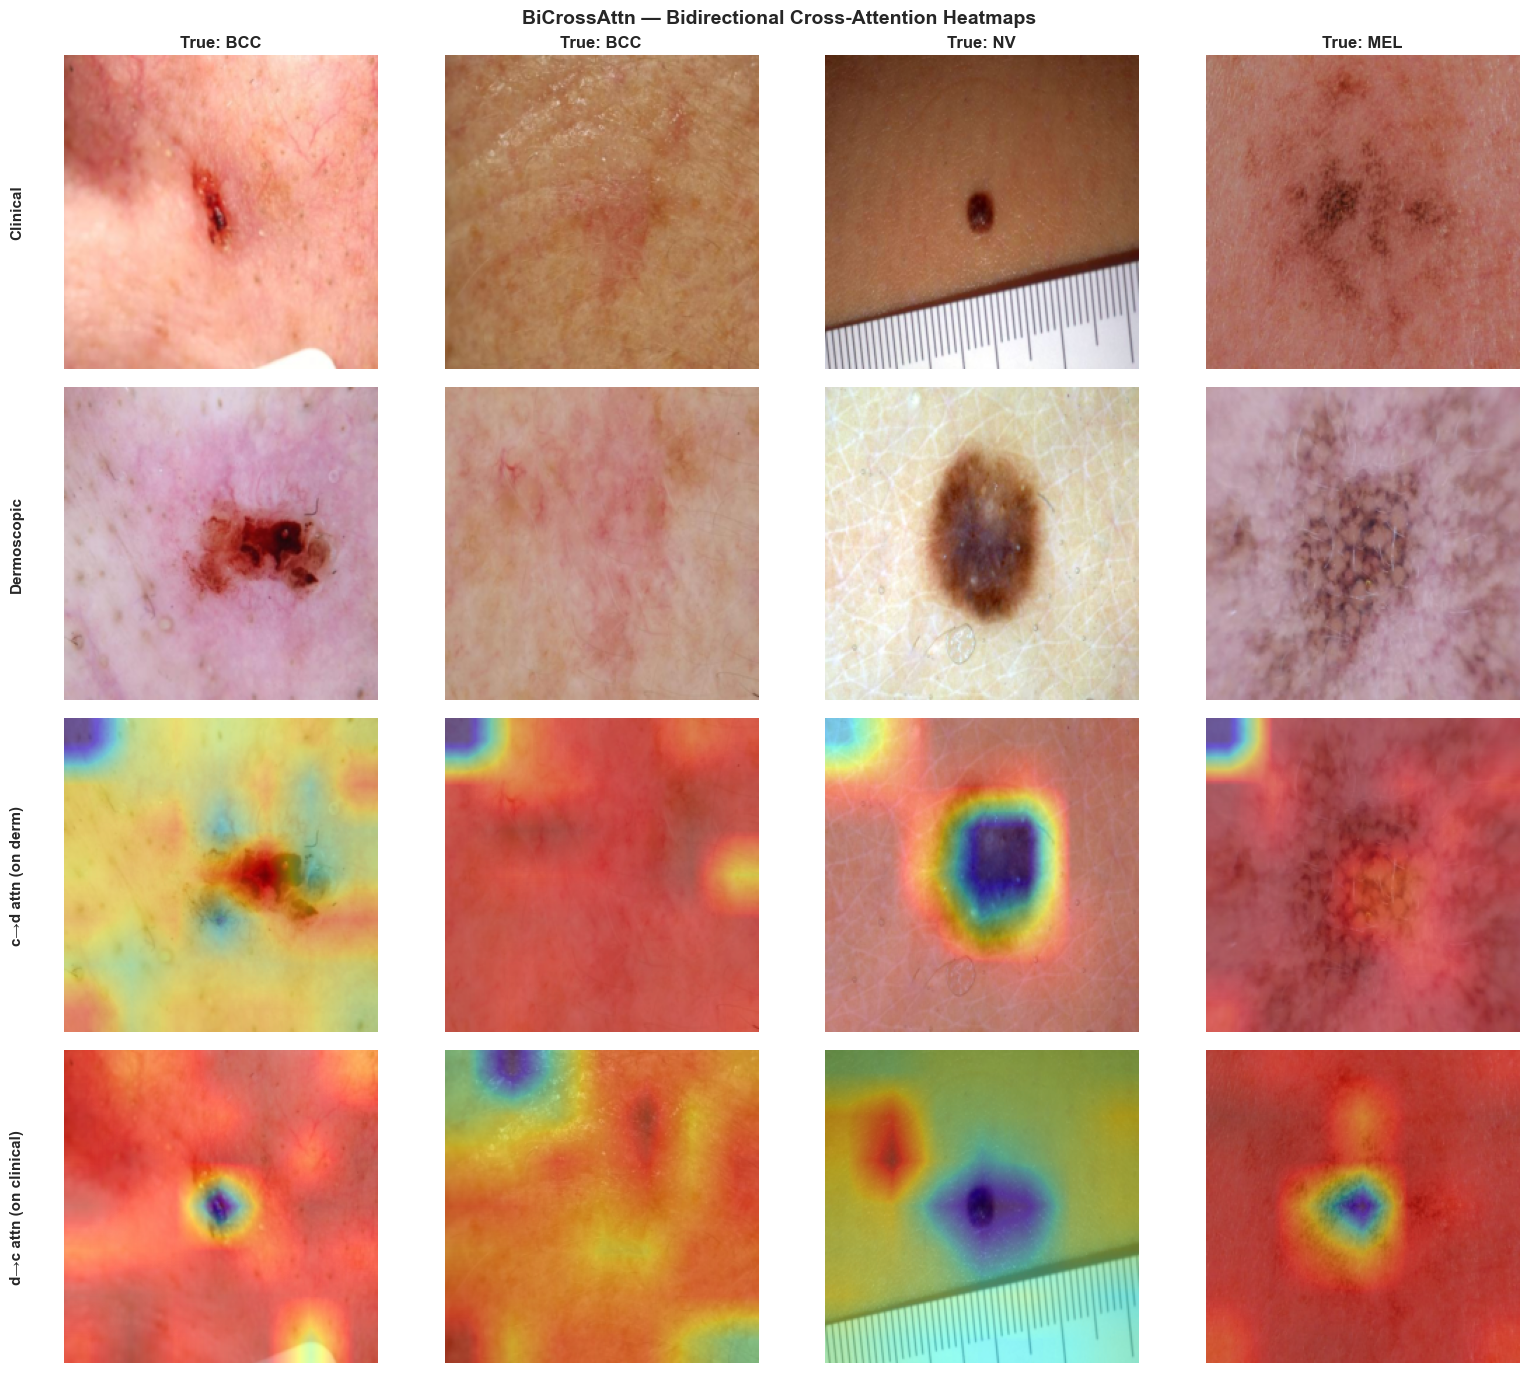

In [29]:
# ── Bidirectional cross-attention heatmaps ───────────────────────────────────
# attn_arr is the c→d direction stored during eval. Also re-run a forward pass
# to grab the d→c direction for visualization.
inv_norm = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

n_show = 4
s_idx  = np.linspace(0, len(test_ds) - 1, n_show, dtype=int)

# Collect both attention directions for the chosen samples
attn_c2d_list, attn_d2c_list, clinic_imgs_disp, derm_imgs_disp, sample_labels = [], [], [], [], []
model.eval()
with torch.no_grad():
    for idx in s_idx:
        clinic_t, derm_t, label = test_ds[idx]
        _, attn_pair = model(clinic_t.unsqueeze(0).to(device), derm_t.unsqueeze(0).to(device))
        attn_c2d_list.append(attn_pair[0].squeeze(0).cpu().numpy())
        attn_d2c_list.append(attn_pair[1].squeeze(0).cpu().numpy())
        clinic_imgs_disp.append(inv_norm(clinic_t).permute(1, 2, 0).clamp(0, 1).numpy())
        derm_imgs_disp.append(inv_norm(derm_t).permute(1, 2, 0).clamp(0, 1).numpy())
        sample_labels.append(class_names[label.item() if hasattr(label, 'item') else int(label)])

fig, axes = plt.subplots(4, n_show, figsize=(4 * n_show, 14))
for col in range(n_show):
    axes[0, col].imshow(clinic_imgs_disp[col]); axes[0, col].axis('off')
    axes[0, col].set_title(f'True: {sample_labels[col]}', fontweight='bold')

    axes[1, col].imshow(derm_imgs_disp[col]); axes[1, col].axis('off')

    # c→d : clinical queries attending to derm regions → overlay on derm image
    a_c2d = attn_c2d_list[col].mean(axis=0).reshape(7, 7)
    a_c2d = (a_c2d - a_c2d.min()) / (a_c2d.max() - a_c2d.min() + 1e-8)
    a_c2d_up = np.array(Image.fromarray((a_c2d * 255).astype(np.uint8))
                        .resize((224, 224), Image.BILINEAR)) / 255.0
    axes[2, col].imshow(derm_imgs_disp[col])
    axes[2, col].imshow(a_c2d_up, cmap='jet', alpha=0.45); axes[2, col].axis('off')

    # d→c : derm queries attending to clinical regions → overlay on clinical image
    a_d2c = attn_d2c_list[col].mean(axis=0).reshape(7, 7)
    a_d2c = (a_d2c - a_d2c.min()) / (a_d2c.max() - a_d2c.min() + 1e-8)
    a_d2c_up = np.array(Image.fromarray((a_d2c * 255).astype(np.uint8))
                        .resize((224, 224), Image.BILINEAR)) / 255.0
    axes[3, col].imshow(clinic_imgs_disp[col])
    axes[3, col].imshow(a_d2c_up, cmap='jet', alpha=0.45); axes[3, col].axis('off')

for ax, lbl in zip(axes[:, 0], ['Clinical', 'Dermoscopic', 'c→d attn (on derm)', 'd→c attn (on clinical)']):
    ax.text(-0.15, 0.5, lbl, transform=ax.transAxes, rotation=90,
            va='center', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('BiCrossAttn — Bidirectional Cross-Attention Heatmaps',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════
# SECTION 3 — Channel Attention (SE-ResNet, official design)
# ══════════════════════════════════════════════════════════════════════

**Self-contained section.** Restart kernel, then run cells 3.1 through 3.15 top-to-bottom without depending on other sections.

Implements the SE-ResNet design from Hu et al. 2018: SE blocks (GlobalAvgPool → FC → ReLU → FC → Sigmoid) sit **inside every residual block**, scaling channels before the skip-connection sum. No max pooling. Trains a `DualBranchSEResNet`, saves to `thesis_channel_best.pth`, then visualizes the SE weights from the last block of layer4.

### 3.1 — Imports

In [30]:
import os, copy, time, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    roc_curve, auc, precision_score, recall_score, accuracy_score,
    cohen_kappa_score, matthews_corrcoef, balanced_accuracy_score,
    precision_recall_curve, average_precision_score, log_loss
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('mps' if torch.backends.mps.is_available() else
                      'cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')

DERM7PT_DIR = Path('dataset') / 'Derm7pt'
MILK_DIR    = Path('dataset') / 'milk10k'

Device: cuda
PyTorch: 2.6.0+cu124


### 3.2 — Data loading (Derm7pt + MILK10k)

In [31]:
# ── Derm7pt ──────────────────────────────────────────────────────────────────
derm_df = pd.read_csv(DERM7PT_DIR / 'meta' / 'meta.csv')
derm_df['clinic_path'] = derm_df['clinic'].apply(lambda x: str(DERM7PT_DIR / 'images' / x))
derm_df['derm_path']   = derm_df['derm'].apply(lambda x: str(DERM7PT_DIR / 'images' / x))
derm_df['diagnosis']   = derm_df['diagnosis'].str.strip().str.lower()

# ── Diagnosis grouping: 20 → 5 classes ───────────────────────────────────────
diagnosis_groups = {
    'melanoma': 'MEL', 'melanoma (less than 0.76 mm)': 'MEL', 'melanoma (in situ)': 'MEL',
    'melanoma (0.76 to 1.5 mm)': 'MEL', 'melanoma (more than 1.5 mm)': 'MEL',
    'melanoma metastasis': 'MEL',
    'clark nevus': 'NV', 'reed or spitz nevus': 'NV', 'dermal nevus': 'NV',
    'blue nevus': 'NV', 'congenital nevus': 'NV', 'combined nevus': 'NV',
    'recurrent nevus': 'NV',
    'basal cell carcinoma': 'BCC',
    'seborrheic keratosis': 'SK',
    'lentigo': 'MISC', 'dermatofibroma': 'MISC', 'vascular lesion': 'MISC',
    'melanosis': 'MISC', 'miscellaneous': 'MISC',
}
derm_df['diagnosis_group'] = derm_df['diagnosis'].map(diagnosis_groups)

class_names = sorted(derm_df['diagnosis_group'].dropna().unique())
label_map   = {name: i for i, name in enumerate(class_names)}

# ── MILK10k ──────────────────────────────────────────────────────────────────
milk_meta = pd.read_csv(MILK_DIR / 'MILK10k_Training_Metadata.csv')
milk_gt   = pd.read_csv(MILK_DIR / 'MILK10k_Training_GroundTruth.csv')

milk_class_map = {'MEL': 'MEL', 'NV': 'NV', 'BCC': 'BCC', 'BKL': 'SK', 'DF': 'MISC', 'VASC': 'MISC'}
drop_classes   = {'AKIEC', 'SCCKA', 'INF', 'BEN_OTH', 'MAL_OTH'}

gt_cols = [c for c in milk_gt.columns if c != 'lesion_id']
milk_gt['raw_class'] = milk_gt[gt_cols].idxmax(axis=1)
milk_gt = milk_gt[~milk_gt['raw_class'].isin(drop_classes)].copy()
milk_gt['diagnosis_group'] = milk_gt['raw_class'].map(milk_class_map)

clinic_meta = (milk_meta[milk_meta['image_type'] == 'clinical: close-up']
               [['lesion_id', 'isic_id']].rename(columns={'isic_id': 'clinic_isic'}))
derm_meta   = (milk_meta[milk_meta['image_type'] == 'dermoscopic']
               [['lesion_id', 'isic_id']].rename(columns={'isic_id': 'derm_isic'}))
paths = clinic_meta.merge(derm_meta, on='lesion_id')

milk_df = milk_gt[['lesion_id', 'diagnosis_group']].merge(paths, on='lesion_id')
milk_df['clinic_path'] = milk_df.apply(
    lambda r: str(MILK_DIR / 'MILK10k_Training_Input' / r['lesion_id'] / f"{r['clinic_isic']}.jpg"), axis=1)
milk_df['derm_path'] = milk_df.apply(
    lambda r: str(MILK_DIR / 'MILK10k_Training_Input' / r['lesion_id'] / f"{r['derm_isic']}.jpg"), axis=1)
milk_df['source'] = 'MILK10k'

# ── Combine Derm7pt + MILK10k ────────────────────────────────────────────────
derm7_clean = derm_df[['clinic_path', 'derm_path', 'diagnosis_group']].copy()
derm7_clean['source'] = 'Derm7pt'
combined = pd.concat(
    [derm7_clean, milk_df[['clinic_path', 'derm_path', 'diagnosis_group', 'source']]],
    ignore_index=True
)
combined['label'] = combined['diagnosis_group'].map(label_map)
df = combined.dropna(subset=['label']).reset_index(drop=True)

print(f'Combined: {len(df)} samples | {len(class_names)} classes')
print(df['diagnosis_group'].value_counts().to_string())

Combined: 5372 samples | 5 classes
diagnosis_group
BCC     2564
NV      1321
MEL      702
SK       589
MISC     196


### 3.3 — Dataset class

In [32]:
class SkinLesionDualDataset(Dataset):
    """Returns (clinic_img, derm_img, label) for each sample."""
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        clinic_img = Image.open(row['clinic_path']).convert('RGB')
        derm_img   = Image.open(row['derm_path']).convert('RGB')
        if self.transform:
            clinic_img = self.transform(clinic_img)
            derm_img   = self.transform(derm_img)
        return clinic_img, derm_img, torch.tensor(row['label'], dtype=torch.long)

### 3.4 — Transforms & stratified split

In [33]:
# ── Transforms ────────────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# ── Stratified 70/15/15 split ─────────────────────────────────────────────────
labels  = df['label'].values.astype(int)
indices = np.arange(len(df))
train_idx, temp_idx = train_test_split(indices, test_size=0.30, stratify=labels, random_state=SEED)
val_idx,  test_idx  = train_test_split(temp_idx, test_size=0.50, stratify=labels[temp_idx], random_state=SEED)

# ── Class weights ─────────────────────────────────────────────────────────────
train_labels   = labels[train_idx]
class_counts   = np.bincount(train_labels)
sample_weights = (1.0 / class_counts)[train_labels]
loss_weights   = torch.tensor(
    [len(train_labels) / (len(class_names) * c) for c in class_counts],
    dtype=torch.float32
).to(device)
print(f'Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}')
print('Loss weights:', dict(zip(class_names, loss_weights.cpu().numpy().round(3))))

Train: 3760 | Val: 806 | Test: 806
Loss weights: {'BCC': 0.419, 'MEL': 1.532, 'MISC': 5.489, 'NV': 0.813, 'SK': 1.825}


### 3.5 — DataLoaders

In [34]:
# ── DataLoaders ──────────────────────────────────────────────────────────────
_NUM_WORKERS = 0 if device.type in ('mps', 'cpu') or os.name == 'nt' else min(8, os.cpu_count() or 4)
_PIN_MEMORY  = device.type == 'cuda'

def make_loaders(batch_size=32):
    train_ds = SkinLesionDualDataset(df.iloc[train_idx], train_transform)
    val_ds   = SkinLesionDualDataset(df.iloc[val_idx],   val_transform)
    test_ds  = SkinLesionDualDataset(df.iloc[test_idx],  val_transform)
    samp = WeightedRandomSampler(sample_weights, len(train_labels), replacement=True)
    kw = dict(num_workers=_NUM_WORKERS, pin_memory=_PIN_MEMORY,
              persistent_workers=(_NUM_WORKERS > 0))
    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=samp, **kw)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, **kw)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, **kw)
    return train_loader, val_loader, test_loader, test_ds

### 3.6 — SE-ResNet50 backbone

In [35]:
class SEBlock(nn.Module):
    """
    Official SE block (Hu et al. CVPR 2018):
        x → GlobalAvgPool → FC(C → C/r) → ReLU → FC(C/r → C) → Sigmoid → scale x
    No max pooling.
    """
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, _, _ = x.shape
        w = self.sigmoid(self.fc(self.avg_pool(x).view(b, c))).view(b, c, 1, 1)
        return x * w


class SEBottleneck(nn.Module):
    """
    Wraps a torchvision ResNet Bottleneck and injects an SE block on the residual
    branch, BEFORE the skip-connection sum — matching the SE-ResNet figure.
    """
    def __init__(self, bottleneck, reduction=16):
        super().__init__()
        self.block = bottleneck   # original Bottleneck (pretrained conv/bn preserved)
        self.se    = SEBlock(bottleneck.conv3.out_channels, reduction)

    def forward(self, x):
        identity = x
        out = self.block.conv1(x); out = self.block.bn1(out); out = self.block.relu(out)
        out = self.block.conv2(out); out = self.block.bn2(out); out = self.block.relu(out)
        out = self.block.conv3(out); out = self.block.bn3(out)
        out = self.se(out)        # ← SE scaling on residual branch
        if self.block.downsample is not None:
            identity = self.block.downsample(x)
        out = out + identity
        return self.block.relu(out)


class SEResNet50Backbone(nn.Module):
    """
    ResNet50 with SE blocks injected into every residual block (layer1–layer4).
    Returns spatial feature maps [B, 2048, 7, 7] just like the vanilla backbone.
    Pretrained ImageNet weights are preserved on the conv/bn layers;
    only the SE blocks are randomly initialized.
    """
    def __init__(self, pretrained=True, reduction=16):
        super().__init__()
        base = models.resnet50(weights=models.ResNet50_Weights.DEFAULT if pretrained else None)
        # Wrap every Bottleneck in layer1–layer4 with SE
        for layer in [base.layer1, base.layer2, base.layer3, base.layer4]:
            for i in range(len(layer)):
                layer[i] = SEBottleneck(layer[i], reduction=reduction)
        self.features = nn.Sequential(
            base.conv1, base.bn1, base.relu, base.maxpool,
            base.layer1, base.layer2, base.layer3, base.layer4
        )

    def forward(self, x):
        return self.features(x)

### 3.7 — Hyperparameters & loaders

In [36]:
# ── Fixed hyperparameters ─────────────────────────────────────────────────────
LR             = 0.000750
DROPOUT        = 0.32
NUM_HEADS      = 4
EMBED_DIM      = 256
WEIGHT_DECAY   = 0.000957
BATCH_SIZE     = 64
FINAL_EPOCHS   = 60
PATIENCE       = 20
UNFREEZE_EPOCH = 5
GRAD_CLIP      = 1.0

train_loader, val_loader, test_loader, test_ds = make_loaders(BATCH_SIZE)
print(f'Loaders: train={len(train_loader.dataset):,}  val={len(val_loader.dataset):,}  test={len(test_loader.dataset):,}')

Loaders: train=3,760  val=806  test=806


### 3.8 — Model: DualBranchSEResNet

In [37]:
class DualBranchSEResNet(nn.Module):
    """
    Dual-branch SE-ResNet50 — SE attention is inside every residual block of each
    backbone (not applied separately after the backbone). Outputs are concatenated
    and fused with Conv1×1, then classified.
    """
    def __init__(self, num_classes=5, dropout=0.32):
        super().__init__()
        self.resnet_clinic = SEResNet50Backbone(pretrained=True)
        self.resnet_derm   = SEResNet50Backbone(pretrained=True)
        self.fusion = nn.Sequential(
            nn.Conv2d(4096, 1024, kernel_size=1, bias=False),
            nn.BatchNorm2d(1024),
            nn.ReLU(inplace=True),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def _freeze_backbones(self):
        """Warm-up freezing: freeze pretrained conv/bn except layer4. Keep ALL
        SE blocks trainable (they are new, randomly initialized parameters)."""
        for m in [self.resnet_clinic, self.resnet_derm]:
            for p in m.parameters():
                p.requires_grad = False
            # Unfreeze layer4
            for p in m.features[7].parameters():
                p.requires_grad = True
            # Unfreeze ALL SE blocks (in every layer) — they need to learn from scratch
            for module in m.modules():
                if isinstance(module, SEBlock):
                    for p in module.parameters():
                        p.requires_grad = True

    def unfreeze_resnets(self):
        """Fine-tuning phase: unfreeze layer3 (layer4 + SE already trainable)."""
        for m in [self.resnet_clinic, self.resnet_derm]:
            for p in m.features[6].parameters():
                p.requires_grad = True

    def forward(self, clinic_img, derm_img):
        feat_c = self.resnet_clinic(clinic_img)
        feat_d = self.resnet_derm(derm_img)
        x = self.fusion(torch.cat([feat_c, feat_d], dim=1))
        x = self.pool(x).flatten(1)
        return self.classifier(x), None


# Parameter count
_m = DualBranchSEResNet(num_classes=len(class_names), dropout=DROPOUT)
_m._freeze_backbones()
total     = sum(p.numel() for p in _m.parameters())
trainable = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'SE-ResNet (dual-branch): {total:,} total, {trainable:,} trainable in warm-up ({trainable/total*100:.1f}%)')
del _m

SE-ResNet (dual-branch): 56,770,693 total, 39,684,101 trainable in warm-up (69.9%)


### 3.9 — EarlyStopping + train/validate helpers

In [38]:
class EarlyStopping:
    """Stops training if val_loss doesn't improve for `patience` consecutive epochs."""
    def __init__(self, patience=20, min_delta=1e-4):
        self.patience  = patience
        self.min_delta = min_delta
        self.counter   = 0
        self.best_loss = float('inf')
        self.best_state = None
        self.stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter    = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

    def restore(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


def train_one_epoch(model, loader, optimizer, criterion, grad_clip):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for clinic_imgs, derm_imgs, labels_batch in loader:
        clinic_imgs  = clinic_imgs.to(device)
        derm_imgs    = derm_imgs.to(device)
        labels_batch = labels_batch.to(device)
        optimizer.zero_grad()
        logits, _ = model(clinic_imgs, derm_imgs)
        loss      = criterion(logits, labels_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        total_loss += loss.item() * clinic_imgs.size(0)
        correct    += logits.argmax(1).eq(labels_batch).sum().item()
        total      += clinic_imgs.size(0)
    return total_loss / total, correct / total


def validate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for clinic_imgs, derm_imgs, labels_batch in loader:
            clinic_imgs  = clinic_imgs.to(device)
            derm_imgs    = derm_imgs.to(device)
            labels_batch = labels_batch.to(device)
            logits, _    = model(clinic_imgs, derm_imgs)
            loss         = criterion(logits, labels_batch)
            total_loss  += loss.item() * clinic_imgs.size(0)
            correct     += logits.argmax(1).eq(labels_batch).sum().item()
            total       += clinic_imgs.size(0)
    return total_loss / total, correct / total

### 3.10 — Training

In [39]:
# ── Train ChannelAttn ───────────────────────────────────────────────────────
model = DualBranchSEResNet(num_classes=len(class_names), dropout=DROPOUT).to(device)
model._freeze_backbones()

criterion  = nn.CrossEntropyLoss(weight=loss_weights)
optimizer  = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY
)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=UNFREEZE_EPOCH)
early_stop = EarlyStopping(patience=PATIENCE)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
early_stop_epoch = None
start = time.time()

for epoch in range(FINAL_EPOCHS):
    if epoch == UNFREEZE_EPOCH:
        model.unfreeze_resnets()
        optimizer = optim.Adam(model.parameters(), lr=LR / 4, weight_decay=WEIGHT_DECAY)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=FINAL_EPOCHS - UNFREEZE_EPOCH
        )
        print(f'  Epoch {epoch+1}: unfroze layer3+4, lr → {LR/4:.2e}')

    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, GRAD_CLIP)
    va_loss, va_acc = validate(model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)

    early_stop(va_loss, model)
    print(f'  Ep {epoch+1:2d}/{FINAL_EPOCHS} | '
          f'train {tr_loss:.4f}/{tr_acc:.4f} | val {va_loss:.4f}/{va_acc:.4f} | '
          f'es {early_stop.counter}/{PATIENCE}')

    if early_stop.stop:
        early_stop_epoch = epoch + 1
        print(f'  → Early stop at epoch {early_stop_epoch}. Restoring best weights.')
        early_stop.restore(model)
        break

elapsed = (time.time() - start) / 60
print(f'\nDone in {elapsed:.1f} min | best val loss: {early_stop.best_loss:.4f}')

torch.save({
    'model_state_dict': model.state_dict(),
    'class_names':      class_names,
    'label_map':        label_map,
    'history':          history,
    'best_val_loss':    early_stop.best_loss,
    'early_stop_epoch': early_stop_epoch,
}, 'thesis_channel_best.pth')
print(f'Saved: thesis_channel_best.pth')

  Ep  1/60 | train 0.9135/0.4527 | val 1.6087/0.2940 | es 0/20
  Ep  2/60 | train 0.6291/0.5537 | val 1.0838/0.4839 | es 0/20
  Ep  3/60 | train 0.5200/0.6189 | val 1.0964/0.4715 | es 1/20
  Ep  4/60 | train 0.4333/0.6641 | val 1.1010/0.3908 | es 2/20
  Ep  5/60 | train 0.3639/0.6987 | val 0.9947/0.4665 | es 0/20
  Epoch 6: unfroze layer3+4, lr → 1.88e-04
  Ep  6/60 | train 0.4387/0.6715 | val 1.0596/0.4529 | es 1/20
  Ep  7/60 | train 0.3458/0.7234 | val 1.1663/0.4479 | es 2/20
  Ep  8/60 | train 0.3067/0.7386 | val 1.0422/0.6154 | es 3/20
  Ep  9/60 | train 0.2975/0.7527 | val 0.9114/0.5980 | es 0/20
  Ep 10/60 | train 0.2863/0.7606 | val 0.9785/0.6067 | es 1/20
  Ep 11/60 | train 0.2463/0.7984 | val 1.0645/0.5844 | es 2/20
  Ep 12/60 | train 0.2555/0.7979 | val 1.0744/0.6166 | es 3/20
  Ep 13/60 | train 0.2432/0.8027 | val 0.9030/0.6725 | es 0/20
  Ep 14/60 | train 0.2272/0.8269 | val 1.0406/0.6179 | es 1/20
  Ep 15/60 | train 0.2010/0.8412 | val 1.1517/0.5335 | es 2/20
  Ep 16/60 |

### 3.11 — Evaluation

In [40]:
# ── Evaluate on test set ──────────────────────────────────────────────────────
# Reload best checkpoint to make this cell self-contained
ckpt = torch.load('thesis_channel_best.pth', map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

preds_list, labels_list, probs_list, attn_list = [], [], [], []
with torch.no_grad():
    for clinic_imgs, derm_imgs, lb in test_loader:
        logits, attn_w = model(clinic_imgs.to(device), derm_imgs.to(device))
        probs = F.softmax(logits, dim=1)
        preds_list.extend(logits.argmax(1).cpu().numpy())
        labels_list.extend(lb.numpy())
        probs_list.extend(probs.cpu().numpy())
        if attn_w is not None:
            aw = attn_w[0] if isinstance(attn_w, tuple) else attn_w
            attn_list.extend(aw.cpu().numpy())

y_true  = np.array(labels_list)
y_pred  = np.array(preds_list)
y_probs = np.array(probs_list)
attn_arr = np.array(attn_list) if attn_list else None

metrics = {
    'accuracy':          accuracy_score(y_true, y_pred),
    'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
    'f1_macro':          f1_score(y_true, y_pred, average='macro',    zero_division=0),
    'f1_weighted':       f1_score(y_true, y_pred, average='weighted', zero_division=0),
    'cohen_kappa':       cohen_kappa_score(y_true, y_pred),
    'mcc':               matthews_corrcoef(y_true, y_pred),
    'log_loss':          log_loss(y_true, y_probs),
}

print('Test-set metrics:')
for k, v in metrics.items():
    print(f'  {k:<20}: {v:.4f}')

print('\nPer-class report:')
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

Test-set metrics:
  accuracy            : 0.6960
  balanced_accuracy   : 0.6844
  f1_macro            : 0.6399
  f1_weighted         : 0.7168
  cohen_kappa         : 0.5827
  mcc                 : 0.5956
  log_loss            : 0.8082

Per-class report:
              precision    recall  f1-score   support

         BCC       0.93      0.73      0.82       384
         MEL       0.47      0.72      0.57       106
        MISC       0.56      0.62      0.59        29
          NV       0.85      0.62      0.71       198
          SK       0.39      0.74      0.51        89

    accuracy                           0.70       806
   macro avg       0.64      0.68      0.64       806
weighted avg       0.78      0.70      0.72       806



### 3.12 — Training curves

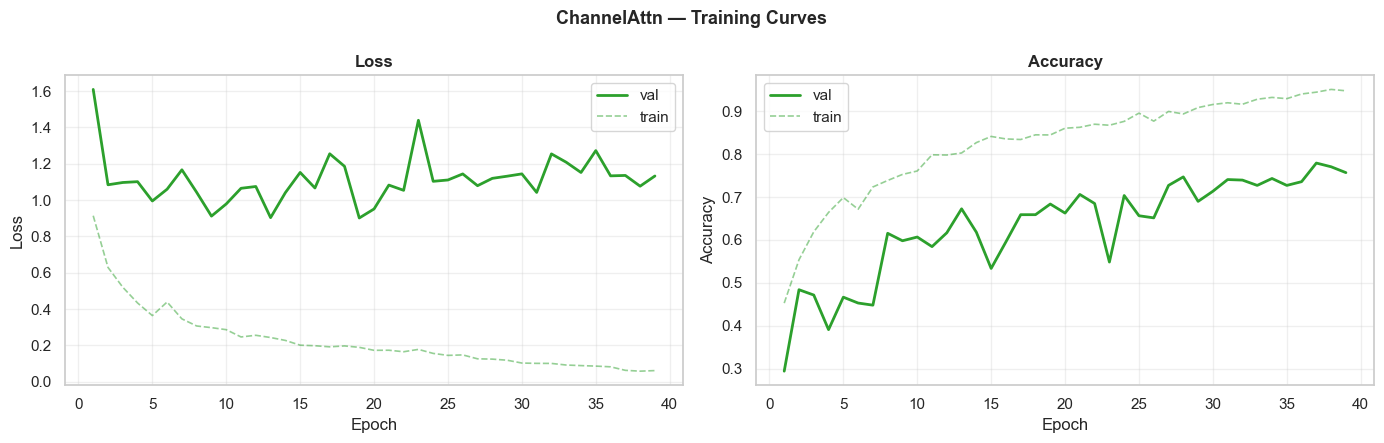

In [41]:
# ── Training & validation curves ──────────────────────────────────────────────
epochs = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(epochs, history['val_loss'],   color='#2ca02c', lw=2,   label='val')
axes[0].plot(epochs, history['train_loss'], color='#2ca02c', lw=1.2, ls='--', alpha=0.5, label='train')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss', fontweight='bold'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history['val_acc'],    color='#2ca02c', lw=2,   label='val')
axes[1].plot(epochs, history['train_acc'],  color='#2ca02c', lw=1.2, ls='--', alpha=0.5, label='train')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy', fontweight='bold'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle(f'ChannelAttn — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 3.13 — Confusion matrix

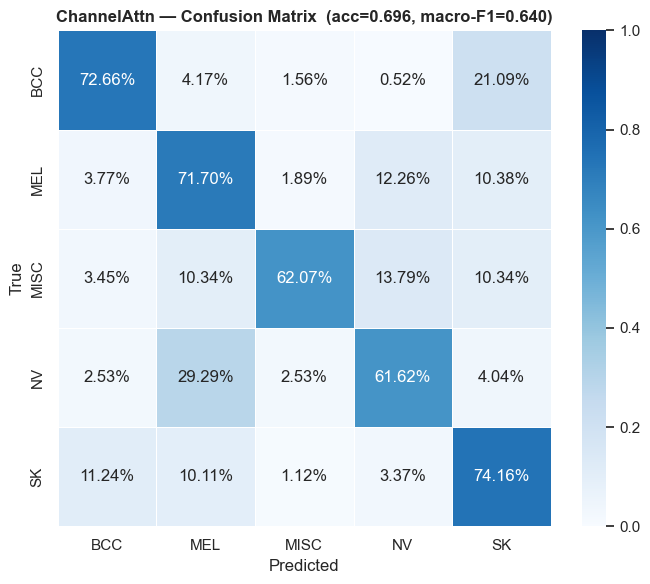

In [42]:
# ── Normalized confusion matrix ──────────────────────────────────────────────
cm_norm = confusion_matrix(y_true, y_pred, normalize='true')
plt.figure(figsize=(7, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', vmin=0, vmax=1,
            xticklabels=class_names, yticklabels=class_names, linewidths=0.5)
plt.title(f'ChannelAttn — Confusion Matrix  (acc={metrics["accuracy"]:.3f}, '
          f'macro-F1={metrics["f1_macro"]:.3f})', fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

### 3.14 — ROC curves (one-vs-rest)

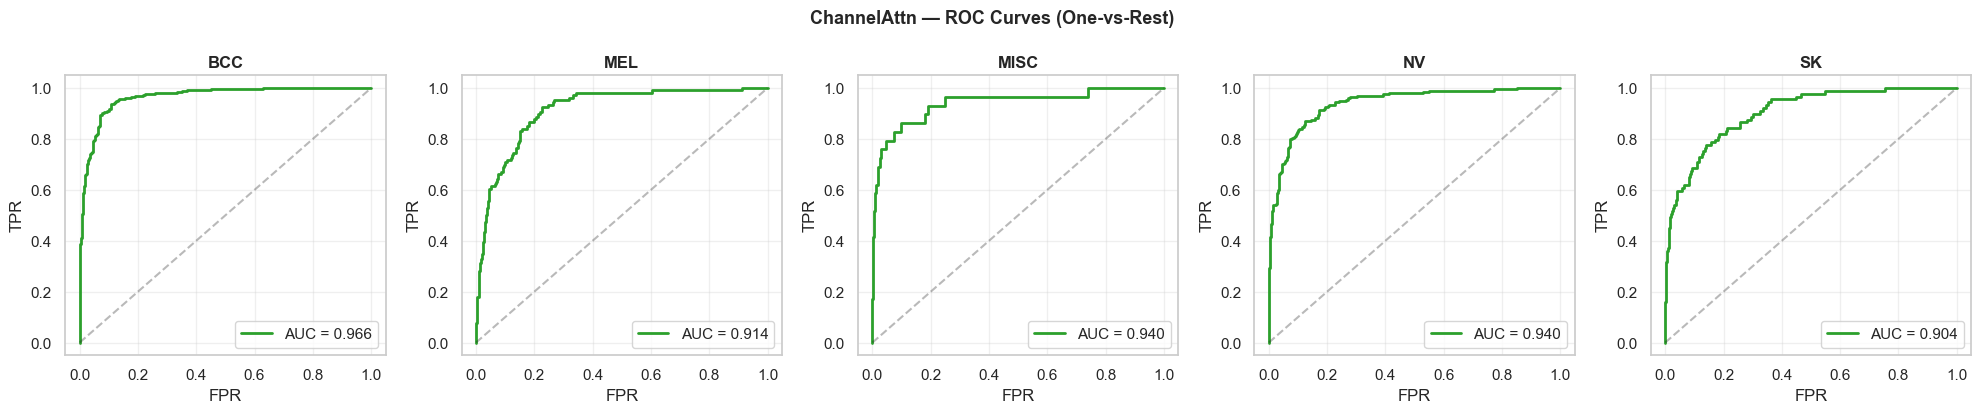

In [43]:
# ── ROC curves (one-vs-rest per class) ───────────────────────────────────────
yb = label_binarize(y_true, classes=range(len(class_names)))
fig, axes = plt.subplots(1, len(class_names), figsize=(20, 4.2))
for i, (cls, ax) in enumerate(zip(class_names, axes)):
    fpr, tpr, _ = roc_curve(yb[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color='#2ca02c', lw=2, label=f'AUC = {roc_auc:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_title(cls, fontweight='bold')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.suptitle(f'ChannelAttn — ROC Curves (One-vs-Rest)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 3.15 — Attention visualization

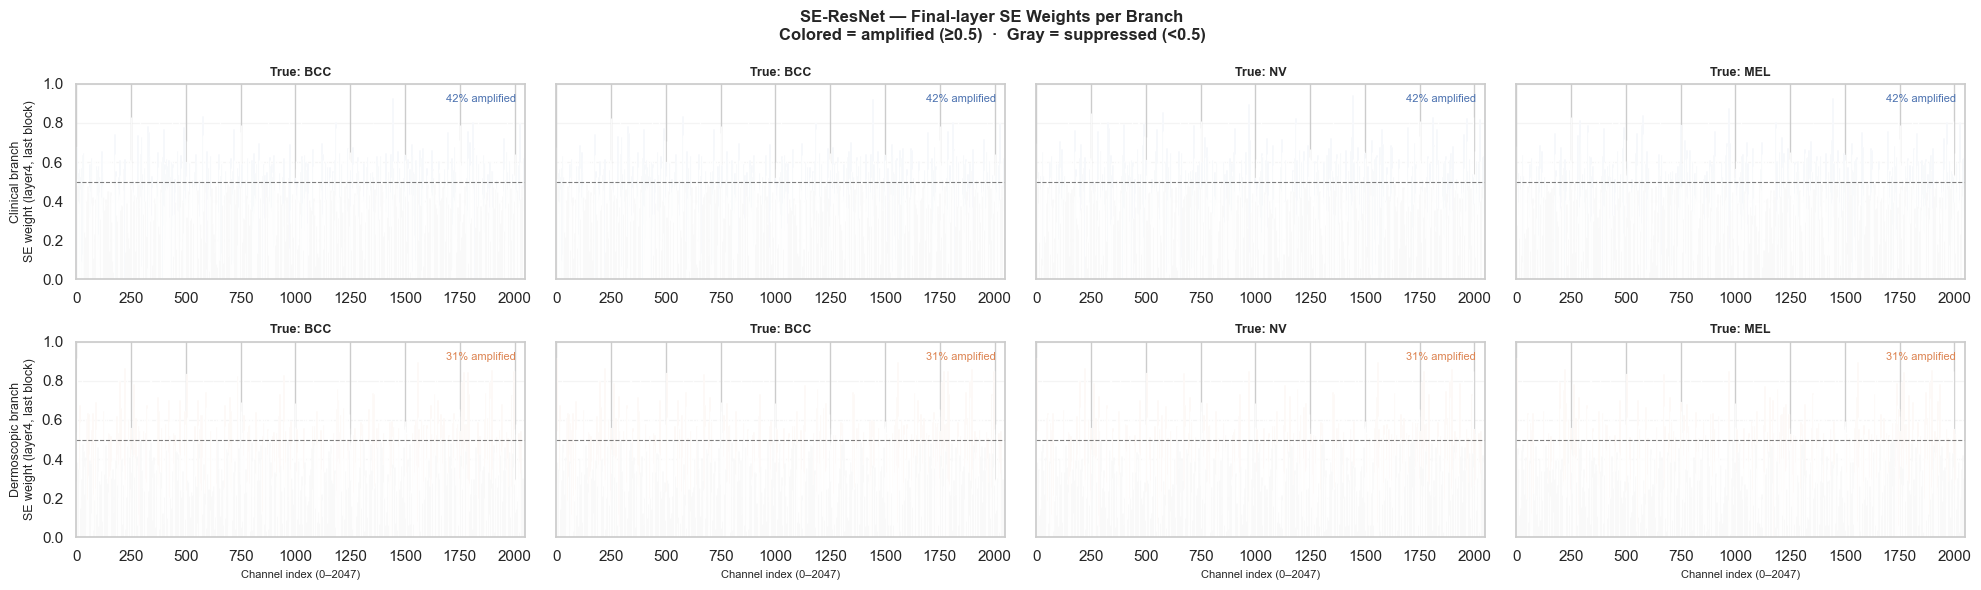

In [44]:
# ── SE channel-attention weight bars (last SE block of layer4) ─────────────
# Inside SE-ResNet, every residual block has its own SE.  We visualize the
# DEEPEST SE block (last block of layer4) because that's where channel-wise
# semantics are richest. w > 0.5 = channel amplified, w < 0.5 = suppressed.
_se_weights = {}
def _make_hook(key):
    def _hook(module, inp, out):
        _se_weights[key] = out.squeeze().detach().cpu().numpy()
    return _hook

# Path: model.resnet_<branch>.features[7] = layer4   (Sequential of SEBottlenecks)
# Last block in layer4 → SEBottleneck → .se → SEBlock → .sigmoid
clinic_last_se = model.resnet_clinic.features[7][-1].se
derm_last_se   = model.resnet_derm.features[7][-1].se
h_c = clinic_last_se.sigmoid.register_forward_hook(_make_hook('clinic'))
h_d = derm_last_se.sigmoid.register_forward_hook(_make_hook('derm'))

n_show     = 4
sample_idx = np.linspace(0, len(test_ds) - 1, n_show, dtype=int)
channels   = np.arange(2048)

fig, axes = plt.subplots(2, n_show, figsize=(20, 6), sharey=True)
branch_colors = {'clinic': '#4C72B0', 'derm': '#DD8452'}

model.eval()
with torch.no_grad():
    for col, idx in enumerate(sample_idx):
        clinic_t, derm_t, label = test_ds[idx]
        model(clinic_t.unsqueeze(0).to(device), derm_t.unsqueeze(0).to(device))
        true_label = class_names[label.item() if hasattr(label, 'item') else int(label)]

        for row, (branch, ax) in enumerate(zip(['clinic', 'derm'], axes[:, col])):
            w     = _se_weights[branch]
            above = w >= 0.5
            ax.bar(channels[above],  w[above],  width=1, color=branch_colors[branch], alpha=0.9)
            ax.bar(channels[~above], w[~above], width=1, color='lightgray', alpha=0.7)
            ax.axhline(0.5, color='black', lw=0.8, ls='--', alpha=0.5)
            ax.set_ylim(0, 1); ax.set_xlim(0, 2048)
            ax.set_title(f'True: {true_label}', fontsize=9, fontweight='bold')
            if col == 0:
                ax.set_ylabel(
                    f'{"Clinical" if branch == "clinic" else "Dermoscopic"} branch\nSE weight (layer4, last block)',
                    fontsize=9
                )
            if row == 1:
                ax.set_xlabel('Channel index (0–2047)', fontsize=8)
            ax.grid(alpha=0.2, axis='y')
            pct_amp = above.mean() * 100
            ax.text(0.98, 0.95, f'{pct_amp:.0f}% amplified',
                    transform=ax.transAxes, ha='right', va='top', fontsize=8,
                    color=branch_colors[branch])

h_c.remove(); h_d.remove()
plt.suptitle(
    'SE-ResNet — Final-layer SE Weights per Branch\nColored = amplified (≥0.5)  ·  Gray = suppressed (<0.5)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════
# SECTION 4 — Combined (SE-ResNet + Bidirectional Cross Attention)
# ══════════════════════════════════════════════════════════════════════

**Self-contained section.** Restart kernel, then run cells 4.1 through 4.16 top-to-bottom without depending on other sections.

This section merges everything from Sections 1-3: SE-ResNet50 backbones (SE inside every residual block, GAP-only) on each branch, then bidirectional cross-attention to fuse them. Trains a `DualBranchSECrossCombined`, saves to `thesis_combined_best.pth`, then visualizes both attention mechanisms.

### 4.1 — Imports

In [1]:
import os, copy, time, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    roc_curve, auc, precision_score, recall_score, accuracy_score,
    cohen_kappa_score, matthews_corrcoef, balanced_accuracy_score,
    precision_recall_curve, average_precision_score, log_loss
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('mps' if torch.backends.mps.is_available() else
                      'cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
print(f'Device: {device}')
print(f'PyTorch: {torch.__version__}')

DERM7PT_DIR = Path('dataset') / 'Derm7pt'
MILK_DIR    = Path('dataset') / 'milk10k'


C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


Device: cuda
PyTorch: 2.6.0+cu124


### 4.2 — Data loading (Derm7pt + MILK10k)

In [2]:
# ── Derm7pt ──────────────────────────────────────────────────────────────────
derm_df = pd.read_csv(DERM7PT_DIR / 'meta' / 'meta.csv')
derm_df['clinic_path'] = derm_df['clinic'].apply(lambda x: str(DERM7PT_DIR / 'images' / x))
derm_df['derm_path']   = derm_df['derm'].apply(lambda x: str(DERM7PT_DIR / 'images' / x))
derm_df['diagnosis']   = derm_df['diagnosis'].str.strip().str.lower()

diagnosis_groups = {
    'melanoma': 'MEL', 'melanoma (less than 0.76 mm)': 'MEL', 'melanoma (in situ)': 'MEL',
    'melanoma (0.76 to 1.5 mm)': 'MEL', 'melanoma (more than 1.5 mm)': 'MEL',
    'melanoma metastasis': 'MEL',
    'clark nevus': 'NV', 'reed or spitz nevus': 'NV', 'dermal nevus': 'NV',
    'blue nevus': 'NV', 'congenital nevus': 'NV', 'combined nevus': 'NV',
    'recurrent nevus': 'NV',
    'basal cell carcinoma': 'BCC',
    'seborrheic keratosis': 'SK',
    'lentigo': 'MISC', 'dermatofibroma': 'MISC', 'vascular lesion': 'MISC',
    'melanosis': 'MISC', 'miscellaneous': 'MISC',
}
derm_df['diagnosis_group'] = derm_df['diagnosis'].map(diagnosis_groups)

class_names = sorted(derm_df['diagnosis_group'].dropna().unique())
label_map   = {name: i for i, name in enumerate(class_names)}

milk_meta = pd.read_csv(MILK_DIR / 'MILK10k_Training_Metadata.csv')
milk_gt   = pd.read_csv(MILK_DIR / 'MILK10k_Training_GroundTruth.csv')
milk_class_map = {'MEL': 'MEL', 'NV': 'NV', 'BCC': 'BCC', 'BKL': 'SK', 'DF': 'MISC', 'VASC': 'MISC'}
drop_classes   = {'AKIEC', 'SCCKA', 'INF', 'BEN_OTH', 'MAL_OTH'}
gt_cols = [c for c in milk_gt.columns if c != 'lesion_id']
milk_gt['raw_class'] = milk_gt[gt_cols].idxmax(axis=1)
milk_gt = milk_gt[~milk_gt['raw_class'].isin(drop_classes)].copy()
milk_gt['diagnosis_group'] = milk_gt['raw_class'].map(milk_class_map)
clinic_meta = (milk_meta[milk_meta['image_type'] == 'clinical: close-up']
               [['lesion_id', 'isic_id']].rename(columns={'isic_id': 'clinic_isic'}))
derm_meta   = (milk_meta[milk_meta['image_type'] == 'dermoscopic']
               [['lesion_id', 'isic_id']].rename(columns={'isic_id': 'derm_isic'}))
paths = clinic_meta.merge(derm_meta, on='lesion_id')
milk_df = milk_gt[['lesion_id', 'diagnosis_group']].merge(paths, on='lesion_id')
milk_df['clinic_path'] = milk_df.apply(
    lambda r: str(MILK_DIR / 'MILK10k_Training_Input' / r['lesion_id'] / f"{r['clinic_isic']}.jpg"), axis=1)
milk_df['derm_path'] = milk_df.apply(
    lambda r: str(MILK_DIR / 'MILK10k_Training_Input' / r['lesion_id'] / f"{r['derm_isic']}.jpg"), axis=1)
milk_df['source'] = 'MILK10k'

derm7_clean = derm_df[['clinic_path', 'derm_path', 'diagnosis_group']].copy()
derm7_clean['source'] = 'Derm7pt'
combined = pd.concat(
    [derm7_clean, milk_df[['clinic_path', 'derm_path', 'diagnosis_group', 'source']]],
    ignore_index=True
)
combined['label'] = combined['diagnosis_group'].map(label_map)
df = combined.dropna(subset=['label']).reset_index(drop=True)

print(f'Combined: {len(df)} samples | {len(class_names)} classes')
print(df['diagnosis_group'].value_counts().to_string())

Combined: 5372 samples | 5 classes
diagnosis_group
BCC     2564
NV      1321
MEL      702
SK       589
MISC     196


### 4.3 — Dataset class

In [3]:
class SkinLesionDualDataset(Dataset):
    """Returns (clinic_img, derm_img, label) for each sample."""
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        clinic_img = Image.open(row['clinic_path']).convert('RGB')
        derm_img   = Image.open(row['derm_path']).convert('RGB')
        if self.transform:
            clinic_img = self.transform(clinic_img)
            derm_img   = self.transform(derm_img)
        return clinic_img, derm_img, torch.tensor(row['label'], dtype=torch.long)

### 4.4 — Transforms & stratified split

In [4]:
# ── Transforms ────────────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

labels  = df['label'].values.astype(int)
indices = np.arange(len(df))
train_idx, temp_idx = train_test_split(indices, test_size=0.30, stratify=labels, random_state=SEED)
val_idx,  test_idx  = train_test_split(temp_idx, test_size=0.50, stratify=labels[temp_idx], random_state=SEED)

train_labels   = labels[train_idx]
class_counts   = np.bincount(train_labels)
sample_weights = (1.0 / class_counts)[train_labels]
loss_weights   = torch.tensor(
    [len(train_labels) / (len(class_names) * c) for c in class_counts],
    dtype=torch.float32
).to(device)
print(f'Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}')
print('Loss weights:', dict(zip(class_names, loss_weights.cpu().numpy().round(3))))

Train: 3760 | Val: 806 | Test: 806
Loss weights: {'BCC': 0.419, 'MEL': 1.532, 'MISC': 5.489, 'NV': 0.813, 'SK': 1.825}


### 4.5 — DataLoaders

In [5]:
_NUM_WORKERS = 0 if device.type in ('mps', 'cpu') or os.name == 'nt' else min(8, os.cpu_count() or 4)
_PIN_MEMORY  = device.type == 'cuda'

def make_loaders(batch_size=32):
    train_ds = SkinLesionDualDataset(df.iloc[train_idx], train_transform)
    val_ds   = SkinLesionDualDataset(df.iloc[val_idx],   val_transform)
    test_ds  = SkinLesionDualDataset(df.iloc[test_idx],  val_transform)
    samp = WeightedRandomSampler(sample_weights, len(train_labels), replacement=True)
    kw = dict(num_workers=_NUM_WORKERS, pin_memory=_PIN_MEMORY,
              persistent_workers=(_NUM_WORKERS > 0))
    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=samp, **kw)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, **kw)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, **kw)
    return train_loader, val_loader, test_loader, test_ds

### 4.6 — SE-ResNet50 backbone

In [6]:
class SEBlock(nn.Module):
    """Official SE block (Hu et al. CVPR 2018): GAP only, no max pool."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False),
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, _, _ = x.shape
        w = self.sigmoid(self.fc(self.avg_pool(x).view(b, c))).view(b, c, 1, 1)
        return x * w


class SEBottleneck(nn.Module):
    """Wraps a ResNet Bottleneck and injects an SE block on the residual branch."""
    def __init__(self, bottleneck, reduction=16):
        super().__init__()
        self.block = bottleneck
        self.se    = SEBlock(bottleneck.conv3.out_channels, reduction)

    def forward(self, x):
        identity = x
        out = self.block.conv1(x); out = self.block.bn1(out); out = self.block.relu(out)
        out = self.block.conv2(out); out = self.block.bn2(out); out = self.block.relu(out)
        out = self.block.conv3(out); out = self.block.bn3(out)
        out = self.se(out)
        if self.block.downsample is not None:
            identity = self.block.downsample(x)
        out = out + identity
        return self.block.relu(out)


class SEResNet50Backbone(nn.Module):
    """SE-ResNet50: pretrained ResNet50 with SE blocks injected into every residual block."""
    def __init__(self, pretrained=True, reduction=16):
        super().__init__()
        base = models.resnet50(weights=models.ResNet50_Weights.DEFAULT if pretrained else None)
        for layer in [base.layer1, base.layer2, base.layer3, base.layer4]:
            for i in range(len(layer)):
                layer[i] = SEBottleneck(layer[i], reduction=reduction)
        self.features = nn.Sequential(
            base.conv1, base.bn1, base.relu, base.maxpool,
            base.layer1, base.layer2, base.layer3, base.layer4
        )

    def forward(self, x):
        return self.features(x)

### 4.7 — Hyperparameters & loaders

In [7]:
LR             = 0.000750
DROPOUT        = 0.32
NUM_HEADS      = 4
EMBED_DIM      = 256
WEIGHT_DECAY   = 0.000957
BATCH_SIZE     = 64
FINAL_EPOCHS   = 60
PATIENCE       = 20
UNFREEZE_EPOCH = 5
GRAD_CLIP      = 1.0

train_loader, val_loader, test_loader, test_ds = make_loaders(BATCH_SIZE)
print(f'Loaders: train={len(train_loader.dataset):,}  val={len(val_loader.dataset):,}  test={len(test_loader.dataset):,}')

Loaders: train=3,760  val=806  test=806


### 4.8 — Model: DualBranchSECrossCombined

In [8]:
class CrossAttentionFusion(nn.Module):
    """Unidirectional cross-attention building block."""
    def __init__(self, in_dim=2048, embed_dim=512, num_heads=8, dropout=0.1):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.q_proj = nn.Linear(in_dim, embed_dim)
        self.k_proj = nn.Linear(in_dim, embed_dim)
        self.v_proj = nn.Linear(in_dim, embed_dim)
        self.attn   = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm1  = nn.LayerNorm(embed_dim)
        self.ffn    = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim * 2, embed_dim),
        )
        self.norm2 = nn.LayerNorm(embed_dim)
        self.pool  = nn.AdaptiveAvgPool1d(1)

    def forward(self, clinic_feat, derm_feat):
        c = clinic_feat.flatten(2).transpose(1, 2)
        d = derm_feat.flatten(2).transpose(1, 2)
        Q = self.q_proj(c); K = self.k_proj(d); V = self.v_proj(d)
        attn_out, attn_weights = self.attn(Q, K, V, need_weights=True, average_attn_weights=True)
        x = self.norm1(Q + attn_out)
        x = self.norm2(x + self.ffn(x))
        fused = self.pool(x.transpose(1, 2)).squeeze(-1)
        return fused, attn_weights


class BidirectionalCrossAttnFusion(nn.Module):
    """Bidirectional cross-attention: clinic->derm + derm->clinic, concat then project."""
    def __init__(self, in_dim=2048, embed_dim=256, num_heads=4, dropout=0.32):
        super().__init__()
        self.c2d  = CrossAttentionFusion(in_dim, embed_dim, num_heads, dropout)
        self.d2c  = CrossAttentionFusion(in_dim, embed_dim, num_heads, dropout)
        self.proj = nn.Linear(embed_dim * 2, embed_dim)

    def forward(self, clinic_feat, derm_feat):
        fused_c2d, attn_c2d = self.c2d(clinic_feat, derm_feat)
        fused_d2c, attn_d2c = self.d2c(derm_feat, clinic_feat)
        fused = self.proj(torch.cat([fused_c2d, fused_d2c], dim=1))
        return fused, (attn_c2d, attn_d2c)


class DualBranchSECrossCombined(nn.Module):
    """
    Combined model: SE-ResNet50 backbones + bidirectional cross-attention fusion.
    SE attention lives inside every residual block of each backbone (GAP-only).
    Cross-attention then fuses the two branches' final feature maps bidirectionally.
    """
    def __init__(self, num_classes=5, embed_dim=256, num_heads=4, dropout=0.32):
        super().__init__()
        self.resnet_clinic = SEResNet50Backbone(pretrained=True)
        self.resnet_derm   = SEResNet50Backbone(pretrained=True)
        self.fusion        = BidirectionalCrossAttnFusion(
            in_dim=2048, embed_dim=embed_dim, num_heads=num_heads, dropout=dropout
        )
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.BatchNorm1d(embed_dim // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(embed_dim // 2, num_classes),
        )

    def _freeze_backbones(self):
        """Warm-up freezing: freeze pretrained conv/bn except layer4. Keep ALL SE blocks
        trainable (they are new, randomly initialized parameters)."""
        for m in [self.resnet_clinic, self.resnet_derm]:
            for p in m.parameters():
                p.requires_grad = False
            for p in m.features[7].parameters():
                p.requires_grad = True
            for module in m.modules():
                if isinstance(module, SEBlock):
                    for p in module.parameters():
                        p.requires_grad = True

    def unfreeze_resnets(self):
        for m in [self.resnet_clinic, self.resnet_derm]:
            for p in m.features[6].parameters():
                p.requires_grad = True

    def forward(self, clinic_img, derm_img):
        feat_c = self.resnet_clinic(clinic_img)
        feat_d = self.resnet_derm(derm_img)
        fused, attn_weights = self.fusion(feat_c, feat_d)
        return self.classifier(fused), attn_weights


# Parameter count
_m = DualBranchSECrossCombined(num_classes=len(class_names), embed_dim=EMBED_DIM,
                                num_heads=NUM_HEADS, dropout=DROPOUT)
_m._freeze_backbones()
total     = sum(p.numel() for p in _m.parameters())
trainable = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'Combined (SE-ResNet + BiCross): {total:,} total, {trainable:,} trainable in warm-up ({trainable/total*100:.1f}%)')
del _m

Combined (SE-ResNet + BiCross): 56,412,549 total, 39,325,957 trainable in warm-up (69.7%)


### 4.9 — EarlyStopping + train/validate helpers

In [9]:
class EarlyStopping:
    def __init__(self, patience=20, min_delta=1e-4):
        self.patience  = patience
        self.min_delta = min_delta
        self.counter   = 0
        self.best_loss = float('inf')
        self.best_state = None
        self.stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter    = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

    def restore(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


def train_one_epoch(model, loader, optimizer, criterion, grad_clip):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for clinic_imgs, derm_imgs, labels_batch in loader:
        clinic_imgs  = clinic_imgs.to(device)
        derm_imgs    = derm_imgs.to(device)
        labels_batch = labels_batch.to(device)
        optimizer.zero_grad()
        logits, _ = model(clinic_imgs, derm_imgs)
        loss      = criterion(logits, labels_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        total_loss += loss.item() * clinic_imgs.size(0)
        correct    += logits.argmax(1).eq(labels_batch).sum().item()
        total      += clinic_imgs.size(0)
    return total_loss / total, correct / total


def validate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for clinic_imgs, derm_imgs, labels_batch in loader:
            clinic_imgs  = clinic_imgs.to(device)
            derm_imgs    = derm_imgs.to(device)
            labels_batch = labels_batch.to(device)
            logits, _    = model(clinic_imgs, derm_imgs)
            loss         = criterion(logits, labels_batch)
            total_loss  += loss.item() * clinic_imgs.size(0)
            correct     += logits.argmax(1).eq(labels_batch).sum().item()
            total       += clinic_imgs.size(0)
    return total_loss / total, correct / total

### 4.10 — Training

In [10]:
# ── Train Combined ────────────────────────────────────────────────────────────
model = DualBranchSECrossCombined(num_classes=len(class_names), embed_dim=EMBED_DIM,
                                   num_heads=NUM_HEADS, dropout=DROPOUT).to(device)
model._freeze_backbones()

criterion  = nn.CrossEntropyLoss(weight=loss_weights)
optimizer  = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=WEIGHT_DECAY
)
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=UNFREEZE_EPOCH)
early_stop = EarlyStopping(patience=PATIENCE)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
early_stop_epoch = None
start = time.time()

for epoch in range(FINAL_EPOCHS):
    if epoch == UNFREEZE_EPOCH:
        model.unfreeze_resnets()
        optimizer = optim.Adam(model.parameters(), lr=LR / 4, weight_decay=WEIGHT_DECAY)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=FINAL_EPOCHS - UNFREEZE_EPOCH
        )
        print(f'  Epoch {epoch+1}: unfroze layer3, lr -> {LR/4:.2e}')

    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, GRAD_CLIP)
    va_loss, va_acc = validate(model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)

    early_stop(va_loss, model)
    print(f'  Ep {epoch+1:2d}/{FINAL_EPOCHS} | '
          f'train {tr_loss:.4f}/{tr_acc:.4f} | val {va_loss:.4f}/{va_acc:.4f} | '
          f'es {early_stop.counter}/{PATIENCE}')

    if early_stop.stop:
        early_stop_epoch = epoch + 1
        print(f'  -> Early stop at epoch {early_stop_epoch}. Restoring best weights.')
        early_stop.restore(model)
        break

elapsed = (time.time() - start) / 60
print(f'\nDone in {elapsed:.1f} min | best val loss: {early_stop.best_loss:.4f}')

torch.save({
    'model_state_dict': model.state_dict(),
    'class_names':      class_names,
    'label_map':        label_map,
    'history':          history,
    'best_val_loss':    early_stop.best_loss,
    'early_stop_epoch': early_stop_epoch,
}, 'thesis_combined_best.pth')
print(f'Saved: thesis_combined_best.pth')

  Ep  1/60 | train 0.9494/0.4407 | val 1.5397/0.2295 | es 0/20
  Ep  2/60 | train 0.7110/0.5165 | val 1.2781/0.2605 | es 0/20
  Ep  3/60 | train 0.6022/0.5848 | val 1.3070/0.3226 | es 1/20
  Ep  4/60 | train 0.4780/0.6412 | val 1.1525/0.3871 | es 0/20
  Ep  5/60 | train 0.4006/0.6811 | val 1.0620/0.4516 | es 0/20
  Epoch 6: unfroze layer3, lr -> 1.88e-04
  Ep  6/60 | train 0.4695/0.6580 | val 1.1673/0.3747 | es 1/20
  Ep  7/60 | train 0.3861/0.6870 | val 1.1702/0.3697 | es 2/20
  Ep  8/60 | train 0.3938/0.6907 | val 1.0259/0.5149 | es 0/20
  Ep  9/60 | train 0.3605/0.7250 | val 1.0795/0.5298 | es 1/20
  Ep 10/60 | train 0.3501/0.7364 | val 1.0500/0.6514 | es 2/20
  Ep 11/60 | train 0.3075/0.7699 | val 1.0615/0.5980 | es 3/20
  Ep 12/60 | train 0.2777/0.7713 | val 1.0597/0.5955 | es 4/20
  Ep 13/60 | train 0.2703/0.7838 | val 1.0759/0.6427 | es 5/20
  Ep 14/60 | train 0.2618/0.7846 | val 1.1883/0.5037 | es 6/20
  Ep 15/60 | train 0.2510/0.8085 | val 1.0401/0.5447 | es 7/20
  Ep 16/60 | 

### 4.11 — Evaluation

In [11]:
# ── Evaluate on test set ──────────────────────────────────────────────────────
ckpt = torch.load('thesis_combined_best.pth', map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

preds_list, labels_list, probs_list, attn_list = [], [], [], []
with torch.no_grad():
    for clinic_imgs, derm_imgs, lb in test_loader:
        logits, attn_w = model(clinic_imgs.to(device), derm_imgs.to(device))
        probs = F.softmax(logits, dim=1)
        preds_list.extend(logits.argmax(1).cpu().numpy())
        labels_list.extend(lb.numpy())
        probs_list.extend(probs.cpu().numpy())
        if attn_w is not None:
            aw = attn_w[0] if isinstance(attn_w, tuple) else attn_w
            attn_list.extend(aw.cpu().numpy())

y_true  = np.array(labels_list)
y_pred  = np.array(preds_list)
y_probs = np.array(probs_list)
attn_arr = np.array(attn_list) if attn_list else None

metrics = {
    'accuracy':          accuracy_score(y_true, y_pred),
    'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
    'f1_macro':          f1_score(y_true, y_pred, average='macro',    zero_division=0),
    'f1_weighted':       f1_score(y_true, y_pred, average='weighted', zero_division=0),
    'cohen_kappa':       cohen_kappa_score(y_true, y_pred),
    'mcc':               matthews_corrcoef(y_true, y_pred),
    'log_loss':          log_loss(y_true, y_probs),
}

print('Test-set metrics:')
for k, v in metrics.items():
    print(f'  {k:<20}: {v:.4f}')

print('\nPer-class report:')
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

Test-set metrics:
  accuracy            : 0.7221
  balanced_accuracy   : 0.6968
  f1_macro            : 0.6573
  f1_weighted         : 0.7389
  cohen_kappa         : 0.6154
  mcc                 : 0.6245
  log_loss            : 0.8104

Per-class report:
              precision    recall  f1-score   support

         BCC       0.95      0.73      0.83       384
         MEL       0.52      0.65      0.58       106
        MISC       0.55      0.62      0.58        29
          NV       0.80      0.75      0.77       198
          SK       0.41      0.73      0.53        89

    accuracy                           0.72       806
   macro avg       0.64      0.70      0.66       806
weighted avg       0.78      0.72      0.74       806



### 4.12 — Training curves

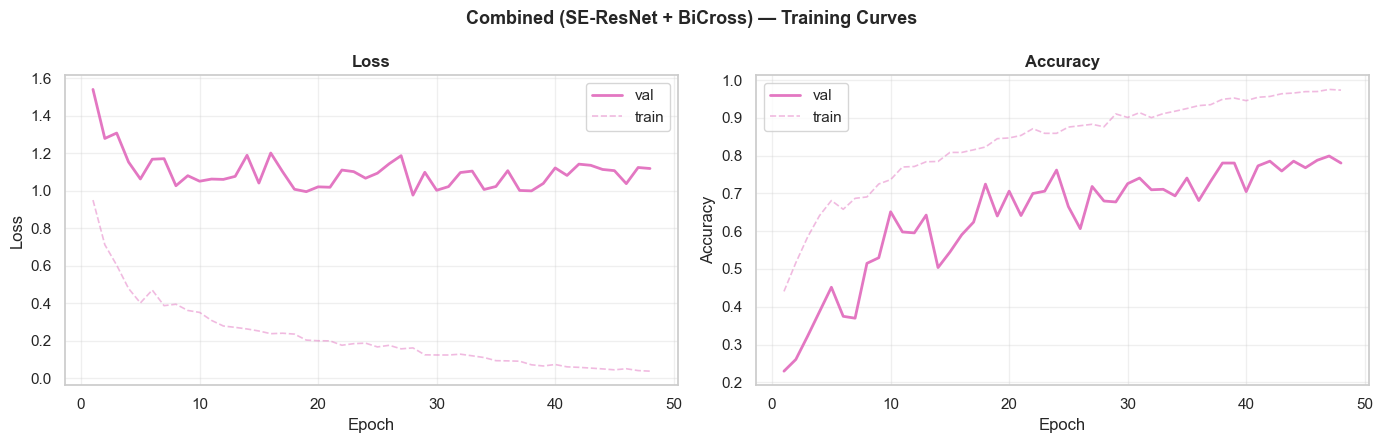

In [12]:
# ── Training & validation curves ──────────────────────────────────────────────
epochs = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].plot(epochs, history['val_loss'],   color='#e377c2', lw=2,   label='val')
axes[0].plot(epochs, history['train_loss'], color='#e377c2', lw=1.2, ls='--', alpha=0.5, label='train')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Loss', fontweight='bold'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history['val_acc'],    color='#e377c2', lw=2,   label='val')
axes[1].plot(epochs, history['train_acc'],  color='#e377c2', lw=1.2, ls='--', alpha=0.5, label='train')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy', fontweight='bold'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Combined (SE-ResNet + BiCross) — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 4.13 — Confusion matrix

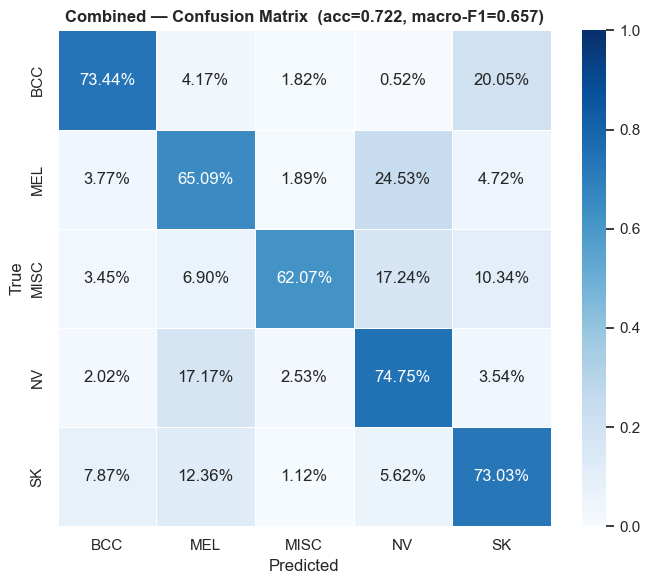

In [13]:
# ── Normalized confusion matrix ──────────────────────────────────────────────
cm_norm = confusion_matrix(y_true, y_pred, normalize='true')
plt.figure(figsize=(7, 6))
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', vmin=0, vmax=1,
            xticklabels=class_names, yticklabels=class_names, linewidths=0.5)
plt.title(f'Combined — Confusion Matrix  (acc={metrics["accuracy"]:.3f}, '
          f'macro-F1={metrics["f1_macro"]:.3f})', fontweight='bold')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

### 4.14 — ROC curves (one-vs-rest)

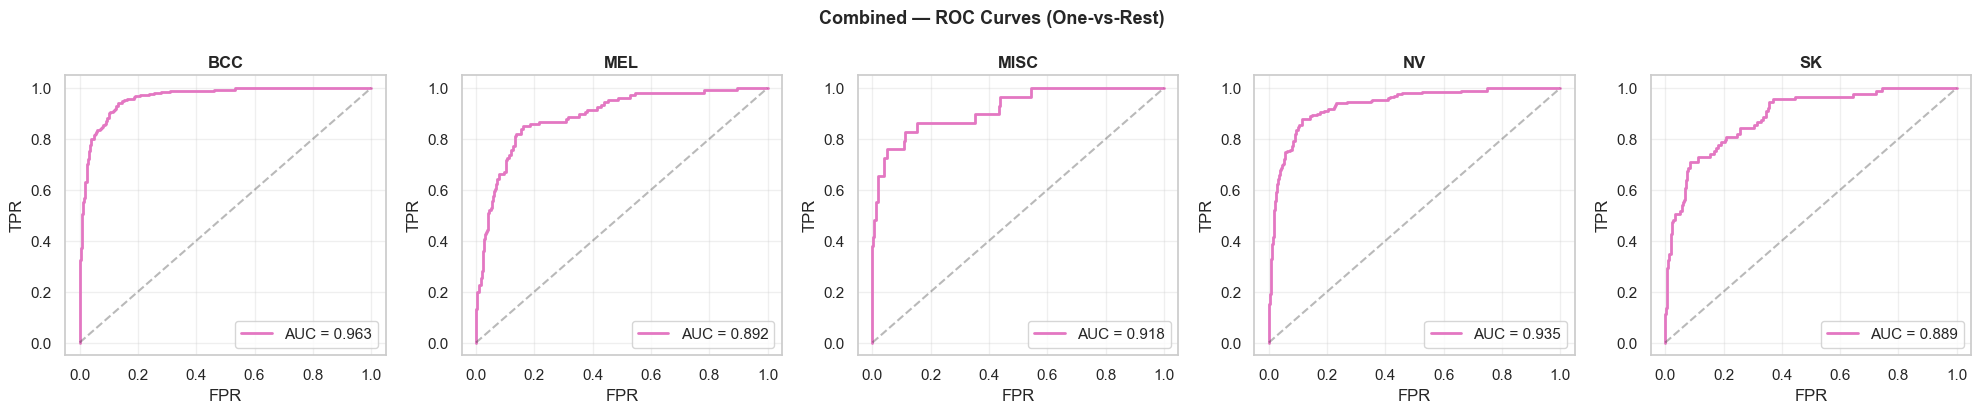

In [14]:
# ── ROC curves (one-vs-rest per class) ───────────────────────────────────────
yb = label_binarize(y_true, classes=range(len(class_names)))
fig, axes = plt.subplots(1, len(class_names), figsize=(20, 4.2))
for i, (cls, ax) in enumerate(zip(class_names, axes)):
    fpr, tpr, _ = roc_curve(yb[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color='#e377c2', lw=2, label=f'AUC = {roc_auc:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_title(cls, fontweight='bold')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.suptitle('Combined — ROC Curves (One-vs-Rest)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

### 4.15 — Bidirectional cross-attention heatmaps

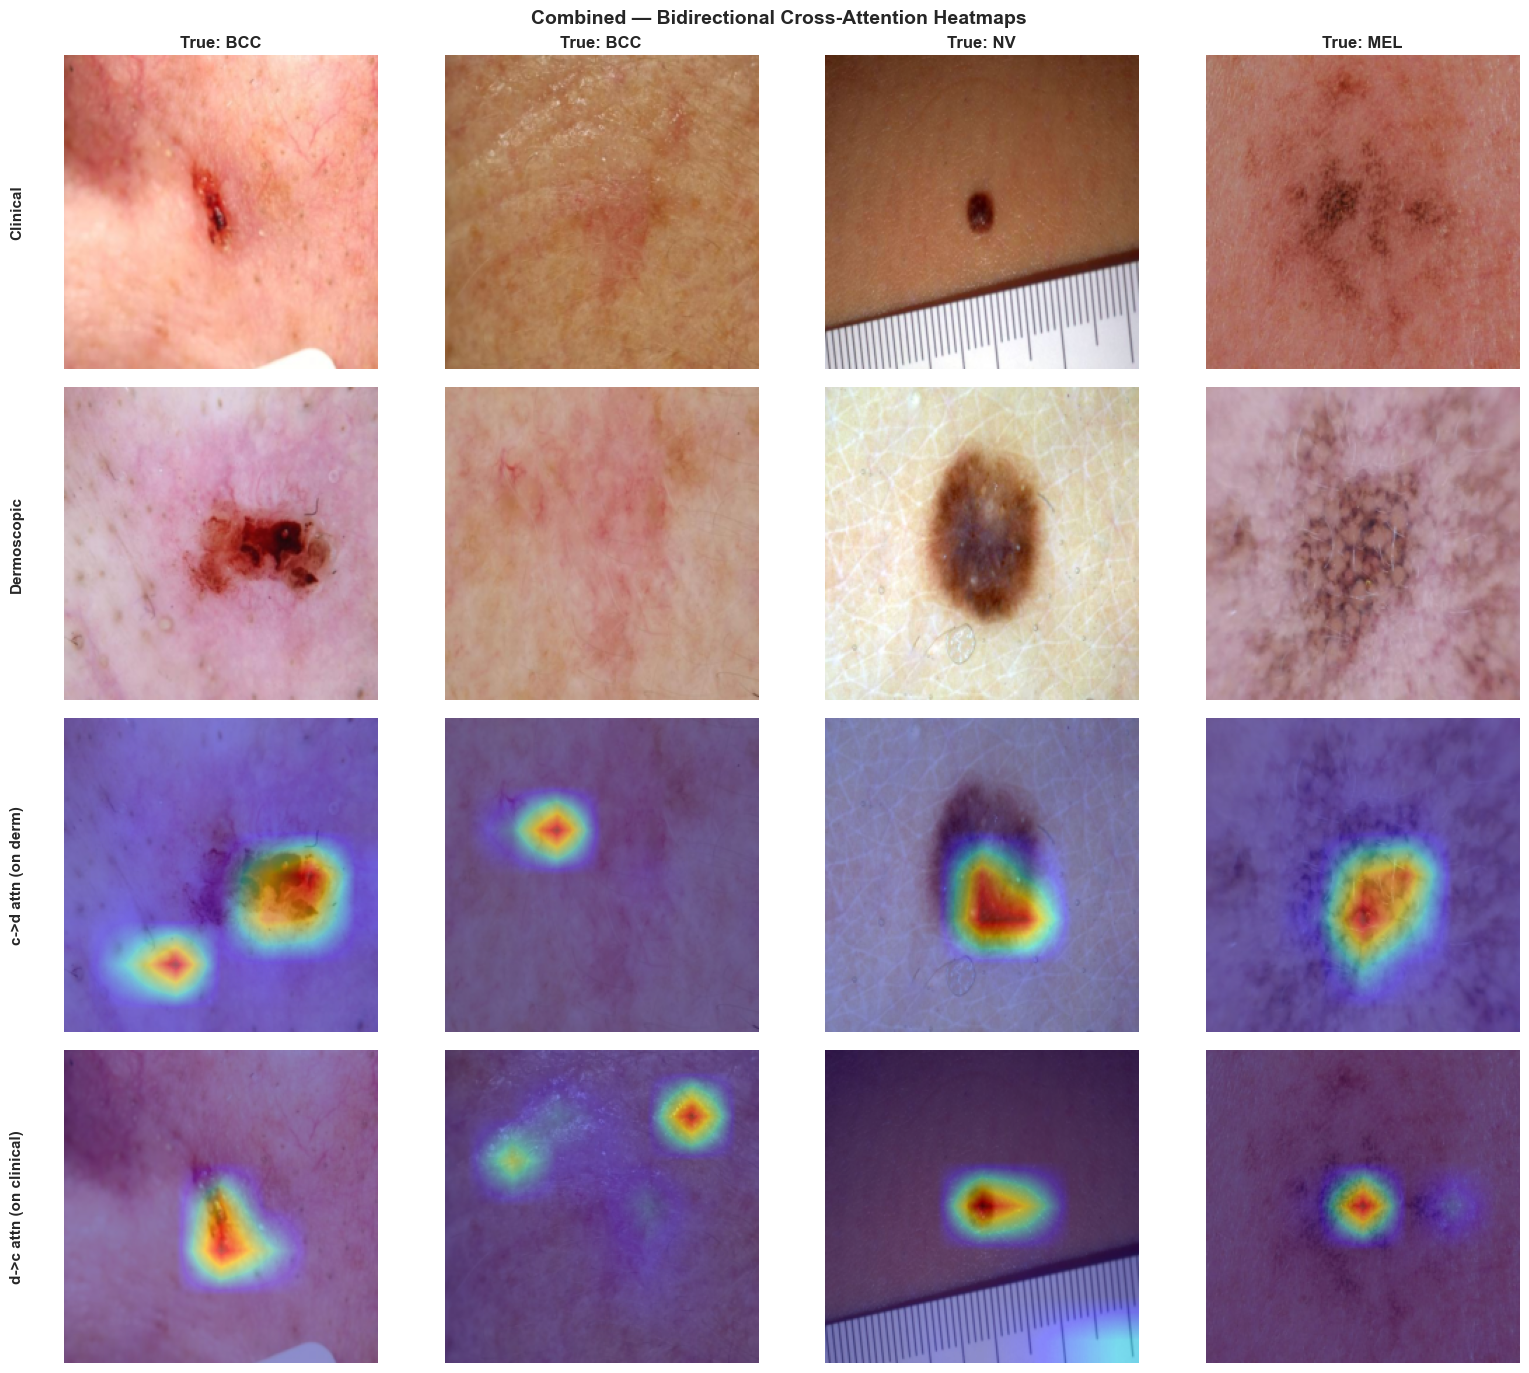

In [15]:
# ── Bidirectional cross-attention heatmaps ───────────────────────────────────
inv_norm = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

n_show = 4
s_idx  = np.linspace(0, len(test_ds) - 1, n_show, dtype=int)

attn_c2d_list, attn_d2c_list, clinic_imgs_disp, derm_imgs_disp, sample_labels = [], [], [], [], []
model.eval()
with torch.no_grad():
    for idx in s_idx:
        clinic_t, derm_t, label = test_ds[idx]
        _, attn_pair = model(clinic_t.unsqueeze(0).to(device), derm_t.unsqueeze(0).to(device))
        attn_c2d_list.append(attn_pair[0].squeeze(0).cpu().numpy())
        attn_d2c_list.append(attn_pair[1].squeeze(0).cpu().numpy())
        clinic_imgs_disp.append(inv_norm(clinic_t).permute(1, 2, 0).clamp(0, 1).numpy())
        derm_imgs_disp.append(inv_norm(derm_t).permute(1, 2, 0).clamp(0, 1).numpy())
        sample_labels.append(class_names[label.item() if hasattr(label, 'item') else int(label)])

fig, axes = plt.subplots(4, n_show, figsize=(4 * n_show, 14))
for col in range(n_show):
    axes[0, col].imshow(clinic_imgs_disp[col]); axes[0, col].axis('off')
    axes[0, col].set_title(f'True: {sample_labels[col]}', fontweight='bold')

    axes[1, col].imshow(derm_imgs_disp[col]); axes[1, col].axis('off')

    a_c2d = attn_c2d_list[col].mean(axis=0).reshape(7, 7)
    a_c2d = (a_c2d - a_c2d.min()) / (a_c2d.max() - a_c2d.min() + 1e-8)
    a_c2d_up = np.array(Image.fromarray((a_c2d * 255).astype(np.uint8))
                        .resize((224, 224), Image.BILINEAR)) / 255.0
    axes[2, col].imshow(derm_imgs_disp[col])
    axes[2, col].imshow(a_c2d_up, cmap='jet', alpha=0.45); axes[2, col].axis('off')

    a_d2c = attn_d2c_list[col].mean(axis=0).reshape(7, 7)
    a_d2c = (a_d2c - a_d2c.min()) / (a_d2c.max() - a_d2c.min() + 1e-8)
    a_d2c_up = np.array(Image.fromarray((a_d2c * 255).astype(np.uint8))
                        .resize((224, 224), Image.BILINEAR)) / 255.0
    axes[3, col].imshow(clinic_imgs_disp[col])
    axes[3, col].imshow(a_d2c_up, cmap='jet', alpha=0.45); axes[3, col].axis('off')

for ax, lbl in zip(axes[:, 0], ['Clinical', 'Dermoscopic', 'c->d attn (on derm)', 'd->c attn (on clinical)']):
    ax.text(-0.15, 0.5, lbl, transform=ax.transAxes, rotation=90,
            va='center', ha='center', fontsize=11, fontweight='bold')

plt.suptitle('Combined — Bidirectional Cross-Attention Heatmaps',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

### 4.16 — SE channel weight visualization

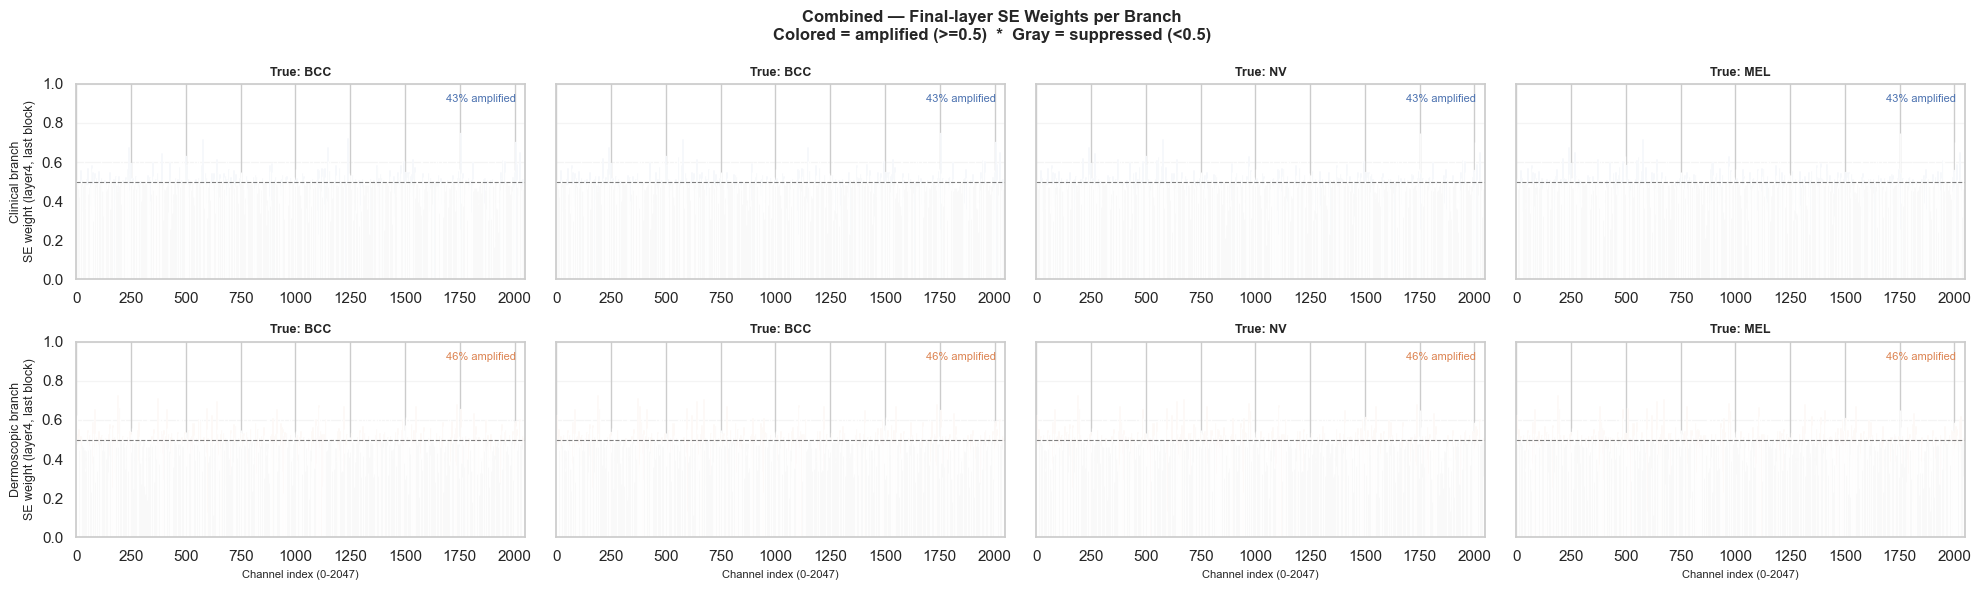

In [16]:
# ── SE channel-attention weight bars (last SE block of layer4) ─────────────
_se_weights = {}
def _make_hook(key):
    def _hook(module, inp, out):
        _se_weights[key] = out.squeeze().detach().cpu().numpy()
    return _hook

clinic_last_se = model.resnet_clinic.features[7][-1].se
derm_last_se   = model.resnet_derm.features[7][-1].se
h_c = clinic_last_se.sigmoid.register_forward_hook(_make_hook('clinic'))
h_d = derm_last_se.sigmoid.register_forward_hook(_make_hook('derm'))

n_show     = 4
sample_idx = np.linspace(0, len(test_ds) - 1, n_show, dtype=int)
channels   = np.arange(2048)

fig, axes = plt.subplots(2, n_show, figsize=(20, 6), sharey=True)
branch_colors = {'clinic': '#4C72B0', 'derm': '#DD8452'}

model.eval()
with torch.no_grad():
    for col, idx in enumerate(sample_idx):
        clinic_t, derm_t, label = test_ds[idx]
        model(clinic_t.unsqueeze(0).to(device), derm_t.unsqueeze(0).to(device))
        true_label = class_names[label.item() if hasattr(label, 'item') else int(label)]

        for row, (branch, ax) in enumerate(zip(['clinic', 'derm'], axes[:, col])):
            w     = _se_weights[branch]
            above = w >= 0.5
            ax.bar(channels[above],  w[above],  width=1, color=branch_colors[branch], alpha=0.9)
            ax.bar(channels[~above], w[~above], width=1, color='lightgray', alpha=0.7)
            ax.axhline(0.5, color='black', lw=0.8, ls='--', alpha=0.5)
            ax.set_ylim(0, 1); ax.set_xlim(0, 2048)
            ax.set_title(f'True: {true_label}', fontsize=9, fontweight='bold')
            if col == 0:
                ax.set_ylabel(
                    f'{"Clinical" if branch == "clinic" else "Dermoscopic"} branch\nSE weight (layer4, last block)',
                    fontsize=9
                )
            if row == 1:
                ax.set_xlabel('Channel index (0-2047)', fontsize=8)
            ax.grid(alpha=0.2, axis='y')
            pct_amp = above.mean() * 100
            ax.text(0.98, 0.95, f'{pct_amp:.0f}% amplified',
                    transform=ax.transAxes, ha='right', va='top', fontsize=8,
                    color=branch_colors[branch])

h_c.remove(); h_d.remove()
plt.suptitle(
    'Combined — Final-layer SE Weights per Branch\nColored = amplified (>=0.5)  *  Gray = suppressed (<0.5)',
    fontsize=12, fontweight='bold'
)
plt.tight_layout(); plt.show()

# ══════════════════════════════════════════════════════════════════════
# SECTION 5 — Final Comparison (all 4 models)
# ══════════════════════════════════════════════════════════════════════

**Run this after all four sections have completed training** (so checkpoints `thesis_baseline_best.pth`, `thesis_bicross_best.pth`, `thesis_channel_best.pth`, `thesis_combined_best.pth` exist on disk).

Self-contained: re-imports, re-builds the test loader, redefines all four model classes, then loads each checkpoint and evaluates on the held-out test set. Saves results to `comparison_metrics_thesis.csv` for the SPV report.

C:\Users\User\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\utils\_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


Device: cuda
Test samples: 806

▶ Evaluating Baseline from thesis_baseline_best.pth
  acc=0.6861  f1_macro=0.6320  kappa=0.5705

▶ Evaluating BiCrossAttn from thesis_bicross_best.pth
  acc=0.7382  f1_macro=0.6754  kappa=0.6294

▶ Evaluating SE-ResNet from thesis_channel_best.pth
  acc=0.6960  f1_macro=0.6399  kappa=0.5827

▶ Evaluating Combined from thesis_combined_best.pth
  acc=0.7221  f1_macro=0.6573  kappa=0.6154

COMPARISON — Key Metrics on Held-Out Test Set
             accuracy  balanced_accuracy  f1_macro  f1_weighted  cohen_kappa     mcc  log_loss
Model                                                                                         
Baseline       0.6861             0.6770    0.6320       0.7082       0.5705  0.5844    0.8270
BiCrossAttn    0.7382             0.7027    0.6754       0.7477       0.6294  0.6325    0.7480
SE-ResNet      0.6960             0.6844    0.6399       0.7168       0.5827  0.5956    0.8082
Combined       0.7221             0.6968    0.6573       

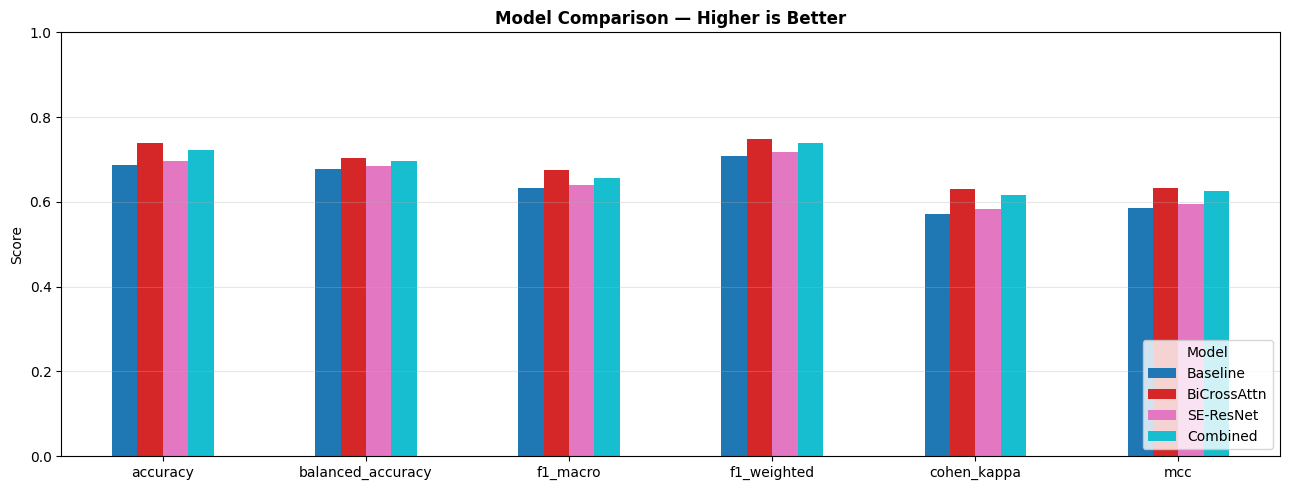

In [1]:
# ── Final Comparison — load all 3 checkpoints, evaluate, build table ──────────
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    cohen_kappa_score, matthews_corrcoef, log_loss, classification_report
)

warnings.filterwarnings('ignore')
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
device = torch.device('mps' if torch.backends.mps.is_available() else
                      'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# ── Data (mirrors each section's data prep) ──────────────────────────────────
DERM7PT_DIR = Path('dataset') / 'Derm7pt'
MILK_DIR    = Path('dataset') / 'milk10k'

derm_df = pd.read_csv(DERM7PT_DIR / 'meta' / 'meta.csv')
derm_df['clinic_path'] = derm_df['clinic'].apply(lambda x: str(DERM7PT_DIR / 'images' / x))
derm_df['derm_path']   = derm_df['derm'].apply(lambda x: str(DERM7PT_DIR / 'images' / x))
derm_df['diagnosis']   = derm_df['diagnosis'].str.strip().str.lower()
diagnosis_groups = {
    'melanoma': 'MEL', 'melanoma (less than 0.76 mm)': 'MEL', 'melanoma (in situ)': 'MEL',
    'melanoma (0.76 to 1.5 mm)': 'MEL', 'melanoma (more than 1.5 mm)': 'MEL',
    'melanoma metastasis': 'MEL',
    'clark nevus': 'NV', 'reed or spitz nevus': 'NV', 'dermal nevus': 'NV',
    'blue nevus': 'NV', 'congenital nevus': 'NV', 'combined nevus': 'NV',
    'recurrent nevus': 'NV',
    'basal cell carcinoma': 'BCC',
    'seborrheic keratosis': 'SK',
    'lentigo': 'MISC', 'dermatofibroma': 'MISC', 'vascular lesion': 'MISC',
    'melanosis': 'MISC', 'miscellaneous': 'MISC',
}
derm_df['diagnosis_group'] = derm_df['diagnosis'].map(diagnosis_groups)
class_names = sorted(derm_df['diagnosis_group'].dropna().unique())
label_map   = {name: i for i, name in enumerate(class_names)}

milk_meta = pd.read_csv(MILK_DIR / 'MILK10k_Training_Metadata.csv')
milk_gt   = pd.read_csv(MILK_DIR / 'MILK10k_Training_GroundTruth.csv')
milk_class_map = {'MEL':'MEL','NV':'NV','BCC':'BCC','BKL':'SK','DF':'MISC','VASC':'MISC'}
drop_classes   = {'AKIEC','SCCKA','INF','BEN_OTH','MAL_OTH'}
gt_cols = [c for c in milk_gt.columns if c != 'lesion_id']
milk_gt['raw_class'] = milk_gt[gt_cols].idxmax(axis=1)
milk_gt = milk_gt[~milk_gt['raw_class'].isin(drop_classes)].copy()
milk_gt['diagnosis_group'] = milk_gt['raw_class'].map(milk_class_map)
clinic_meta = (milk_meta[milk_meta['image_type']=='clinical: close-up']
               [['lesion_id','isic_id']].rename(columns={'isic_id':'clinic_isic'}))
derm_meta   = (milk_meta[milk_meta['image_type']=='dermoscopic']
               [['lesion_id','isic_id']].rename(columns={'isic_id':'derm_isic'}))
paths = clinic_meta.merge(derm_meta, on='lesion_id')
milk_df = milk_gt[['lesion_id','diagnosis_group']].merge(paths, on='lesion_id')
milk_df['clinic_path'] = milk_df.apply(
    lambda r: str(MILK_DIR / 'MILK10k_Training_Input' / r['lesion_id'] / f"{r['clinic_isic']}.jpg"), axis=1)
milk_df['derm_path'] = milk_df.apply(
    lambda r: str(MILK_DIR / 'MILK10k_Training_Input' / r['lesion_id'] / f"{r['derm_isic']}.jpg"), axis=1)
milk_df['source'] = 'MILK10k'

derm7_clean = derm_df[['clinic_path','derm_path','diagnosis_group']].copy()
derm7_clean['source'] = 'Derm7pt'
combined = pd.concat([derm7_clean, milk_df[['clinic_path','derm_path','diagnosis_group','source']]],
                     ignore_index=True)
combined['label'] = combined['diagnosis_group'].map(label_map)
df = combined.dropna(subset=['label']).reset_index(drop=True)

labels  = df['label'].values.astype(int)
indices = np.arange(len(df))
train_idx, temp_idx = train_test_split(indices, test_size=0.30, stratify=labels, random_state=SEED)
val_idx,  test_idx  = train_test_split(temp_idx, test_size=0.50, stratify=labels[temp_idx], random_state=SEED)

val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

class SkinLesionDualDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        clinic_img = Image.open(row['clinic_path']).convert('RGB')
        derm_img   = Image.open(row['derm_path']).convert('RGB')
        if self.transform:
            clinic_img = self.transform(clinic_img)
            derm_img   = self.transform(derm_img)
        return clinic_img, derm_img, torch.tensor(row['label'], dtype=torch.long)

test_ds = SkinLesionDualDataset(df.iloc[test_idx], val_transform)
_NUM_WORKERS = 0 if device.type in ('mps','cpu') or os.name=='nt' else min(8, os.cpu_count() or 4)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=_NUM_WORKERS,
                         pin_memory=(device.type=='cuda'))
print(f'Test samples: {len(test_ds)}')


# ── Model class definitions (all 3) ──────────────────────────────────────────
class ResNet50Backbone(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        base = models.resnet50(weights=models.ResNet50_Weights.DEFAULT if pretrained else None)
        self.features = nn.Sequential(
            base.conv1, base.bn1, base.relu, base.maxpool,
            base.layer1, base.layer2, base.layer3, base.layer4
        )
    def forward(self, x): return self.features(x)


class DualBranchBaseline(nn.Module):
    def __init__(self, num_classes=5, dropout=0.32):
        super().__init__()
        self.resnet_clinic = ResNet50Backbone(pretrained=False)
        self.resnet_derm   = ResNet50Backbone(pretrained=False)
        self.fusion = nn.Sequential(
            nn.Conv2d(4096, 1024, kernel_size=1, bias=False),
            nn.BatchNorm2d(1024), nn.ReLU(inplace=True))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Linear(1024, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True),
            nn.Dropout(dropout), nn.Linear(512, num_classes))
    def forward(self, clinic_img, derm_img):
        feat_c = self.resnet_clinic(clinic_img)
        feat_d = self.resnet_derm(derm_img)
        x = self.fusion(torch.cat([feat_c, feat_d], dim=1))
        x = self.pool(x).flatten(1)
        return self.classifier(x), None


class CrossAttentionFusion(nn.Module):
    def __init__(self, in_dim=2048, embed_dim=512, num_heads=8, dropout=0.1):
        super().__init__()
        self.q_proj = nn.Linear(in_dim, embed_dim)
        self.k_proj = nn.Linear(in_dim, embed_dim)
        self.v_proj = nn.Linear(in_dim, embed_dim)
        self.attn   = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm1  = nn.LayerNorm(embed_dim)
        self.ffn    = nn.Sequential(nn.Linear(embed_dim, embed_dim*2), nn.GELU(),
                                     nn.Dropout(dropout), nn.Linear(embed_dim*2, embed_dim))
        self.norm2 = nn.LayerNorm(embed_dim)
        self.pool  = nn.AdaptiveAvgPool1d(1)
    def forward(self, clinic_feat, derm_feat):
        c = clinic_feat.flatten(2).transpose(1, 2)
        d = derm_feat.flatten(2).transpose(1, 2)
        Q = self.q_proj(c); K = self.k_proj(d); V = self.v_proj(d)
        attn_out, attn_weights = self.attn(Q, K, V, need_weights=True, average_attn_weights=True)
        x = self.norm1(Q + attn_out)
        x = self.norm2(x + self.ffn(x))
        fused = self.pool(x.transpose(1, 2)).squeeze(-1)
        return fused, attn_weights


class BidirectionalCrossAttnFusion(nn.Module):
    def __init__(self, in_dim=2048, embed_dim=256, num_heads=4, dropout=0.32):
        super().__init__()
        self.c2d  = CrossAttentionFusion(in_dim, embed_dim, num_heads, dropout)
        self.d2c  = CrossAttentionFusion(in_dim, embed_dim, num_heads, dropout)
        self.proj = nn.Linear(embed_dim*2, embed_dim)
    def forward(self, clinic_feat, derm_feat):
        fused_c2d, attn_c2d = self.c2d(clinic_feat, derm_feat)
        fused_d2c, attn_d2c = self.d2c(derm_feat, clinic_feat)
        fused = self.proj(torch.cat([fused_c2d, fused_d2c], dim=1))
        return fused, (attn_c2d, attn_d2c)


class DualBranchBiCrossAttn(nn.Module):
    def __init__(self, num_classes=5, embed_dim=256, num_heads=4, dropout=0.32):
        super().__init__()
        self.resnet_clinic = ResNet50Backbone(pretrained=False)
        self.resnet_derm   = ResNet50Backbone(pretrained=False)
        self.fusion        = BidirectionalCrossAttnFusion(2048, embed_dim, num_heads, dropout)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2), nn.BatchNorm1d(embed_dim // 2),
            nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(embed_dim // 2, num_classes))
    def forward(self, clinic_img, derm_img):
        feat_c = self.resnet_clinic(clinic_img)
        feat_d = self.resnet_derm(derm_img)
        fused, attn_weights = self.fusion(feat_c, feat_d)
        return self.classifier(fused), attn_weights


class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False))
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        b, c, _, _ = x.shape
        w = self.sigmoid(self.fc(self.avg_pool(x).view(b, c))).view(b, c, 1, 1)
        return x * w


class SEBottleneck(nn.Module):
    def __init__(self, bottleneck, reduction=16):
        super().__init__()
        self.block = bottleneck
        self.se    = SEBlock(bottleneck.conv3.out_channels, reduction)
    def forward(self, x):
        identity = x
        out = self.block.conv1(x); out = self.block.bn1(out); out = self.block.relu(out)
        out = self.block.conv2(out); out = self.block.bn2(out); out = self.block.relu(out)
        out = self.block.conv3(out); out = self.block.bn3(out)
        out = self.se(out)
        if self.block.downsample is not None:
            identity = self.block.downsample(x)
        out = out + identity
        return self.block.relu(out)


class SEResNet50Backbone(nn.Module):
    def __init__(self, pretrained=False, reduction=16):
        super().__init__()
        base = models.resnet50(weights=models.ResNet50_Weights.DEFAULT if pretrained else None)
        for layer in [base.layer1, base.layer2, base.layer3, base.layer4]:
            for i in range(len(layer)):
                layer[i] = SEBottleneck(layer[i], reduction=reduction)
        self.features = nn.Sequential(
            base.conv1, base.bn1, base.relu, base.maxpool,
            base.layer1, base.layer2, base.layer3, base.layer4)
    def forward(self, x): return self.features(x)


class DualBranchSEResNet(nn.Module):
    def __init__(self, num_classes=5, dropout=0.32):
        super().__init__()
        self.resnet_clinic = SEResNet50Backbone(pretrained=False)
        self.resnet_derm   = SEResNet50Backbone(pretrained=False)
        self.fusion = nn.Sequential(
            nn.Conv2d(4096, 1024, kernel_size=1, bias=False),
            nn.BatchNorm2d(1024), nn.ReLU(inplace=True))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Linear(1024, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True),
            nn.Dropout(dropout), nn.Linear(512, num_classes))
    def forward(self, clinic_img, derm_img):
        feat_c = self.resnet_clinic(clinic_img)
        feat_d = self.resnet_derm(derm_img)
        x = self.fusion(torch.cat([feat_c, feat_d], dim=1))
        x = self.pool(x).flatten(1)
        return self.classifier(x), None




class DualBranchSECrossCombined(nn.Module):
    def __init__(self, num_classes=5, embed_dim=256, num_heads=4, dropout=0.32):
        super().__init__()
        self.resnet_clinic = SEResNet50Backbone(pretrained=False)
        self.resnet_derm   = SEResNet50Backbone(pretrained=False)
        self.fusion        = BidirectionalCrossAttnFusion(2048, embed_dim, num_heads, dropout)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2), nn.BatchNorm1d(embed_dim // 2),
            nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(embed_dim // 2, num_classes))
    def forward(self, clinic_img, derm_img):
        feat_c = self.resnet_clinic(clinic_img)
        feat_d = self.resnet_derm(derm_img)
        fused, attn_weights = self.fusion(feat_c, feat_d)
        return self.classifier(fused), attn_weights


# ── Evaluate each checkpoint ─────────────────────────────────────────────────
MODELS_TO_EVAL = [
    ('Baseline',    DualBranchBaseline,    {'num_classes': len(class_names), 'dropout': 0.32},
     'thesis_baseline_best.pth'),
    ('BiCrossAttn', DualBranchBiCrossAttn, {'num_classes': len(class_names), 'embed_dim': 256,
                                            'num_heads': 4, 'dropout': 0.32},
     'thesis_bicross_best.pth'),
    ('SE-ResNet',   DualBranchSEResNet,    {'num_classes': len(class_names), 'dropout': 0.32},
     'thesis_channel_best.pth'),
    ('Combined',    DualBranchSECrossCombined, {'num_classes': len(class_names), 'embed_dim': 256,
                                                 'num_heads': 4, 'dropout': 0.32},
     'thesis_combined_best.pth'),
]

results = {}
for name, cls, kwargs, ckpt_path in MODELS_TO_EVAL:
    if not Path(ckpt_path).exists():
        print(f'⚠ {name}: {ckpt_path} not found — skipping')
        continue
    print(f'\n▶ Evaluating {name} from {ckpt_path}')
    model = cls(**kwargs).to(device)
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()

    preds, labels_list, probs_list = [], [], []
    with torch.no_grad():
        for clinic_imgs, derm_imgs, lb in test_loader:
            logits, _ = model(clinic_imgs.to(device), derm_imgs.to(device))
            p = F.softmax(logits, dim=1)
            preds.extend(logits.argmax(1).cpu().numpy())
            labels_list.extend(lb.numpy())
            probs_list.extend(p.cpu().numpy())

    y_true = np.array(labels_list); y_pred = np.array(preds); y_probs = np.array(probs_list)
    results[name] = {
        'accuracy':          accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'f1_macro':          f1_score(y_true, y_pred, average='macro',    zero_division=0),
        'f1_weighted':       f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'cohen_kappa':       cohen_kappa_score(y_true, y_pred),
        'mcc':               matthews_corrcoef(y_true, y_pred),
        'log_loss':          log_loss(y_true, y_probs),
    }
    print(f'  acc={results[name]["accuracy"]:.4f}  '
          f'f1_macro={results[name]["f1_macro"]:.4f}  '
          f'kappa={results[name]["cohen_kappa"]:.4f}')
    del model
    if torch.cuda.is_available(): torch.cuda.empty_cache()


# ── Comparison Table ─────────────────────────────────────────────────────────
if results:
    df_cmp = pd.DataFrame(results).T
    df_cmp = df_cmp[['accuracy', 'balanced_accuracy', 'f1_macro', 'f1_weighted',
                     'cohen_kappa', 'mcc', 'log_loss']]
    df_cmp.index.name = 'Model'

    print('\n' + '=' * 78)
    print('COMPARISON — Key Metrics on Held-Out Test Set')
    print('=' * 78)
    print(df_cmp.round(4).to_string())
    print('=' * 78)

    # Highlight best per metric (lower is better only for log_loss)
    print('\nBest per metric:')
    for col in df_cmp.columns:
        if col == 'log_loss':
            best = df_cmp[col].idxmin()
            print(f'  {col:<20} → {best:<15} ({df_cmp.loc[best, col]:.4f}) [↓ lower is better]')
        else:
            best = df_cmp[col].idxmax()
            print(f'  {col:<20} → {best:<15} ({df_cmp.loc[best, col]:.4f})')

    # Save for SPV
    df_cmp.to_csv('comparison_metrics_thesis.csv')
    print('\nSaved → comparison_metrics_thesis.csv')

    # Visual comparison
    fig, ax = plt.subplots(figsize=(13, 5))
    metrics_to_plot = ['accuracy', 'balanced_accuracy', 'f1_macro', 'f1_weighted',
                        'cohen_kappa', 'mcc']
    df_cmp[metrics_to_plot].T.plot(kind='bar', ax=ax, rot=0, colormap='tab10')
    ax.set_ylabel('Score'); ax.set_ylim(0, 1)
    ax.set_title('Model Comparison — Higher is Better', fontweight='bold')
    ax.legend(title='Model', loc='lower right'); ax.grid(alpha=0.3, axis='y')
    plt.tight_layout(); plt.show()
else:
    print('No checkpoints found — train Sections 1-3 first.')

# ══════════════════════════════════════════════════════════════════════
# Section 5 — Chapter 4 Experiments: Missing Variants

Sections 1–4 already cover most of the Chapter 4 experiment plan. This section
adds the **three experiments that were still missing**, then re-evaluates **all
seven variants** side by side. The comparison cell loads existing checkpoints —
nothing already trained is retrained.

| Chapter 4 plan | Architecture | Status | Checkpoint |
|---|---|---|---|
| 4.1 Exp① — single-branch RGB | ResNet50 → classifier | **new — 5.3** | `thesis_singlebranch_rgb_best.pth` |
| 4.1 Exp② — two-branch concat | Dual ResNet50 → Concat | Section 1 | `thesis_baseline_best.pth` |
| 4.2 — channel attention | Dual SE-ResNet50 → Concat | Section 3 | `thesis_channel_best.pth` |
| 4.3 Method① — additive fusion | Dual ResNet50 → element-wise + | **new — 5.4** | `thesis_addfusion_best.pth` |
| 4.3 Method② — multiplicative fusion | Dual ResNet50 → element-wise × | **new — 5.5** | `thesis_mulfusion_best.pth` |
| 4.3 Method③ — cross-attention | Dual ResNet50 → Cross-Attention | Section 2 | `thesis_bicross_best.pth` |
| 4.4 — full model (SE + cross-attn) | Dual SE-ResNet50 → Cross-Attention | Section 4 | `thesis_combined_best.pth` |

*RGB = clinical close-up photo · "Wood" = dermoscopic image — the two modalities paired per lesion.*

### 5.1 — Setup: imports, data, loaders

In [2]:
import os, copy, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, f1_score, accuracy_score, balanced_accuracy_score,
    cohen_kappa_score, matthews_corrcoef, log_loss
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('mps' if torch.backends.mps.is_available() else
                      'cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
print(f'Device: {device}')

DERM7PT_DIR = Path('dataset') / 'Derm7pt'
MILK_DIR    = Path('dataset') / 'milk10k'

# ── Derm7pt ──────────────────────────────────────────────────────────────────
derm_df = pd.read_csv(DERM7PT_DIR / 'meta' / 'meta.csv')
derm_df['clinic_path'] = derm_df['clinic'].apply(lambda x: str(DERM7PT_DIR / 'images' / x))
derm_df['derm_path']   = derm_df['derm'].apply(lambda x: str(DERM7PT_DIR / 'images' / x))
derm_df['diagnosis']   = derm_df['diagnosis'].str.strip().str.lower()
diagnosis_groups = {
    'melanoma': 'MEL', 'melanoma (less than 0.76 mm)': 'MEL', 'melanoma (in situ)': 'MEL',
    'melanoma (0.76 to 1.5 mm)': 'MEL', 'melanoma (more than 1.5 mm)': 'MEL',
    'melanoma metastasis': 'MEL',
    'clark nevus': 'NV', 'reed or spitz nevus': 'NV', 'dermal nevus': 'NV',
    'blue nevus': 'NV', 'congenital nevus': 'NV', 'combined nevus': 'NV',
    'recurrent nevus': 'NV',
    'basal cell carcinoma': 'BCC',
    'seborrheic keratosis': 'SK',
    'lentigo': 'MISC', 'dermatofibroma': 'MISC', 'vascular lesion': 'MISC',
    'melanosis': 'MISC', 'miscellaneous': 'MISC',
}
derm_df['diagnosis_group'] = derm_df['diagnosis'].map(diagnosis_groups)
class_names = sorted(derm_df['diagnosis_group'].dropna().unique())
label_map   = {name: i for i, name in enumerate(class_names)}

# ── MILK10k ──────────────────────────────────────────────────────────────────
milk_meta = pd.read_csv(MILK_DIR / 'MILK10k_Training_Metadata.csv')
milk_gt   = pd.read_csv(MILK_DIR / 'MILK10k_Training_GroundTruth.csv')
milk_class_map = {'MEL': 'MEL', 'NV': 'NV', 'BCC': 'BCC', 'BKL': 'SK', 'DF': 'MISC', 'VASC': 'MISC'}
drop_classes   = {'AKIEC', 'SCCKA', 'INF', 'BEN_OTH', 'MAL_OTH'}
gt_cols = [c for c in milk_gt.columns if c != 'lesion_id']
milk_gt['raw_class'] = milk_gt[gt_cols].idxmax(axis=1)
milk_gt = milk_gt[~milk_gt['raw_class'].isin(drop_classes)].copy()
milk_gt['diagnosis_group'] = milk_gt['raw_class'].map(milk_class_map)
clinic_meta = (milk_meta[milk_meta['image_type'] == 'clinical: close-up']
               [['lesion_id', 'isic_id']].rename(columns={'isic_id': 'clinic_isic'}))
derm_meta   = (milk_meta[milk_meta['image_type'] == 'dermoscopic']
               [['lesion_id', 'isic_id']].rename(columns={'isic_id': 'derm_isic'}))
paths = clinic_meta.merge(derm_meta, on='lesion_id')
milk_df = milk_gt[['lesion_id', 'diagnosis_group']].merge(paths, on='lesion_id')
milk_df['clinic_path'] = milk_df.apply(
    lambda r: str(MILK_DIR / 'MILK10k_Training_Input' / r['lesion_id'] / f"{r['clinic_isic']}.jpg"), axis=1)
milk_df['derm_path'] = milk_df.apply(
    lambda r: str(MILK_DIR / 'MILK10k_Training_Input' / r['lesion_id'] / f"{r['derm_isic']}.jpg"), axis=1)
milk_df['source'] = 'MILK10k'

# ── Combine Derm7pt + MILK10k ────────────────────────────────────────────────
derm7_clean = derm_df[['clinic_path', 'derm_path', 'diagnosis_group']].copy()
derm7_clean['source'] = 'Derm7pt'
combined = pd.concat(
    [derm7_clean, milk_df[['clinic_path', 'derm_path', 'diagnosis_group', 'source']]],
    ignore_index=True)
combined['label'] = combined['diagnosis_group'].map(label_map)
df = combined.dropna(subset=['label']).reset_index(drop=True)
print(f'Combined: {len(df)} samples | {len(class_names)} classes')


class SkinLesionDualDataset(Dataset):
    """Returns (clinic_img, derm_img, label) for each sample."""
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        clinic_img = Image.open(row['clinic_path']).convert('RGB')
        derm_img   = Image.open(row['derm_path']).convert('RGB')
        if self.transform:
            clinic_img = self.transform(clinic_img)
            derm_img   = self.transform(derm_img)
        return clinic_img, derm_img, torch.tensor(row['label'], dtype=torch.long)


# ── Transforms ───────────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# ── Stratified 70/15/15 split + class weights ────────────────────────────────
labels  = df['label'].values.astype(int)
indices = np.arange(len(df))
train_idx, temp_idx = train_test_split(indices, test_size=0.30, stratify=labels, random_state=SEED)
val_idx,  test_idx  = train_test_split(temp_idx, test_size=0.50, stratify=labels[temp_idx], random_state=SEED)

train_labels   = labels[train_idx]
class_counts   = np.bincount(train_labels)
sample_weights = (1.0 / class_counts)[train_labels]
loss_weights   = torch.tensor(
    [len(train_labels) / (len(class_names) * c) for c in class_counts],
    dtype=torch.float32).to(device)

# ── DataLoaders ──────────────────────────────────────────────────────────────
_NUM_WORKERS = 0 if device.type in ('mps', 'cpu') or os.name == 'nt' else min(8, os.cpu_count() or 4)
_PIN_MEMORY  = device.type == 'cuda'

def make_loaders(batch_size=32):
    train_ds = SkinLesionDualDataset(df.iloc[train_idx], train_transform)
    val_ds   = SkinLesionDualDataset(df.iloc[val_idx],   val_transform)
    test_ds  = SkinLesionDualDataset(df.iloc[test_idx],  val_transform)
    samp = WeightedRandomSampler(sample_weights, len(train_labels), replacement=True)
    kw = dict(num_workers=_NUM_WORKERS, pin_memory=_PIN_MEMORY,
              persistent_workers=(_NUM_WORKERS > 0))
    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=samp, **kw)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, **kw)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, **kw)
    return train_loader, val_loader, test_loader, test_ds

print(f'Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}')

Device: cuda
Combined: 5372 samples | 5 classes
Train: 3760 | Val: 806 | Test: 806


### 5.2 — Backbone, hyperparameters & training utilities

In [3]:
class ResNet50Backbone(nn.Module):
    """ResNet50 feature extractor — returns spatial feature maps [B, 2048, 7, 7]."""
    def __init__(self, pretrained=True):
        super().__init__()
        base = models.resnet50(weights=models.ResNet50_Weights.DEFAULT if pretrained else None)
        self.features = nn.Sequential(
            base.conv1, base.bn1, base.relu, base.maxpool,
            base.layer1, base.layer2, base.layer3, base.layer4)

    def forward(self, x):
        return self.features(x)


# ── Fixed hyperparameters (shared with Sections 1-4) ─────────────────────────
LR             = 0.000750
DROPOUT        = 0.32
WEIGHT_DECAY   = 0.000957
BATCH_SIZE     = 64
FINAL_EPOCHS   = 60
PATIENCE       = 20
UNFREEZE_EPOCH = 5
GRAD_CLIP      = 1.0

train_loader, val_loader, test_loader, test_ds = make_loaders(BATCH_SIZE)
print(f'Loaders: train={len(train_loader.dataset):,}  '
      f'val={len(val_loader.dataset):,}  test={len(test_loader.dataset):,}')


class EarlyStopping:
    """Stops training if val_loss doesn't improve for `patience` consecutive epochs."""
    def __init__(self, patience=20, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_loss  = float('inf')
        self.best_state = None
        self.stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter    = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

    def restore(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


def train_one_epoch(model, loader, optimizer, criterion, grad_clip):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for clinic_imgs, derm_imgs, labels_batch in loader:
        clinic_imgs  = clinic_imgs.to(device)
        derm_imgs    = derm_imgs.to(device)
        labels_batch = labels_batch.to(device)
        optimizer.zero_grad()
        logits, _ = model(clinic_imgs, derm_imgs)
        loss      = criterion(logits, labels_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        total_loss += loss.item() * clinic_imgs.size(0)
        correct    += logits.argmax(1).eq(labels_batch).sum().item()
        total      += clinic_imgs.size(0)
    return total_loss / total, correct / total


def validate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for clinic_imgs, derm_imgs, labels_batch in loader:
            clinic_imgs  = clinic_imgs.to(device)
            derm_imgs    = derm_imgs.to(device)
            labels_batch = labels_batch.to(device)
            logits, _    = model(clinic_imgs, derm_imgs)
            loss         = criterion(logits, labels_batch)
            total_loss  += loss.item() * clinic_imgs.size(0)
            correct     += logits.argmax(1).eq(labels_batch).sum().item()
            total       += clinic_imgs.size(0)
    return total_loss / total, correct / total


def run_training(model, ckpt_path, tag):
    """Warm-up freeze -> unfreeze layer3 at UNFREEZE_EPOCH -> cosine LR, early stopping.
    Mirrors the training loop used in Sections 1-4. Saves the best checkpoint."""
    model = model.to(device)
    model._freeze_backbones()
    criterion = nn.CrossEntropyLoss(weight=loss_weights)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                           lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=UNFREEZE_EPOCH)
    early_stop = EarlyStopping(patience=PATIENCE)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    early_stop_epoch = None
    start = time.time()

    for epoch in range(FINAL_EPOCHS):
        if epoch == UNFREEZE_EPOCH:
            model.unfreeze_resnets()
            optimizer = optim.Adam(model.parameters(), lr=LR / 4, weight_decay=WEIGHT_DECAY)
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=FINAL_EPOCHS - UNFREEZE_EPOCH)
            print(f'  Epoch {epoch+1}: unfroze layer3, lr -> {LR/4:.2e}')

        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, GRAD_CLIP)
        va_loss, va_acc = validate(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)

        early_stop(va_loss, model)
        print(f'  Ep {epoch+1:2d}/{FINAL_EPOCHS} | '
              f'train {tr_loss:.4f}/{tr_acc:.4f} | val {va_loss:.4f}/{va_acc:.4f} | '
              f'es {early_stop.counter}/{PATIENCE}')

        if early_stop.stop:
            early_stop_epoch = epoch + 1
            print(f'  -> Early stop at epoch {early_stop_epoch}. Restoring best weights.')
            early_stop.restore(model)
            break

    print(f'\n{tag}: done in {(time.time()-start)/60:.1f} min | '
          f'best val loss {early_stop.best_loss:.4f}')
    torch.save({
        'model_state_dict': model.state_dict(),
        'class_names':      class_names,
        'label_map':        label_map,
        'history':          history,
        'best_val_loss':    early_stop.best_loss,
        'early_stop_epoch': early_stop_epoch,
    }, ckpt_path)
    print(f'Saved: {ckpt_path}')
    return model, history


def evaluate(model, ckpt_path, tag):
    """Reload the best checkpoint for `model` and report held-out test metrics."""
    model = model.to(device)
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()

    preds, y, probs = [], [], []
    with torch.no_grad():
        for clinic_imgs, derm_imgs, lb in test_loader:
            logits, _ = model(clinic_imgs.to(device), derm_imgs.to(device))
            p = F.softmax(logits, dim=1)
            preds.extend(logits.argmax(1).cpu().numpy())
            y.extend(lb.numpy())
            probs.extend(p.cpu().numpy())

    y = np.array(y); preds = np.array(preds); probs = np.array(probs)
    m = {
        'accuracy':          accuracy_score(y, preds),
        'balanced_accuracy': balanced_accuracy_score(y, preds),
        'f1_macro':          f1_score(y, preds, average='macro',    zero_division=0),
        'f1_weighted':       f1_score(y, preds, average='weighted', zero_division=0),
        'cohen_kappa':       cohen_kappa_score(y, preds),
        'mcc':               matthews_corrcoef(y, preds),
        'log_loss':          log_loss(y, probs, labels=list(range(len(class_names)))),
    }
    print(f'\n{tag} - test-set metrics:')
    for k, v in m.items():
        print(f'  {k:<20}: {v:.4f}')
    print('\nPer-class report:')
    print(classification_report(y, preds, target_names=class_names, zero_division=0))
    return m

Loaders: train=3,760  val=806  test=806


### 5.3 — Exp 4.1① — Single-branch RGB baseline

Lower bound of the study: a single ResNet50 on the **RGB (clinical) image only** —
the dermoscopic branch is dropped entirely. Quantifies how much the second
modality contributes once the dual-branch models are compared against it.

In [4]:
class SingleBranchRGBClassifier(nn.Module):
    """4.1 Exp① — single-branch baseline: RGB (clinical) image only.
    Keeps the (clinic, derm) forward signature for compatibility with the shared
    train/validate helpers; `derm_img` is ignored."""
    def __init__(self, num_classes=5, dropout=0.32, pretrained=True):
        super().__init__()
        self.resnet_clinic = ResNet50Backbone(pretrained=pretrained)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Linear(2048, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def _freeze_backbones(self):
        for p in self.resnet_clinic.parameters():
            p.requires_grad = False
        for p in self.resnet_clinic.features[7].parameters():
            p.requires_grad = True

    def unfreeze_resnets(self):
        for p in self.resnet_clinic.features[6].parameters():
            p.requires_grad = True

    def forward(self, clinic_img, derm_img=None):
        x = self.pool(self.resnet_clinic(clinic_img)).flatten(1)
        return self.classifier(x), None


# Parameter count
_m = SingleBranchRGBClassifier(num_classes=len(class_names), dropout=DROPOUT)
_m._freeze_backbones()
total     = sum(p.numel() for p in _m.parameters())
trainable = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'Single-branch RGB: {total:,} total params, '
      f'{trainable:,} trainable in warm-up ({trainable/total*100:.1f}%)')
del _m

Single-branch RGB: 24,560,709 total params, 16,017,413 trainable in warm-up (65.2%)


In [5]:
# ── Train 4.1 Exp① — Single-branch RGB ───────────────────────────────────────
sb_model = SingleBranchRGBClassifier(num_classes=len(class_names), dropout=DROPOUT)
sb_model, sb_history = run_training(
    sb_model, 'thesis_singlebranch_rgb_best.pth', 'Single-branch RGB')

  Ep  1/60 | train 0.9259/0.4287 | val 1.2868/0.4194 | es 0/20
  Ep  2/60 | train 0.6009/0.5747 | val 1.5440/0.3387 | es 1/20
  Ep  3/60 | train 0.5203/0.6189 | val 1.2482/0.4318 | es 0/20
  Ep  4/60 | train 0.4146/0.6646 | val 1.2254/0.4702 | es 0/20
  Ep  5/60 | train 0.3572/0.7237 | val 1.1660/0.5261 | es 0/20
  Epoch 6: unfroze layer3, lr -> 1.88e-04
  Ep  6/60 | train 0.3513/0.7242 | val 1.3228/0.5211 | es 1/20
  Ep  7/60 | train 0.3215/0.7380 | val 1.2683/0.5769 | es 2/20
  Ep  8/60 | train 0.2797/0.7745 | val 1.3088/0.6166 | es 3/20
  Ep  9/60 | train 0.2579/0.7894 | val 1.3158/0.6017 | es 4/20
  Ep 10/60 | train 0.2431/0.7915 | val 1.2418/0.5050 | es 5/20
  Ep 11/60 | train 0.2240/0.8226 | val 1.2976/0.5645 | es 6/20
  Ep 12/60 | train 0.1924/0.8362 | val 1.3004/0.6886 | es 7/20
  Ep 13/60 | train 0.1928/0.8428 | val 1.4014/0.5968 | es 8/20
  Ep 14/60 | train 0.1775/0.8484 | val 1.4205/0.5447 | es 9/20
  Ep 15/60 | train 0.1925/0.8447 | val 1.5570/0.5757 | es 10/20
  Ep 16/60 |

In [6]:
# ── Evaluate 4.1 Exp① ────────────────────────────────────────────────────────
sb_eval = SingleBranchRGBClassifier(num_classes=len(class_names), dropout=DROPOUT,
                                    pretrained=False)
sb_metrics = evaluate(sb_eval, 'thesis_singlebranch_rgb_best.pth', 'Single-branch RGB')


Single-branch RGB - test-set metrics:
  accuracy            : 0.5372
  balanced_accuracy   : 0.5957
  f1_macro            : 0.5077
  f1_weighted         : 0.5786
  cohen_kappa         : 0.4089
  mcc                 : 0.4427
  log_loss            : 1.1575

Per-class report:
              precision    recall  f1-score   support

         BCC       0.94      0.46      0.62       384
         MEL       0.43      0.58      0.49       106
        MISC       0.29      0.69      0.41        29
          NV       0.81      0.58      0.67       198
          SK       0.22      0.67      0.34        89

    accuracy                           0.54       806
   macro avg       0.54      0.60      0.51       806
weighted avg       0.74      0.54      0.58       806



### 5.4 — Exp 4.3① — Additive feature fusion

Two ResNet50 branches fused by **element-wise addition** of their `2048×7×7`
feature maps, instead of the channel-concatenation used by the Section 1 baseline.

In [7]:
class DualBranchElementwiseFusion(nn.Module):
    """4.3 Method① / ② — two-branch fusion by an element-wise operator.
    `fusion='add'` -> feat_c + feat_d ; `fusion='mul'` -> feat_c * feat_d.
    A BatchNorm2d after the fusion keeps the activation scale stable
    (the product of two post-ReLU feature maps can otherwise blow up)."""
    def __init__(self, num_classes=5, dropout=0.32, fusion='add', pretrained=True):
        super().__init__()
        assert fusion in ('add', 'mul')
        self.fusion = fusion
        self.resnet_clinic = ResNet50Backbone(pretrained=pretrained)
        self.resnet_derm   = ResNet50Backbone(pretrained=pretrained)
        self.post_fuse = nn.Sequential(
            nn.BatchNorm2d(2048),
            nn.ReLU(inplace=True),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Linear(2048, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )

    def _freeze_backbones(self):
        for m in [self.resnet_clinic, self.resnet_derm]:
            for p in m.parameters():
                p.requires_grad = False
            for p in m.features[7].parameters():
                p.requires_grad = True

    def unfreeze_resnets(self):
        for m in [self.resnet_clinic, self.resnet_derm]:
            for p in m.features[6].parameters():
                p.requires_grad = True

    def forward(self, clinic_img, derm_img):
        feat_c = self.resnet_clinic(clinic_img)
        feat_d = self.resnet_derm(derm_img)
        fused = feat_c + feat_d if self.fusion == 'add' else feat_c * feat_d
        x = self.pool(self.post_fuse(fused)).flatten(1)
        return self.classifier(x), None


# Parameter count
_m = DualBranchElementwiseFusion(num_classes=len(class_names), dropout=DROPOUT, fusion='add')
_m._freeze_backbones()
total     = sum(p.numel() for p in _m.parameters())
trainable = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f'Elementwise fusion: {total:,} total params, '
      f'{trainable:,} trainable in warm-up ({trainable/total*100:.1f}%)')
del _m

Elementwise fusion: 48,072,837 total params, 30,986,245 trainable in warm-up (64.5%)


In [8]:
# ── Train 4.3 Method① — Additive fusion ──────────────────────────────────────
add_model = DualBranchElementwiseFusion(num_classes=len(class_names), dropout=DROPOUT,
                                        fusion='add')
add_model, add_history = run_training(
    add_model, 'thesis_addfusion_best.pth', 'Additive fusion')

  Ep  1/60 | train 0.7515/0.5106 | val 1.4379/0.3437 | es 0/20
  Ep  2/60 | train 0.4834/0.6457 | val 1.2186/0.4007 | es 0/20
  Ep  3/60 | train 0.3801/0.6936 | val 1.1156/0.5074 | es 0/20
  Ep  4/60 | train 0.3141/0.7561 | val 1.0189/0.6055 | es 0/20
  Ep  5/60 | train 0.2487/0.7907 | val 0.9415/0.6663 | es 0/20
  Epoch 6: unfroze layer3, lr -> 1.88e-04
  Ep  6/60 | train 0.2346/0.8149 | val 1.1221/0.6439 | es 1/20
  Ep  7/60 | train 0.2317/0.8229 | val 1.3448/0.5161 | es 2/20
  Ep  8/60 | train 0.1988/0.8407 | val 1.0875/0.6427 | es 3/20
  Ep  9/60 | train 0.1850/0.8564 | val 1.0330/0.6427 | es 4/20
  Ep 10/60 | train 0.1820/0.8574 | val 1.0176/0.7407 | es 5/20
  Ep 11/60 | train 0.1563/0.8646 | val 1.2006/0.6675 | es 6/20
  Ep 12/60 | train 0.1578/0.8819 | val 1.0290/0.6600 | es 7/20
  Ep 13/60 | train 0.1516/0.8915 | val 1.0706/0.6811 | es 8/20
  Ep 14/60 | train 0.1226/0.9024 | val 1.1378/0.7134 | es 9/20
  Ep 15/60 | train 0.1405/0.8934 | val 1.1798/0.6799 | es 10/20
  Ep 16/60 |

In [9]:
# ── Evaluate 4.3 Method① ─────────────────────────────────────────────────────
add_eval = DualBranchElementwiseFusion(num_classes=len(class_names), dropout=DROPOUT,
                                       fusion='add', pretrained=False)
add_metrics = evaluate(add_eval, 'thesis_addfusion_best.pth', 'Additive fusion')


Additive fusion - test-set metrics:
  accuracy            : 0.6948
  balanced_accuracy   : 0.7207
  f1_macro            : 0.6726
  f1_weighted         : 0.7180
  cohen_kappa         : 0.5849
  mcc                 : 0.6018
  log_loss            : 0.8217

Per-class report:
              precision    recall  f1-score   support

         BCC       0.93      0.68      0.79       384
         MEL       0.54      0.75      0.63       106
        MISC       0.71      0.76      0.73        29
          NV       0.86      0.64      0.73       198
          SK       0.35      0.76      0.48        89

    accuracy                           0.69       806
   macro avg       0.68      0.72      0.67       806
weighted avg       0.79      0.69      0.72       806



### 5.5 — Exp 4.3② — Multiplicative feature fusion

Same two-branch setup as 5.4, but the branches are fused by **element-wise
multiplication** — a gating-style interaction between the two modalities.
Reuses the `DualBranchElementwiseFusion` class with `fusion='mul'`.

In [10]:
# ── Train 4.3 Method② — Multiplicative fusion ────────────────────────────────
mul_model = DualBranchElementwiseFusion(num_classes=len(class_names), dropout=DROPOUT,
                                        fusion='mul')
print(f'Multiplicative fusion: '
      f'{sum(p.numel() for p in mul_model.parameters()):,} total params '
      f'(same architecture as additive, fusion=mul)')
mul_model, mul_history = run_training(
    mul_model, 'thesis_mulfusion_best.pth', 'Multiplicative fusion')

Multiplicative fusion: 48,072,837 total params (same architecture as additive, fusion=mul)
  Ep  1/60 | train 0.9684/0.4029 | val 1.3358/0.3945 | es 0/20
  Ep  2/60 | train 0.6600/0.5372 | val 1.2699/0.4653 | es 0/20
  Ep  3/60 | train 0.5338/0.6008 | val 1.1432/0.4156 | es 0/20
  Ep  4/60 | train 0.4419/0.6407 | val 1.1747/0.4442 | es 1/20
  Ep  5/60 | train 0.3744/0.6941 | val 1.2032/0.4380 | es 2/20
  Epoch 6: unfroze layer3, lr -> 1.88e-04
  Ep  6/60 | train 0.3824/0.6880 | val 1.2431/0.3945 | es 3/20
  Ep  7/60 | train 0.3689/0.7021 | val 1.1240/0.4479 | es 0/20
  Ep  8/60 | train 0.3469/0.7133 | val 1.1378/0.5285 | es 1/20
  Ep  9/60 | train 0.3243/0.7330 | val 1.0698/0.5360 | es 0/20
  Ep 10/60 | train 0.3079/0.7460 | val 1.1420/0.4950 | es 1/20
  Ep 11/60 | train 0.2934/0.7620 | val 1.0900/0.5806 | es 2/20
  Ep 12/60 | train 0.3063/0.7750 | val 1.2697/0.4777 | es 3/20
  Ep 13/60 | train 0.2753/0.7707 | val 1.1475/0.5335 | es 4/20
  Ep 14/60 | train 0.2713/0.7822 | val 1.2059/0.

In [11]:
# ── Evaluate 4.3 Method② ─────────────────────────────────────────────────────
mul_eval = DualBranchElementwiseFusion(num_classes=len(class_names), dropout=DROPOUT,
                                       fusion='mul', pretrained=False)
mul_metrics = evaluate(mul_eval, 'thesis_mulfusion_best.pth', 'Multiplicative fusion')


Multiplicative fusion - test-set metrics:
  accuracy            : 0.8040
  balanced_accuracy   : 0.7429
  f1_macro            : 0.7431
  f1_weighted         : 0.8070
  cohen_kappa         : 0.7158
  mcc                 : 0.7169
  log_loss            : 0.6745

Per-class report:
              precision    recall  f1-score   support

         BCC       0.92      0.88      0.90       384
         MEL       0.65      0.61      0.63       106
        MISC       0.83      0.66      0.73        29
          NV       0.80      0.79      0.79       198
          SK       0.57      0.78      0.66        89

    accuracy                           0.80       806
   macro avg       0.75      0.74      0.74       806
weighted avg       0.81      0.80      0.81       806



### 5.6 — Unified comparison: all 7 variants

Loads every available checkpoint (the 4 from Sections 1–4 plus the 3 trained
above) and evaluates them on the shared held-out test set. Missing checkpoints
are skipped, so this cell runs even before every model is trained. Results are
written to `comparison_metrics_all.csv`.

Device: cuda
Test samples: 806
Evaluating Single-RGB (4.1.1) from thesis_singlebranch_rgb_best.pth
  acc=0.5372  f1_macro=0.5077  kappa=0.4089
Evaluating Baseline (4.1.2) from thesis_baseline_best.pth
  acc=0.6861  f1_macro=0.6320  kappa=0.5705
Evaluating SE-ResNet (4.2) from thesis_channel_best.pth
  acc=0.6960  f1_macro=0.6399  kappa=0.5827
Evaluating Add-Fusion (4.3.1) from thesis_addfusion_best.pth
  acc=0.6948  f1_macro=0.6726  kappa=0.5849
Evaluating Mul-Fusion (4.3.2) from thesis_mulfusion_best.pth
  acc=0.8040  f1_macro=0.7431  kappa=0.7158
Evaluating BiCrossAttn (4.3.3) from thesis_bicross_best.pth
  acc=0.7382  f1_macro=0.6754  kappa=0.6294
Evaluating Combined (4.4) from thesis_combined_best.pth
  acc=0.7221  f1_macro=0.6573  kappa=0.6154
Saved -> comparison_metrics_all.csv
Saved -> chapter4_comparison.png   (single image — ready to share)


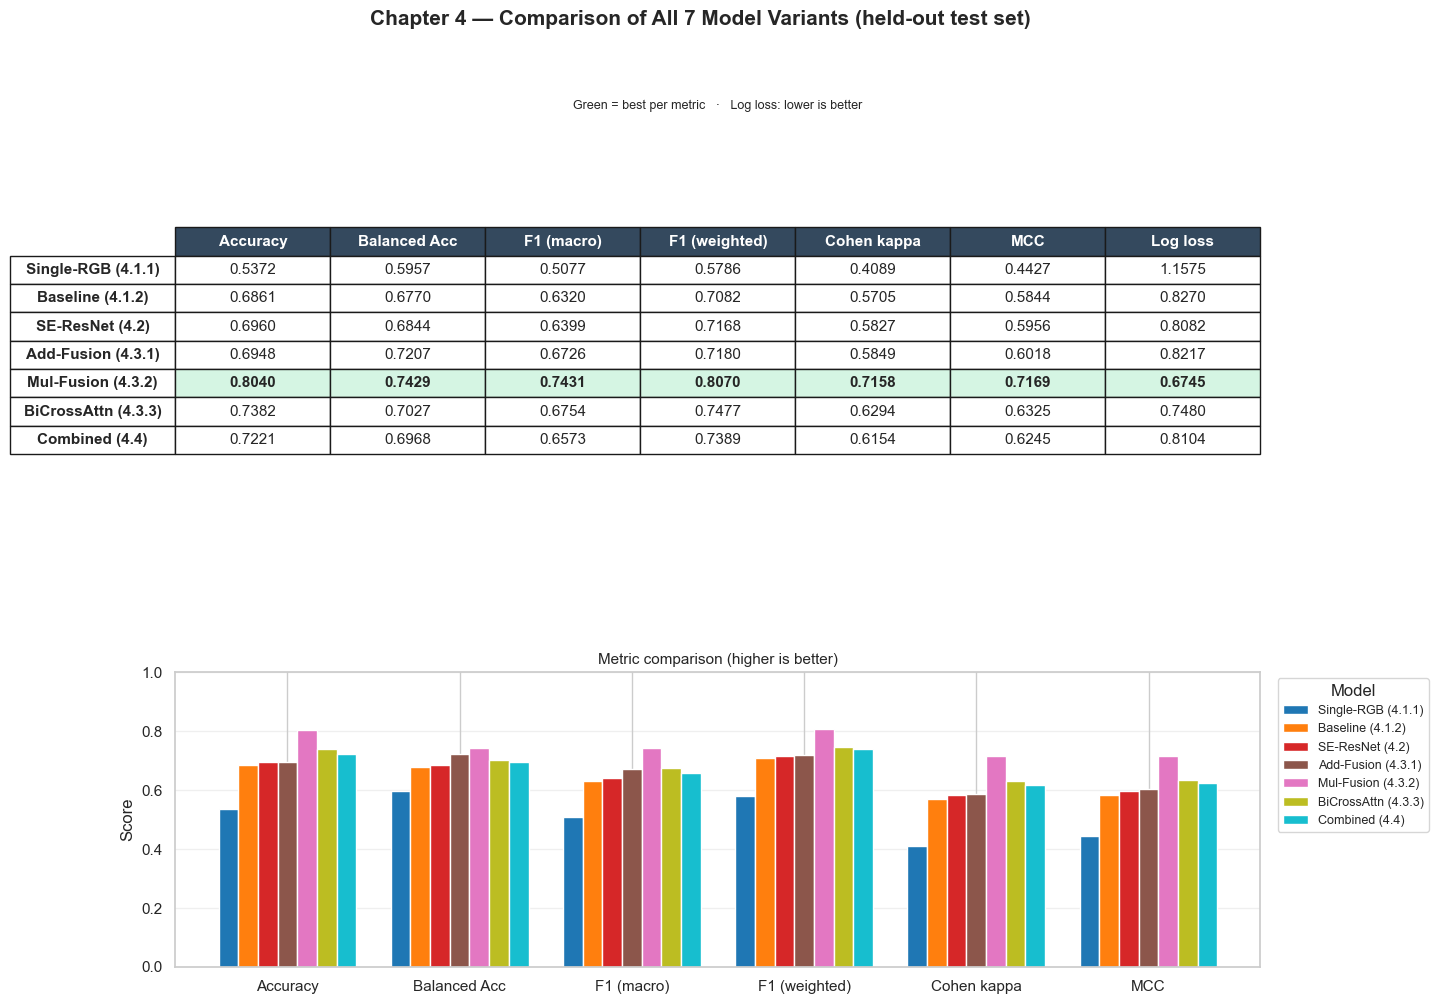

In [12]:
# ── Section 5.6 — Unified comparison: all 7 Chapter-4 variants ────────────────
# Self-contained: redefines every model, loads each checkpoint if present
# (missing checkpoints are skipped), evaluates on the shared held-out test set.
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    cohen_kappa_score, matthews_corrcoef, log_loss
)

warnings.filterwarnings('ignore')
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
device = torch.device('mps' if torch.backends.mps.is_available() else
                      'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# ── Data (mirrors every section's prep) ──────────────────────────────────────
DERM7PT_DIR = Path('dataset') / 'Derm7pt'
MILK_DIR    = Path('dataset') / 'milk10k'

derm_df = pd.read_csv(DERM7PT_DIR / 'meta' / 'meta.csv')
derm_df['clinic_path'] = derm_df['clinic'].apply(lambda x: str(DERM7PT_DIR / 'images' / x))
derm_df['derm_path']   = derm_df['derm'].apply(lambda x: str(DERM7PT_DIR / 'images' / x))
derm_df['diagnosis']   = derm_df['diagnosis'].str.strip().str.lower()
diagnosis_groups = {
    'melanoma': 'MEL', 'melanoma (less than 0.76 mm)': 'MEL', 'melanoma (in situ)': 'MEL',
    'melanoma (0.76 to 1.5 mm)': 'MEL', 'melanoma (more than 1.5 mm)': 'MEL',
    'melanoma metastasis': 'MEL',
    'clark nevus': 'NV', 'reed or spitz nevus': 'NV', 'dermal nevus': 'NV',
    'blue nevus': 'NV', 'congenital nevus': 'NV', 'combined nevus': 'NV',
    'recurrent nevus': 'NV',
    'basal cell carcinoma': 'BCC',
    'seborrheic keratosis': 'SK',
    'lentigo': 'MISC', 'dermatofibroma': 'MISC', 'vascular lesion': 'MISC',
    'melanosis': 'MISC', 'miscellaneous': 'MISC',
}
derm_df['diagnosis_group'] = derm_df['diagnosis'].map(diagnosis_groups)
class_names = sorted(derm_df['diagnosis_group'].dropna().unique())
label_map   = {name: i for i, name in enumerate(class_names)}

milk_meta = pd.read_csv(MILK_DIR / 'MILK10k_Training_Metadata.csv')
milk_gt   = pd.read_csv(MILK_DIR / 'MILK10k_Training_GroundTruth.csv')
milk_class_map = {'MEL': 'MEL', 'NV': 'NV', 'BCC': 'BCC', 'BKL': 'SK', 'DF': 'MISC', 'VASC': 'MISC'}
drop_classes   = {'AKIEC', 'SCCKA', 'INF', 'BEN_OTH', 'MAL_OTH'}
gt_cols = [c for c in milk_gt.columns if c != 'lesion_id']
milk_gt['raw_class'] = milk_gt[gt_cols].idxmax(axis=1)
milk_gt = milk_gt[~milk_gt['raw_class'].isin(drop_classes)].copy()
milk_gt['diagnosis_group'] = milk_gt['raw_class'].map(milk_class_map)
clinic_meta = (milk_meta[milk_meta['image_type'] == 'clinical: close-up']
               [['lesion_id', 'isic_id']].rename(columns={'isic_id': 'clinic_isic'}))
derm_meta   = (milk_meta[milk_meta['image_type'] == 'dermoscopic']
               [['lesion_id', 'isic_id']].rename(columns={'isic_id': 'derm_isic'}))
paths = clinic_meta.merge(derm_meta, on='lesion_id')
milk_df = milk_gt[['lesion_id', 'diagnosis_group']].merge(paths, on='lesion_id')
milk_df['clinic_path'] = milk_df.apply(
    lambda r: str(MILK_DIR / 'MILK10k_Training_Input' / r['lesion_id'] / f"{r['clinic_isic']}.jpg"), axis=1)
milk_df['derm_path'] = milk_df.apply(
    lambda r: str(MILK_DIR / 'MILK10k_Training_Input' / r['lesion_id'] / f"{r['derm_isic']}.jpg"), axis=1)

derm7_clean = derm_df[['clinic_path', 'derm_path', 'diagnosis_group']].copy()
combined = pd.concat([derm7_clean, milk_df[['clinic_path', 'derm_path', 'diagnosis_group']]],
                     ignore_index=True)
combined['label'] = combined['diagnosis_group'].map(label_map)
df = combined.dropna(subset=['label']).reset_index(drop=True)

labels  = df['label'].values.astype(int)
indices = np.arange(len(df))
train_idx, temp_idx = train_test_split(indices, test_size=0.30, stratify=labels, random_state=SEED)
val_idx,  test_idx  = train_test_split(temp_idx, test_size=0.50, stratify=labels[temp_idx], random_state=SEED)

val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class SkinLesionDualDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        clinic_img = Image.open(row['clinic_path']).convert('RGB')
        derm_img   = Image.open(row['derm_path']).convert('RGB')
        if self.transform:
            clinic_img = self.transform(clinic_img)
            derm_img   = self.transform(derm_img)
        return clinic_img, derm_img, torch.tensor(row['label'], dtype=torch.long)

test_ds = SkinLesionDualDataset(df.iloc[test_idx], val_transform)
_NUM_WORKERS = 0 if device.type in ('mps', 'cpu') or os.name == 'nt' else min(8, os.cpu_count() or 4)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=_NUM_WORKERS,
                         pin_memory=(device.type == 'cuda'))
print(f'Test samples: {len(test_ds)}')


# ── Model definitions (all 7 variants; pretrained=False — weights come from ckpt) ──
class ResNet50Backbone(nn.Module):
    def __init__(self, pretrained=False):
        super().__init__()
        base = models.resnet50(weights=models.ResNet50_Weights.DEFAULT if pretrained else None)
        self.features = nn.Sequential(
            base.conv1, base.bn1, base.relu, base.maxpool,
            base.layer1, base.layer2, base.layer3, base.layer4)
    def forward(self, x): return self.features(x)


class SingleBranchRGBClassifier(nn.Module):
    def __init__(self, num_classes=5, dropout=0.32):
        super().__init__()
        self.resnet_clinic = ResNet50Backbone(pretrained=False)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Linear(2048, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True),
            nn.Dropout(dropout), nn.Linear(512, num_classes))
    def forward(self, clinic_img, derm_img=None):
        x = self.pool(self.resnet_clinic(clinic_img)).flatten(1)
        return self.classifier(x), None


class DualBranchBaseline(nn.Module):
    def __init__(self, num_classes=5, dropout=0.32):
        super().__init__()
        self.resnet_clinic = ResNet50Backbone(pretrained=False)
        self.resnet_derm   = ResNet50Backbone(pretrained=False)
        self.fusion = nn.Sequential(
            nn.Conv2d(4096, 1024, kernel_size=1, bias=False),
            nn.BatchNorm2d(1024), nn.ReLU(inplace=True))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Linear(1024, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True),
            nn.Dropout(dropout), nn.Linear(512, num_classes))
    def forward(self, clinic_img, derm_img):
        feat_c = self.resnet_clinic(clinic_img)
        feat_d = self.resnet_derm(derm_img)
        x = self.fusion(torch.cat([feat_c, feat_d], dim=1))
        x = self.pool(x).flatten(1)
        return self.classifier(x), None


class DualBranchElementwiseFusion(nn.Module):
    def __init__(self, num_classes=5, dropout=0.32, fusion='add'):
        super().__init__()
        self.fusion = fusion
        self.resnet_clinic = ResNet50Backbone(pretrained=False)
        self.resnet_derm   = ResNet50Backbone(pretrained=False)
        self.post_fuse = nn.Sequential(nn.BatchNorm2d(2048), nn.ReLU(inplace=True))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Linear(2048, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True),
            nn.Dropout(dropout), nn.Linear(512, num_classes))
    def forward(self, clinic_img, derm_img):
        feat_c = self.resnet_clinic(clinic_img)
        feat_d = self.resnet_derm(derm_img)
        fused = feat_c + feat_d if self.fusion == 'add' else feat_c * feat_d
        x = self.pool(self.post_fuse(fused)).flatten(1)
        return self.classifier(x), None


class CrossAttentionFusion(nn.Module):
    def __init__(self, in_dim=2048, embed_dim=512, num_heads=8, dropout=0.1):
        super().__init__()
        self.q_proj = nn.Linear(in_dim, embed_dim)
        self.k_proj = nn.Linear(in_dim, embed_dim)
        self.v_proj = nn.Linear(in_dim, embed_dim)
        self.attn   = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm1  = nn.LayerNorm(embed_dim)
        self.ffn    = nn.Sequential(nn.Linear(embed_dim, embed_dim * 2), nn.GELU(),
                                     nn.Dropout(dropout), nn.Linear(embed_dim * 2, embed_dim))
        self.norm2 = nn.LayerNorm(embed_dim)
        self.pool  = nn.AdaptiveAvgPool1d(1)
    def forward(self, clinic_feat, derm_feat):
        c = clinic_feat.flatten(2).transpose(1, 2)
        d = derm_feat.flatten(2).transpose(1, 2)
        Q = self.q_proj(c); K = self.k_proj(d); V = self.v_proj(d)
        attn_out, attn_weights = self.attn(Q, K, V, need_weights=True, average_attn_weights=True)
        x = self.norm1(Q + attn_out)
        x = self.norm2(x + self.ffn(x))
        fused = self.pool(x.transpose(1, 2)).squeeze(-1)
        return fused, attn_weights


class BidirectionalCrossAttnFusion(nn.Module):
    def __init__(self, in_dim=2048, embed_dim=256, num_heads=4, dropout=0.32):
        super().__init__()
        self.c2d  = CrossAttentionFusion(in_dim, embed_dim, num_heads, dropout)
        self.d2c  = CrossAttentionFusion(in_dim, embed_dim, num_heads, dropout)
        self.proj = nn.Linear(embed_dim * 2, embed_dim)
    def forward(self, clinic_feat, derm_feat):
        fused_c2d, attn_c2d = self.c2d(clinic_feat, derm_feat)
        fused_d2c, attn_d2c = self.d2c(derm_feat, clinic_feat)
        fused = self.proj(torch.cat([fused_c2d, fused_d2c], dim=1))
        return fused, (attn_c2d, attn_d2c)


class DualBranchBiCrossAttn(nn.Module):
    def __init__(self, num_classes=5, embed_dim=256, num_heads=4, dropout=0.32):
        super().__init__()
        self.resnet_clinic = ResNet50Backbone(pretrained=False)
        self.resnet_derm   = ResNet50Backbone(pretrained=False)
        self.fusion        = BidirectionalCrossAttnFusion(2048, embed_dim, num_heads, dropout)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2), nn.BatchNorm1d(embed_dim // 2),
            nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(embed_dim // 2, num_classes))
    def forward(self, clinic_img, derm_img):
        feat_c = self.resnet_clinic(clinic_img)
        feat_d = self.resnet_derm(derm_img)
        fused, attn_weights = self.fusion(feat_c, feat_d)
        return self.classifier(fused), attn_weights


class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False))
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        b, c, _, _ = x.shape
        w = self.sigmoid(self.fc(self.avg_pool(x).view(b, c))).view(b, c, 1, 1)
        return x * w


class SEBottleneck(nn.Module):
    def __init__(self, bottleneck, reduction=16):
        super().__init__()
        self.block = bottleneck
        self.se    = SEBlock(bottleneck.conv3.out_channels, reduction)
    def forward(self, x):
        identity = x
        out = self.block.conv1(x); out = self.block.bn1(out); out = self.block.relu(out)
        out = self.block.conv2(out); out = self.block.bn2(out); out = self.block.relu(out)
        out = self.block.conv3(out); out = self.block.bn3(out)
        out = self.se(out)
        if self.block.downsample is not None:
            identity = self.block.downsample(x)
        out = out + identity
        return self.block.relu(out)


class SEResNet50Backbone(nn.Module):
    def __init__(self, pretrained=False, reduction=16):
        super().__init__()
        base = models.resnet50(weights=models.ResNet50_Weights.DEFAULT if pretrained else None)
        for layer in [base.layer1, base.layer2, base.layer3, base.layer4]:
            for i in range(len(layer)):
                layer[i] = SEBottleneck(layer[i], reduction=reduction)
        self.features = nn.Sequential(
            base.conv1, base.bn1, base.relu, base.maxpool,
            base.layer1, base.layer2, base.layer3, base.layer4)
    def forward(self, x): return self.features(x)


class DualBranchSEResNet(nn.Module):
    def __init__(self, num_classes=5, dropout=0.32):
        super().__init__()
        self.resnet_clinic = SEResNet50Backbone(pretrained=False)
        self.resnet_derm   = SEResNet50Backbone(pretrained=False)
        self.fusion = nn.Sequential(
            nn.Conv2d(4096, 1024, kernel_size=1, bias=False),
            nn.BatchNorm2d(1024), nn.ReLU(inplace=True))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Linear(1024, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True),
            nn.Dropout(dropout), nn.Linear(512, num_classes))
    def forward(self, clinic_img, derm_img):
        feat_c = self.resnet_clinic(clinic_img)
        feat_d = self.resnet_derm(derm_img)
        x = self.fusion(torch.cat([feat_c, feat_d], dim=1))
        x = self.pool(x).flatten(1)
        return self.classifier(x), None


class DualBranchSECrossCombined(nn.Module):
    def __init__(self, num_classes=5, embed_dim=256, num_heads=4, dropout=0.32):
        super().__init__()
        self.resnet_clinic = SEResNet50Backbone(pretrained=False)
        self.resnet_derm   = SEResNet50Backbone(pretrained=False)
        self.fusion        = BidirectionalCrossAttnFusion(2048, embed_dim, num_heads, dropout)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2), nn.BatchNorm1d(embed_dim // 2),
            nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(embed_dim // 2, num_classes))
    def forward(self, clinic_img, derm_img):
        feat_c = self.resnet_clinic(clinic_img)
        feat_d = self.resnet_derm(derm_img)
        fused, attn_weights = self.fusion(feat_c, feat_d)
        return self.classifier(fused), attn_weights


# ── Evaluate each checkpoint (Chapter-4 narrative order) ─────────────────────
NC = len(class_names)
MODELS_TO_EVAL = [
    ('Single-RGB (4.1.1)',  SingleBranchRGBClassifier,   {'num_classes': NC, 'dropout': 0.32},
     'thesis_singlebranch_rgb_best.pth'),
    ('Baseline (4.1.2)',    DualBranchBaseline,          {'num_classes': NC, 'dropout': 0.32},
     'thesis_baseline_best.pth'),
    ('SE-ResNet (4.2)',     DualBranchSEResNet,          {'num_classes': NC, 'dropout': 0.32},
     'thesis_channel_best.pth'),
    ('Add-Fusion (4.3.1)',  DualBranchElementwiseFusion, {'num_classes': NC, 'dropout': 0.32, 'fusion': 'add'},
     'thesis_addfusion_best.pth'),
    ('Mul-Fusion (4.3.2)',  DualBranchElementwiseFusion, {'num_classes': NC, 'dropout': 0.32, 'fusion': 'mul'},
     'thesis_mulfusion_best.pth'),
    ('BiCrossAttn (4.3.3)', DualBranchBiCrossAttn,       {'num_classes': NC, 'embed_dim': 256,
                                                          'num_heads': 4, 'dropout': 0.32},
     'thesis_bicross_best.pth'),
    ('Combined (4.4)',      DualBranchSECrossCombined,   {'num_classes': NC, 'embed_dim': 256,
                                                          'num_heads': 4, 'dropout': 0.32},
     'thesis_combined_best.pth'),
]

results = {}
for name, cls, kwargs, ckpt_path in MODELS_TO_EVAL:
    if not Path(ckpt_path).exists():
        print(f'  {name}: {ckpt_path} not found - skipping')
        continue
    print(f'Evaluating {name} from {ckpt_path}')
    model = cls(**kwargs).to(device)
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()

    preds, y, probs = [], [], []
    with torch.no_grad():
        for clinic_imgs, derm_imgs, lb in test_loader:
            logits, _ = model(clinic_imgs.to(device), derm_imgs.to(device))
            p = F.softmax(logits, dim=1)
            preds.extend(logits.argmax(1).cpu().numpy())
            y.extend(lb.numpy())
            probs.extend(p.cpu().numpy())

    y = np.array(y); preds = np.array(preds); probs = np.array(probs)
    results[name] = {
        'accuracy':          accuracy_score(y, preds),
        'balanced_accuracy': balanced_accuracy_score(y, preds),
        'f1_macro':          f1_score(y, preds, average='macro',    zero_division=0),
        'f1_weighted':       f1_score(y, preds, average='weighted', zero_division=0),
        'cohen_kappa':       cohen_kappa_score(y, preds),
        'mcc':               matthews_corrcoef(y, preds),
        'log_loss':          log_loss(y, probs, labels=list(range(NC))),
    }
    print(f'  acc={results[name]["accuracy"]:.4f}  '
          f'f1_macro={results[name]["f1_macro"]:.4f}  '
          f'kappa={results[name]["cohen_kappa"]:.4f}')
    del model
    if torch.cuda.is_available(): torch.cuda.empty_cache()


# ── One shareable figure: metrics table + bar chart ──────────────────
if results:
    df_cmp = pd.DataFrame(results).T
    df_cmp = df_cmp[['accuracy', 'balanced_accuracy', 'f1_macro', 'f1_weighted',
                     'cohen_kappa', 'mcc', 'log_loss']]
    df_cmp.index.name = 'Model'
    df_cmp.to_csv('comparison_metrics_all.csv')

    # Single figure: rendered table on top, grouped bar chart below
    fig = plt.figure(figsize=(14, 11))
    gs = fig.add_gridspec(2, 1, height_ratios=[len(df_cmp) + 2, 6], hspace=0.30)
    fig.suptitle('Chapter 4 — Comparison of All 7 Model Variants (held-out test set)',
                 fontsize=15, fontweight='bold', y=0.98)

    # ── Metrics table ─────────────────────────────────────────
    ax_t = fig.add_subplot(gs[0]); ax_t.axis('off')
    col_labels = ['Accuracy', 'Balanced Acc', 'F1 (macro)', 'F1 (weighted)',
                  'Cohen kappa', 'MCC', 'Log loss']
    cell_text = [[f'{v:.4f}' for v in row] for row in df_cmp.values]
    table = ax_t.table(cellText=cell_text, rowLabels=df_cmp.index, colLabels=col_labels,
                       cellLoc='center', rowLoc='center', loc='center')
    table.auto_set_font_size(False); table.set_fontsize(11); table.scale(1, 1.7)
    for j in range(len(col_labels)):
        table[0, j].set_facecolor('#34495e')
        table[0, j].set_text_props(color='white', fontweight='bold')
    for i in range(len(df_cmp)):
        table[i + 1, -1].set_text_props(fontweight='bold')
    # Highlight best per metric in green (log_loss: lower is better)
    for j, col in enumerate(df_cmp.columns):
        best_i = df_cmp[col].idxmin() if col == 'log_loss' else df_cmp[col].idxmax()
        r = list(df_cmp.index).index(best_i)
        table[r + 1, j].set_facecolor('#d5f5e3')
        table[r + 1, j].set_text_props(fontweight='bold')
    ax_t.set_title('Green = best per metric   ·   Log loss: lower is better',
                   fontsize=9, pad=8)

    # ── Bar chart ─────────────────────────────────────────────
    ax_b = fig.add_subplot(gs[1])
    metrics_to_plot = ['accuracy', 'balanced_accuracy', 'f1_macro', 'f1_weighted',
                       'cohen_kappa', 'mcc']
    df_cmp[metrics_to_plot].T.plot(kind='bar', ax=ax_b, rot=0, colormap='tab10', width=0.8)
    ax_b.set_ylabel('Score'); ax_b.set_ylim(0, 1)
    ax_b.set_title('Metric comparison (higher is better)', fontsize=11)
    ax_b.set_xticklabels(['Accuracy', 'Balanced Acc', 'F1 (macro)', 'F1 (weighted)',
                          'Cohen kappa', 'MCC'])
    ax_b.legend(title='Model', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
    ax_b.grid(alpha=0.3, axis='y')

    plt.savefig('chapter4_comparison.png', dpi=200, bbox_inches='tight')
    print('Saved -> comparison_metrics_all.csv')
    print('Saved -> chapter4_comparison.png   (single image — ready to share)')
    plt.show()
else:
    print('No checkpoints found - train Sections 1-5 first.')


# ══════════════════════════════════════════════════════════════════════
# Section 6 — Dataset Ablation: Derm7pt vs MILK10k

Sections 1–5 train every model on the **merged** Derm7pt + MILK10k pool. This
section runs the **4.4 dataset ablation**: the same four architectures are
trained **separately on each dataset**, so the ablation can be shown to hold on
Derm7pt and on MILK10k *independently* — the handwritten "one dataset / another
dataset" axis.

| Architecture | Channel attn (SENet) | Cross attn | Merged checkpoint |
|---|---|---|---|
| Baseline | – | – | `thesis_baseline_best.pth` |
| BiCrossAttn | – | ✓ | `thesis_bicross_best.pth` |
| SE-ResNet | ✓ | – | `thesis_channel_best.pth` |
| Combined (full) | ✓ | ✓ | `thesis_combined_best.pth` |

- **Derm7pt** — paired clinical + dermoscopic, ~1,011 cases
- **MILK10k** — paired clinical + dermoscopic, larger
- **Merged** — reference column; reuses the Section 1–4 checkpoints (no retraining)

**8 models are trained here** (4 architectures × 2 datasets). Each dataset gets
its own stratified 70/15/15 split, class weights, and checkpoints. For a quick
smoke test, lower `FINAL_EPOCHS` in cell 6.1 before running 6.3 / 6.4.

### 6.1 — Setup & per-dataset utilities

In [13]:
import os, copy, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, f1_score, accuracy_score, balanced_accuracy_score,
    cohen_kappa_score, matthews_corrcoef, log_loss
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('mps' if torch.backends.mps.is_available() else
                      'cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
print(f'Device: {device}')

DERM7PT_DIR = Path('dataset') / 'Derm7pt'
MILK_DIR    = Path('dataset') / 'milk10k'

# ── Derm7pt ──────────────────────────────────────────────────────────────────
derm_df = pd.read_csv(DERM7PT_DIR / 'meta' / 'meta.csv')
derm_df['clinic_path'] = derm_df['clinic'].apply(lambda x: str(DERM7PT_DIR / 'images' / x))
derm_df['derm_path']   = derm_df['derm'].apply(lambda x: str(DERM7PT_DIR / 'images' / x))
derm_df['diagnosis']   = derm_df['diagnosis'].str.strip().str.lower()
diagnosis_groups = {
    'melanoma': 'MEL', 'melanoma (less than 0.76 mm)': 'MEL', 'melanoma (in situ)': 'MEL',
    'melanoma (0.76 to 1.5 mm)': 'MEL', 'melanoma (more than 1.5 mm)': 'MEL',
    'melanoma metastasis': 'MEL',
    'clark nevus': 'NV', 'reed or spitz nevus': 'NV', 'dermal nevus': 'NV',
    'blue nevus': 'NV', 'congenital nevus': 'NV', 'combined nevus': 'NV',
    'recurrent nevus': 'NV',
    'basal cell carcinoma': 'BCC',
    'seborrheic keratosis': 'SK',
    'lentigo': 'MISC', 'dermatofibroma': 'MISC', 'vascular lesion': 'MISC',
    'melanosis': 'MISC', 'miscellaneous': 'MISC',
}
derm_df['diagnosis_group'] = derm_df['diagnosis'].map(diagnosis_groups)
class_names = sorted(derm_df['diagnosis_group'].dropna().unique())
label_map   = {name: i for i, name in enumerate(class_names)}

# ── MILK10k ──────────────────────────────────────────────────────────────────
milk_meta = pd.read_csv(MILK_DIR / 'MILK10k_Training_Metadata.csv')
milk_gt   = pd.read_csv(MILK_DIR / 'MILK10k_Training_GroundTruth.csv')
milk_class_map = {'MEL': 'MEL', 'NV': 'NV', 'BCC': 'BCC', 'BKL': 'SK', 'DF': 'MISC', 'VASC': 'MISC'}
drop_classes   = {'AKIEC', 'SCCKA', 'INF', 'BEN_OTH', 'MAL_OTH'}
gt_cols = [c for c in milk_gt.columns if c != 'lesion_id']
milk_gt['raw_class'] = milk_gt[gt_cols].idxmax(axis=1)
milk_gt = milk_gt[~milk_gt['raw_class'].isin(drop_classes)].copy()
milk_gt['diagnosis_group'] = milk_gt['raw_class'].map(milk_class_map)
clinic_meta = (milk_meta[milk_meta['image_type'] == 'clinical: close-up']
               [['lesion_id', 'isic_id']].rename(columns={'isic_id': 'clinic_isic'}))
derm_meta   = (milk_meta[milk_meta['image_type'] == 'dermoscopic']
               [['lesion_id', 'isic_id']].rename(columns={'isic_id': 'derm_isic'}))
paths = clinic_meta.merge(derm_meta, on='lesion_id')
milk_df = milk_gt[['lesion_id', 'diagnosis_group']].merge(paths, on='lesion_id')
milk_df['clinic_path'] = milk_df.apply(
    lambda r: str(MILK_DIR / 'MILK10k_Training_Input' / r['lesion_id'] / f"{r['clinic_isic']}.jpg"), axis=1)
milk_df['derm_path'] = milk_df.apply(
    lambda r: str(MILK_DIR / 'MILK10k_Training_Input' / r['lesion_id'] / f"{r['derm_isic']}.jpg"), axis=1)
milk_df['source'] = 'MILK10k'

# ── Full pool with a `source` column (used to filter per dataset) ────────────
derm7_clean = derm_df[['clinic_path', 'derm_path', 'diagnosis_group']].copy()
derm7_clean['source'] = 'Derm7pt'
combined = pd.concat(
    [derm7_clean, milk_df[['clinic_path', 'derm_path', 'diagnosis_group', 'source']]],
    ignore_index=True)
combined['label'] = combined['diagnosis_group'].map(label_map)
df = combined.dropna(subset=['label']).reset_index(drop=True)
print(f'Pool: {len(df)} samples  ('
      f"Derm7pt={int((df['source']=='Derm7pt').sum())}, "
      f"MILK10k={int((df['source']=='MILK10k').sum())})  | {len(class_names)} classes")


# ── Transforms ───────────────────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


class SkinLesionDualDataset(Dataset):
    """Returns (clinic_img, derm_img, label) for each sample."""
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        clinic_img = Image.open(row['clinic_path']).convert('RGB')
        derm_img   = Image.open(row['derm_path']).convert('RGB')
        if self.transform:
            clinic_img = self.transform(clinic_img)
            derm_img   = self.transform(derm_img)
        return clinic_img, derm_img, torch.tensor(row['label'], dtype=torch.long)


# ── Fixed hyperparameters (shared with Sections 1-4) ─────────────────────────
LR             = 0.000750
DROPOUT        = 0.32
EMBED_DIM      = 256
NUM_HEADS      = 4
WEIGHT_DECAY   = 0.000957
BATCH_SIZE     = 64
FINAL_EPOCHS   = 60
PATIENCE       = 20
UNFREEZE_EPOCH = 5
GRAD_CLIP      = 1.0

_NUM_WORKERS = 0 if device.type in ('mps', 'cpu') or os.name == 'nt' else min(8, os.cpu_count() or 4)
_PIN_MEMORY  = device.type == 'cuda'


def split_indices(sub):
    """Stratified 70/15/15 split of a dataframe — same scheme as every section."""
    y = sub['label'].values.astype(int)
    idx = np.arange(len(sub))
    tr_i, tmp_i = train_test_split(idx, test_size=0.30, stratify=y, random_state=SEED)
    va_i, te_i  = train_test_split(tmp_i, test_size=0.50, stratify=y[tmp_i], random_state=SEED)
    return tr_i, va_i, te_i


def make_dataset_loaders(source, batch_size=BATCH_SIZE):
    """Train/val/test loaders + loss weights for one dataset
    ('Derm7pt', 'MILK10k', or 'Merged')."""
    sub = df if source == 'Merged' else df[df['source'] == source].reset_index(drop=True)
    tr_i, va_i, te_i = split_indices(sub)
    tr_y = sub['label'].values.astype(int)[tr_i]
    counts = np.bincount(tr_y, minlength=len(class_names))
    samp_w = (1.0 / np.where(counts == 0, 1, counts))[tr_y]
    loss_w = torch.tensor(
        [len(tr_y) / (len(class_names) * c) if c > 0 else 0.0 for c in counts],
        dtype=torch.float32).to(device)
    tr_ds = SkinLesionDualDataset(sub.iloc[tr_i], train_transform)
    va_ds = SkinLesionDualDataset(sub.iloc[va_i], val_transform)
    te_ds = SkinLesionDualDataset(sub.iloc[te_i], val_transform)
    sampler = WeightedRandomSampler(samp_w, len(tr_y), replacement=True)
    kw = dict(num_workers=_NUM_WORKERS, pin_memory=_PIN_MEMORY,
              persistent_workers=(_NUM_WORKERS > 0))
    tr_ld = DataLoader(tr_ds, batch_size=batch_size, sampler=sampler, **kw)
    va_ld = DataLoader(va_ds, batch_size=batch_size, shuffle=False, **kw)
    te_ld = DataLoader(te_ds, batch_size=batch_size, shuffle=False, **kw)
    print(f'  {source}: {len(sub)} samples -> '
          f'train {len(tr_i)} / val {len(va_i)} / test {len(te_i)}')
    return tr_ld, va_ld, te_ld, loss_w


class EarlyStopping:
    """Stops training if val_loss doesn't improve for `patience` consecutive epochs."""
    def __init__(self, patience=20, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_loss  = float('inf')
        self.best_state = None
        self.stop = False

    def __call__(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter    = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

    def restore(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


def train_one_epoch(model, loader, optimizer, criterion, grad_clip):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for clinic_imgs, derm_imgs, labels_batch in loader:
        clinic_imgs  = clinic_imgs.to(device)
        derm_imgs    = derm_imgs.to(device)
        labels_batch = labels_batch.to(device)
        optimizer.zero_grad()
        logits, _ = model(clinic_imgs, derm_imgs)
        loss      = criterion(logits, labels_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        total_loss += loss.item() * clinic_imgs.size(0)
        correct    += logits.argmax(1).eq(labels_batch).sum().item()
        total      += clinic_imgs.size(0)
    return total_loss / total, correct / total


def validate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for clinic_imgs, derm_imgs, labels_batch in loader:
            clinic_imgs  = clinic_imgs.to(device)
            derm_imgs    = derm_imgs.to(device)
            labels_batch = labels_batch.to(device)
            logits, _    = model(clinic_imgs, derm_imgs)
            loss         = criterion(logits, labels_batch)
            total_loss  += loss.item() * clinic_imgs.size(0)
            correct     += logits.argmax(1).eq(labels_batch).sum().item()
            total       += clinic_imgs.size(0)
    return total_loss / total, correct / total


def run_training(model, train_loader, val_loader, loss_weights, ckpt_path, tag):
    """Warm-up freeze -> unfreeze layer3 at UNFREEZE_EPOCH -> cosine LR, early stopping.
    Same loop as Sections 1-4; prints a compact summary every 5 epochs."""
    model = model.to(device)
    model._freeze_backbones()
    criterion = nn.CrossEntropyLoss(weight=loss_weights)
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()),
                           lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=UNFREEZE_EPOCH)
    early_stop = EarlyStopping(patience=PATIENCE)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    early_stop_epoch = None
    start = time.time()

    for epoch in range(FINAL_EPOCHS):
        if epoch == UNFREEZE_EPOCH:
            model.unfreeze_resnets()
            optimizer = optim.Adam(model.parameters(), lr=LR / 4, weight_decay=WEIGHT_DECAY)
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=FINAL_EPOCHS - UNFREEZE_EPOCH)

        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, GRAD_CLIP)
        va_loss, va_acc = validate(model, val_loader, criterion)
        scheduler.step()
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)

        early_stop(va_loss, model)
        if epoch == 0 or (epoch + 1) % 5 == 0 or early_stop.stop:
            print(f'    ep {epoch+1:2d}/{FINAL_EPOCHS} | '
                  f'train {tr_loss:.3f}/{tr_acc:.3f} | val {va_loss:.3f}/{va_acc:.3f} | '
                  f'es {early_stop.counter}/{PATIENCE}')
        if early_stop.stop:
            early_stop_epoch = epoch + 1
            early_stop.restore(model)
            break

    print(f'  {tag}: {(time.time()-start)/60:.1f} min | '
          f'best val loss {early_stop.best_loss:.4f} | '
          f'epochs {early_stop_epoch or FINAL_EPOCHS}')
    torch.save({
        'model_state_dict': model.state_dict(),
        'class_names':      class_names,
        'label_map':        label_map,
        'history':          history,
        'best_val_loss':    early_stop.best_loss,
        'early_stop_epoch': early_stop_epoch,
    }, ckpt_path)
    print(f'  saved -> {ckpt_path}')
    return model

print('Setup ready. FINAL_EPOCHS =', FINAL_EPOCHS)

Device: cuda
Pool: 5372 samples  (Derm7pt=1011, MILK10k=4361)  | 5 classes
Setup ready. FINAL_EPOCHS = 60


### 6.2 — Model definitions (4 architectures)

The same four architectures used in Sections 1–4 — defined once here so this
section runs independently.

In [14]:
class ResNet50Backbone(nn.Module):
    """ResNet50 feature extractor — returns spatial feature maps [B, 2048, 7, 7]."""
    def __init__(self, pretrained=True):
        super().__init__()
        base = models.resnet50(weights=models.ResNet50_Weights.DEFAULT if pretrained else None)
        self.features = nn.Sequential(
            base.conv1, base.bn1, base.relu, base.maxpool,
            base.layer1, base.layer2, base.layer3, base.layer4)

    def forward(self, x):
        return self.features(x)


class SEBlock(nn.Module):
    """Squeeze-and-Excitation channel attention (Hu et al. CVPR 2018)."""
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False))
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, _, _ = x.shape
        w = self.sigmoid(self.fc(self.avg_pool(x).view(b, c))).view(b, c, 1, 1)
        return x * w


class SEBottleneck(nn.Module):
    """Wraps a torchvision Bottleneck, injecting an SE block on the residual branch."""
    def __init__(self, bottleneck, reduction=16):
        super().__init__()
        self.block = bottleneck
        self.se    = SEBlock(bottleneck.conv3.out_channels, reduction)

    def forward(self, x):
        identity = x
        out = self.block.conv1(x); out = self.block.bn1(out); out = self.block.relu(out)
        out = self.block.conv2(out); out = self.block.bn2(out); out = self.block.relu(out)
        out = self.block.conv3(out); out = self.block.bn3(out)
        out = self.se(out)
        if self.block.downsample is not None:
            identity = self.block.downsample(x)
        out = out + identity
        return self.block.relu(out)


class SEResNet50Backbone(nn.Module):
    """ResNet50 with SE blocks injected into every residual block."""
    def __init__(self, pretrained=True, reduction=16):
        super().__init__()
        base = models.resnet50(weights=models.ResNet50_Weights.DEFAULT if pretrained else None)
        for layer in [base.layer1, base.layer2, base.layer3, base.layer4]:
            for i in range(len(layer)):
                layer[i] = SEBottleneck(layer[i], reduction=reduction)
        self.features = nn.Sequential(
            base.conv1, base.bn1, base.relu, base.maxpool,
            base.layer1, base.layer2, base.layer3, base.layer4)

    def forward(self, x):
        return self.features(x)


class CrossAttentionFusion(nn.Module):
    """Unidirectional cross-attention building block."""
    def __init__(self, in_dim=2048, embed_dim=512, num_heads=8, dropout=0.1):
        super().__init__()
        self.q_proj = nn.Linear(in_dim, embed_dim)
        self.k_proj = nn.Linear(in_dim, embed_dim)
        self.v_proj = nn.Linear(in_dim, embed_dim)
        self.attn   = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm1  = nn.LayerNorm(embed_dim)
        self.ffn    = nn.Sequential(nn.Linear(embed_dim, embed_dim * 2), nn.GELU(),
                                     nn.Dropout(dropout), nn.Linear(embed_dim * 2, embed_dim))
        self.norm2 = nn.LayerNorm(embed_dim)
        self.pool  = nn.AdaptiveAvgPool1d(1)

    def forward(self, clinic_feat, derm_feat):
        c = clinic_feat.flatten(2).transpose(1, 2)
        d = derm_feat.flatten(2).transpose(1, 2)
        Q = self.q_proj(c); K = self.k_proj(d); V = self.v_proj(d)
        attn_out, attn_weights = self.attn(Q, K, V, need_weights=True, average_attn_weights=True)
        x = self.norm1(Q + attn_out)
        x = self.norm2(x + self.ffn(x))
        fused = self.pool(x.transpose(1, 2)).squeeze(-1)
        return fused, attn_weights


class BidirectionalCrossAttnFusion(nn.Module):
    """Bidirectional cross-attention: clinic->derm + derm->clinic, concat then project."""
    def __init__(self, in_dim=2048, embed_dim=256, num_heads=4, dropout=0.32):
        super().__init__()
        self.c2d  = CrossAttentionFusion(in_dim, embed_dim, num_heads, dropout)
        self.d2c  = CrossAttentionFusion(in_dim, embed_dim, num_heads, dropout)
        self.proj = nn.Linear(embed_dim * 2, embed_dim)

    def forward(self, clinic_feat, derm_feat):
        fused_c2d, attn_c2d = self.c2d(clinic_feat, derm_feat)
        fused_d2c, attn_d2c = self.d2c(derm_feat, clinic_feat)
        fused = self.proj(torch.cat([fused_c2d, fused_d2c], dim=1))
        return fused, (attn_c2d, attn_d2c)


class DualBranchBaseline(nn.Module):
    """Baseline — dual ResNet50, concat fusion, no attention."""
    def __init__(self, num_classes=5, dropout=0.32):
        super().__init__()
        self.resnet_clinic = ResNet50Backbone(pretrained=True)
        self.resnet_derm   = ResNet50Backbone(pretrained=True)
        self.fusion = nn.Sequential(
            nn.Conv2d(4096, 1024, kernel_size=1, bias=False),
            nn.BatchNorm2d(1024), nn.ReLU(inplace=True))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Linear(1024, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True),
            nn.Dropout(dropout), nn.Linear(512, num_classes))

    def _freeze_backbones(self):
        for m in [self.resnet_clinic, self.resnet_derm]:
            for p in m.parameters(): p.requires_grad = False
            for p in m.features[7].parameters(): p.requires_grad = True

    def unfreeze_resnets(self):
        for m in [self.resnet_clinic, self.resnet_derm]:
            for p in m.features[6].parameters(): p.requires_grad = True

    def forward(self, clinic_img, derm_img):
        feat_c = self.resnet_clinic(clinic_img)
        feat_d = self.resnet_derm(derm_img)
        x = self.fusion(torch.cat([feat_c, feat_d], dim=1))
        x = self.pool(x).flatten(1)
        return self.classifier(x), None


class DualBranchBiCrossAttn(nn.Module):
    """Bidirectional cross-attention fusion (no channel attention)."""
    def __init__(self, num_classes=5, embed_dim=256, num_heads=4, dropout=0.32):
        super().__init__()
        self.resnet_clinic = ResNet50Backbone(pretrained=True)
        self.resnet_derm   = ResNet50Backbone(pretrained=True)
        self.fusion        = BidirectionalCrossAttnFusion(2048, embed_dim, num_heads, dropout)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2), nn.BatchNorm1d(embed_dim // 2),
            nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(embed_dim // 2, num_classes))

    def _freeze_backbones(self):
        for m in [self.resnet_clinic, self.resnet_derm]:
            for p in m.parameters(): p.requires_grad = False
            for p in m.features[7].parameters(): p.requires_grad = True

    def unfreeze_resnets(self):
        for m in [self.resnet_clinic, self.resnet_derm]:
            for p in m.features[6].parameters(): p.requires_grad = True

    def forward(self, clinic_img, derm_img):
        feat_c = self.resnet_clinic(clinic_img)
        feat_d = self.resnet_derm(derm_img)
        fused, attn_weights = self.fusion(feat_c, feat_d)
        return self.classifier(fused), attn_weights


class DualBranchSEResNet(nn.Module):
    """Dual-branch SE-ResNet50 — channel attention inside every residual block,
    concat fusion (no cross-attention)."""
    def __init__(self, num_classes=5, dropout=0.32):
        super().__init__()
        self.resnet_clinic = SEResNet50Backbone(pretrained=True)
        self.resnet_derm   = SEResNet50Backbone(pretrained=True)
        self.fusion = nn.Sequential(
            nn.Conv2d(4096, 1024, kernel_size=1, bias=False),
            nn.BatchNorm2d(1024), nn.ReLU(inplace=True))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Linear(1024, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True),
            nn.Dropout(dropout), nn.Linear(512, num_classes))

    def _freeze_backbones(self):
        for m in [self.resnet_clinic, self.resnet_derm]:
            for p in m.parameters(): p.requires_grad = False
            for p in m.features[7].parameters(): p.requires_grad = True
            for module in m.modules():
                if isinstance(module, SEBlock):
                    for p in module.parameters(): p.requires_grad = True

    def unfreeze_resnets(self):
        for m in [self.resnet_clinic, self.resnet_derm]:
            for p in m.features[6].parameters(): p.requires_grad = True

    def forward(self, clinic_img, derm_img):
        feat_c = self.resnet_clinic(clinic_img)
        feat_d = self.resnet_derm(derm_img)
        x = self.fusion(torch.cat([feat_c, feat_d], dim=1))
        x = self.pool(x).flatten(1)
        return self.classifier(x), None


class DualBranchSECrossCombined(nn.Module):
    """Full model — SE-ResNet50 backbones + bidirectional cross-attention fusion."""
    def __init__(self, num_classes=5, embed_dim=256, num_heads=4, dropout=0.32):
        super().__init__()
        self.resnet_clinic = SEResNet50Backbone(pretrained=True)
        self.resnet_derm   = SEResNet50Backbone(pretrained=True)
        self.fusion        = BidirectionalCrossAttnFusion(2048, embed_dim, num_heads, dropout)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2), nn.BatchNorm1d(embed_dim // 2),
            nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(embed_dim // 2, num_classes))

    def _freeze_backbones(self):
        for m in [self.resnet_clinic, self.resnet_derm]:
            for p in m.parameters(): p.requires_grad = False
            for p in m.features[7].parameters(): p.requires_grad = True
            for module in m.modules():
                if isinstance(module, SEBlock):
                    for p in module.parameters(): p.requires_grad = True

    def unfreeze_resnets(self):
        for m in [self.resnet_clinic, self.resnet_derm]:
            for p in m.features[6].parameters(): p.requires_grad = True

    def forward(self, clinic_img, derm_img):
        feat_c = self.resnet_clinic(clinic_img)
        feat_d = self.resnet_derm(derm_img)
        fused, attn_weights = self.fusion(feat_c, feat_d)
        return self.classifier(fused), attn_weights


NC = len(class_names)
ARCHS = [
    ('baseline', DualBranchBaseline,        dict(num_classes=NC, dropout=DROPOUT)),
    ('bicross',  DualBranchBiCrossAttn,     dict(num_classes=NC, embed_dim=EMBED_DIM,
                                                 num_heads=NUM_HEADS, dropout=DROPOUT)),
    ('channel',  DualBranchSEResNet,        dict(num_classes=NC, dropout=DROPOUT)),
    ('combined', DualBranchSECrossCombined, dict(num_classes=NC, embed_dim=EMBED_DIM,
                                                 num_heads=NUM_HEADS, dropout=DROPOUT)),
]
print('4 architectures defined:', [k for k, _, _ in ARCHS])

4 architectures defined: ['baseline', 'bicross', 'channel', 'combined']


### 6.3 — Train all 4 variants on Derm7pt

Trains Baseline, BiCrossAttn, SE-ResNet and Combined on **Derm7pt only**.
Checkpoints: `ablation_derm7pt_<arch>.pth`. (4 training runs.)

In [15]:
# ── Dataset ablation — Derm7pt ────────────────────────────────────────────────
print('Building Derm7pt loaders...')
d_tr, d_va, d_te, d_lw = make_dataset_loaders('Derm7pt', BATCH_SIZE)

for key, cls, kwargs in ARCHS:
    print(f'\n=== Derm7pt / {key} ===')
    run_training(cls(**kwargs), d_tr, d_va, d_lw,
                 f'ablation_derm7pt_{key}.pth', f'Derm7pt/{key}')
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print('\nDerm7pt ablation complete — 4 checkpoints saved.')

Building Derm7pt loaders...
  Derm7pt: 1011 samples -> train 707 / val 152 / test 152

=== Derm7pt / baseline ===
    ep  1/60 | train 0.852/0.488 | val 1.381/0.191 | es 0/20
    ep  5/60 | train 0.111/0.891 | val 1.085/0.539 | es 2/20
    ep 10/60 | train 0.069/0.918 | val 1.293/0.671 | es 7/20
    ep 15/60 | train 0.033/0.953 | val 1.166/0.691 | es 12/20
    ep 20/60 | train 0.031/0.963 | val 1.458/0.645 | es 17/20
    ep 23/60 | train 0.023/0.962 | val 1.338/0.724 | es 20/20
  Derm7pt/baseline: 7.6 min | best val loss 1.0585 | epochs 23
  saved -> ablation_derm7pt_baseline.pth

=== Derm7pt / bicross ===
    ep  1/60 | train 1.042/0.468 | val 1.296/0.401 | es 0/20
    ep  5/60 | train 0.173/0.737 | val 1.079/0.303 | es 0/20
    ep 10/60 | train 0.107/0.833 | val 1.068/0.467 | es 0/20
    ep 15/60 | train 0.055/0.932 | val 1.016/0.651 | es 4/20
    ep 20/60 | train 0.054/0.960 | val 1.147/0.651 | es 9/20
    ep 25/60 | train 0.042/0.966 | val 1.067/0.684 | es 14/20
    ep 30/60 | trai

### 6.4 — Train all 4 variants on MILK10k

Trains the same four architectures on **MILK10k only**.
Checkpoints: `ablation_milk10k_<arch>.pth`. (4 training runs.)

In [16]:
# ── Dataset ablation — MILK10k ────────────────────────────────────────────────
print('Building MILK10k loaders...')
m_tr, m_va, m_te, m_lw = make_dataset_loaders('MILK10k', BATCH_SIZE)

for key, cls, kwargs in ARCHS:
    print(f'\n=== MILK10k / {key} ===')
    run_training(cls(**kwargs), m_tr, m_va, m_lw,
                 f'ablation_milk10k_{key}.pth', f'MILK10k/{key}')
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print('\nMILK10k ablation complete — 4 checkpoints saved.')

Building MILK10k loaders...
  MILK10k: 4361 samples -> train 3052 / val 654 / test 655

=== MILK10k / baseline ===
    ep  1/60 | train 0.604/0.515 | val 1.589/0.396 | es 0/20
    ep  5/60 | train 0.196/0.763 | val 1.198/0.503 | es 2/20
    ep 10/60 | train 0.133/0.840 | val 1.409/0.531 | es 4/20
    ep 15/60 | train 0.110/0.882 | val 1.578/0.687 | es 9/20
    ep 20/60 | train 0.089/0.895 | val 1.158/0.693 | es 14/20
    ep 25/60 | train 0.066/0.928 | val 1.437/0.682 | es 19/20
    ep 26/60 | train 0.064/0.939 | val 1.329/0.749 | es 20/20
  MILK10k/baseline: 32.3 min | best val loss 1.0737 | epochs 26
  saved -> ablation_milk10k_baseline.pth

=== MILK10k / bicross ===
    ep  1/60 | train 0.646/0.493 | val 1.391/0.249 | es 0/20
    ep  5/60 | train 0.231/0.722 | val 1.143/0.402 | es 0/20
    ep 10/60 | train 0.159/0.836 | val 1.054/0.644 | es 1/20
    ep 15/60 | train 0.097/0.900 | val 0.959/0.720 | es 3/20
    ep 20/60 | train 0.092/0.904 | val 1.112/0.619 | es 3/20
    ep 25/60 | tra

KeyboardInterrupt: 

### 6.5 — Comparison: Derm7pt vs MILK10k vs Merged

Evaluates each architecture under all three data conditions on that condition's
own held-out test set. Derm7pt / MILK10k use the Section 6 checkpoints; Merged
reuses the Section 1–4 checkpoints (no retraining). Missing checkpoints are
skipped. Produces `dataset_ablation_metrics.csv` and one shareable image,
`chapter4_dataset_ablation.png`.

In [ ]:
# ── Section 6.5 — Dataset ablation comparison (self-contained) ────────────────
    ep 25/60 | train 0.095/0.893 | val 1.201/0.671 | es 8/20
    ep 30/60 | train 0.066/0.915 | val 1.368/0.683 | es 13/20
    ep 35/60 | train 0.054/0.932 | val 1.307/0.697 | es 18/20
    ep 37/60 | train 0.043/0.947 | val 1.272/0.659 | es 20/20
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    cohen_kappa_score, matthews_corrcoef, log_loss
)

warnings.filterwarnings('ignore')
SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
device = torch.device('mps' if torch.backends.mps.is_available() else
                      'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

# ── Data pool with `source` column ───────────────────────────────────────────
DERM7PT_DIR = Path('dataset') / 'Derm7pt'
MILK_DIR    = Path('dataset') / 'milk10k'

derm_df = pd.read_csv(DERM7PT_DIR / 'meta' / 'meta.csv')
derm_df['clinic_path'] = derm_df['clinic'].apply(lambda x: str(DERM7PT_DIR / 'images' / x))
derm_df['derm_path']   = derm_df['derm'].apply(lambda x: str(DERM7PT_DIR / 'images' / x))
derm_df['diagnosis']   = derm_df['diagnosis'].str.strip().str.lower()
diagnosis_groups = {
    'melanoma': 'MEL', 'melanoma (less than 0.76 mm)': 'MEL', 'melanoma (in situ)': 'MEL',
    'melanoma (0.76 to 1.5 mm)': 'MEL', 'melanoma (more than 1.5 mm)': 'MEL',
    'melanoma metastasis': 'MEL',
    'clark nevus': 'NV', 'reed or spitz nevus': 'NV', 'dermal nevus': 'NV',
    'blue nevus': 'NV', 'congenital nevus': 'NV', 'combined nevus': 'NV',
    'recurrent nevus': 'NV',
    'basal cell carcinoma': 'BCC',
    'seborrheic keratosis': 'SK',
    'lentigo': 'MISC', 'dermatofibroma': 'MISC', 'vascular lesion': 'MISC',
    'melanosis': 'MISC', 'miscellaneous': 'MISC',
}
derm_df['diagnosis_group'] = derm_df['diagnosis'].map(diagnosis_groups)
class_names = sorted(derm_df['diagnosis_group'].dropna().unique())
label_map   = {name: i for i, name in enumerate(class_names)}
NC = len(class_names)

milk_meta = pd.read_csv(MILK_DIR / 'MILK10k_Training_Metadata.csv')
milk_gt   = pd.read_csv(MILK_DIR / 'MILK10k_Training_GroundTruth.csv')
milk_class_map = {'MEL': 'MEL', 'NV': 'NV', 'BCC': 'BCC', 'BKL': 'SK', 'DF': 'MISC', 'VASC': 'MISC'}
drop_classes   = {'AKIEC', 'SCCKA', 'INF', 'BEN_OTH', 'MAL_OTH'}
gt_cols = [c for c in milk_gt.columns if c != 'lesion_id']
milk_gt['raw_class'] = milk_gt[gt_cols].idxmax(axis=1)
milk_gt = milk_gt[~milk_gt['raw_class'].isin(drop_classes)].copy()
milk_gt['diagnosis_group'] = milk_gt['raw_class'].map(milk_class_map)
clinic_meta = (milk_meta[milk_meta['image_type'] == 'clinical: close-up']
               [['lesion_id', 'isic_id']].rename(columns={'isic_id': 'clinic_isic'}))
derm_meta   = (milk_meta[milk_meta['image_type'] == 'dermoscopic']
               [['lesion_id', 'isic_id']].rename(columns={'isic_id': 'derm_isic'}))
paths = clinic_meta.merge(derm_meta, on='lesion_id')
milk_df = milk_gt[['lesion_id', 'diagnosis_group']].merge(paths, on='lesion_id')
milk_df['clinic_path'] = milk_df.apply(
    lambda r: str(MILK_DIR / 'MILK10k_Training_Input' / r['lesion_id'] / f"{r['clinic_isic']}.jpg"), axis=1)
milk_df['derm_path'] = milk_df.apply(
    lambda r: str(MILK_DIR / 'MILK10k_Training_Input' / r['lesion_id'] / f"{r['derm_isic']}.jpg"), axis=1)
milk_df['source'] = 'MILK10k'
derm7_clean = derm_df[['clinic_path', 'derm_path', 'diagnosis_group']].copy()
derm7_clean['source'] = 'Derm7pt'
combined = pd.concat([derm7_clean, milk_df[['clinic_path', 'derm_path', 'diagnosis_group', 'source']]],
                     ignore_index=True)
combined['label'] = combined['diagnosis_group'].map(label_map)
df = combined.dropna(subset=['label']).reset_index(drop=True)

val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class SkinLesionDualDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        clinic_img = Image.open(row['clinic_path']).convert('RGB')
        derm_img   = Image.open(row['derm_path']).convert('RGB')
        if self.transform:
            clinic_img = self.transform(clinic_img)
            derm_img   = self.transform(derm_img)
        return clinic_img, derm_img, torch.tensor(row['label'], dtype=torch.long)

_NUM_WORKERS = 0 if device.type in ('mps', 'cpu') or os.name == 'nt' else min(8, os.cpu_count() or 4)

def build_test_loader(source, batch_size=64):
    """Held-out test loader for a dataset — same stratified split as training."""
    sub = df if source == 'Merged' else df[df['source'] == source].reset_index(drop=True)
    y = sub['label'].values.astype(int)
    idx = np.arange(len(sub))
    _, tmp_i = train_test_split(idx, test_size=0.30, stratify=y, random_state=SEED)
    _, te_i  = train_test_split(tmp_i, test_size=0.50, stratify=y[tmp_i], random_state=SEED)
    te_ds = SkinLesionDualDataset(sub.iloc[te_i], val_transform)
    return DataLoader(te_ds, batch_size=batch_size, shuffle=False,
                      num_workers=_NUM_WORKERS, pin_memory=(device.type == 'cuda'))


# ── Model definitions (eval versions, pretrained=False) ──────────────────────
class ResNet50Backbone(nn.Module):
    def __init__(self, pretrained=False):
        super().__init__()
        base = models.resnet50(weights=models.ResNet50_Weights.DEFAULT if pretrained else None)
        self.features = nn.Sequential(
            base.conv1, base.bn1, base.relu, base.maxpool,
            base.layer1, base.layer2, base.layer3, base.layer4)
    def forward(self, x): return self.features(x)

class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channels // reduction, channels, bias=False))
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        b, c, _, _ = x.shape
        w = self.sigmoid(self.fc(self.avg_pool(x).view(b, c))).view(b, c, 1, 1)
        return x * w

class SEBottleneck(nn.Module):
    def __init__(self, bottleneck, reduction=16):
        super().__init__()
        self.block = bottleneck
        self.se    = SEBlock(bottleneck.conv3.out_channels, reduction)
    def forward(self, x):
        identity = x
        out = self.block.conv1(x); out = self.block.bn1(out); out = self.block.relu(out)
        out = self.block.conv2(out); out = self.block.bn2(out); out = self.block.relu(out)
        out = self.block.conv3(out); out = self.block.bn3(out)
        out = self.se(out)
        if self.block.downsample is not None:
            identity = self.block.downsample(x)
        out = out + identity
        return self.block.relu(out)

class SEResNet50Backbone(nn.Module):
    def __init__(self, pretrained=False, reduction=16):
        super().__init__()
        base = models.resnet50(weights=models.ResNet50_Weights.DEFAULT if pretrained else None)
        for layer in [base.layer1, base.layer2, base.layer3, base.layer4]:
            for i in range(len(layer)):
                layer[i] = SEBottleneck(layer[i], reduction=reduction)
        self.features = nn.Sequential(
            base.conv1, base.bn1, base.relu, base.maxpool,
            base.layer1, base.layer2, base.layer3, base.layer4)
    def forward(self, x): return self.features(x)

class CrossAttentionFusion(nn.Module):
    def __init__(self, in_dim=2048, embed_dim=512, num_heads=8, dropout=0.1):
        super().__init__()
        self.q_proj = nn.Linear(in_dim, embed_dim)
        self.k_proj = nn.Linear(in_dim, embed_dim)
        self.v_proj = nn.Linear(in_dim, embed_dim)
        self.attn   = nn.MultiheadAttention(embed_dim, num_heads, dropout=dropout, batch_first=True)
        self.norm1  = nn.LayerNorm(embed_dim)
        self.ffn    = nn.Sequential(nn.Linear(embed_dim, embed_dim * 2), nn.GELU(),
                                     nn.Dropout(dropout), nn.Linear(embed_dim * 2, embed_dim))
        self.norm2 = nn.LayerNorm(embed_dim)
        self.pool  = nn.AdaptiveAvgPool1d(1)
    def forward(self, clinic_feat, derm_feat):
        c = clinic_feat.flatten(2).transpose(1, 2)
        d = derm_feat.flatten(2).transpose(1, 2)
        Q = self.q_proj(c); K = self.k_proj(d); V = self.v_proj(d)
        attn_out, attn_weights = self.attn(Q, K, V, need_weights=True, average_attn_weights=True)
        x = self.norm1(Q + attn_out)
        x = self.norm2(x + self.ffn(x))
        fused = self.pool(x.transpose(1, 2)).squeeze(-1)
        return fused, attn_weights

class BidirectionalCrossAttnFusion(nn.Module):
    def __init__(self, in_dim=2048, embed_dim=256, num_heads=4, dropout=0.32):
        super().__init__()
        self.c2d  = CrossAttentionFusion(in_dim, embed_dim, num_heads, dropout)
        self.d2c  = CrossAttentionFusion(in_dim, embed_dim, num_heads, dropout)
        self.proj = nn.Linear(embed_dim * 2, embed_dim)
    def forward(self, clinic_feat, derm_feat):
        fused_c2d, attn_c2d = self.c2d(clinic_feat, derm_feat)
        fused_d2c, attn_d2c = self.d2c(derm_feat, clinic_feat)
        fused = self.proj(torch.cat([fused_c2d, fused_d2c], dim=1))
        return fused, (attn_c2d, attn_d2c)

class DualBranchBaseline(nn.Module):
    def __init__(self, num_classes=5, dropout=0.32):
        super().__init__()
        self.resnet_clinic = ResNet50Backbone(pretrained=False)
        self.resnet_derm   = ResNet50Backbone(pretrained=False)
        self.fusion = nn.Sequential(
            nn.Conv2d(4096, 1024, kernel_size=1, bias=False),
            nn.BatchNorm2d(1024), nn.ReLU(inplace=True))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(    
            nn.Linear(1024, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True),
            nn.Dropout(dropout), nn.Linear(512, num_classes))
    def forward(self, clinic_img, derm_img):
        feat_c = self.resnet_clinic(clinic_img)
        feat_d = self.resnet_derm(derm_img)
        x = self.fusion(torch.cat([feat_c, feat_d], dim=1))
        x = self.pool(x).flatten(1)
        return self.classifier(x), None

class DualBranchBiCrossAttn(nn.Module):
    def __init__(self, num_classes=5, embed_dim=256, num_heads=4, dropout=0.32):
        super().__init__()
        self.resnet_clinic = ResNet50Backbone(pretrained=False)
        self.resnet_derm   = ResNet50Backbone(pretrained=False)
        self.fusion        = BidirectionalCrossAttnFusion(2048, embed_dim, num_heads, dropout)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2), nn.BatchNorm1d(embed_dim // 2),
            nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(embed_dim // 2, num_classes))
    def forward(self, clinic_img, derm_img):
        feat_c = self.resnet_clinic(clinic_img)
        feat_d = self.resnet_derm(derm_img)
        fused, attn_weights = self.fusion(feat_c, feat_d)
        return self.classifier(fused), attn_weights

class DualBranchSEResNet(nn.Module):
    def __init__(self, num_classes=5, dropout=0.32):
        super().__init__()
        self.resnet_clinic = SEResNet50Backbone(pretrained=False)
        self.resnet_derm   = SEResNet50Backbone(pretrained=False)
        self.fusion = nn.Sequential(
            nn.Conv2d(4096, 1024, kernel_size=1, bias=False),
            nn.BatchNorm2d(1024), nn.ReLU(inplace=True))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Linear(1024, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True),
            nn.Dropout(dropout), nn.Linear(512, num_classes))
    def forward(self, clinic_img, derm_img):
        feat_c = self.resnet_clinic(clinic_img)
        feat_d = self.resnet_derm(derm_img)
        x = self.fusion(torch.cat([feat_c, feat_d], dim=1))
        x = self.pool(x).flatten(1)
        return self.classifier(x), None

class DualBranchSECrossCombined(nn.Module):
    def __init__(self, num_classes=5, embed_dim=256, num_heads=4, dropout=0.32):
        super().__init__()
        self.resnet_clinic = SEResNet50Backbone(pretrained=False)
        self.resnet_derm   = SEResNet50Backbone(pretrained=False)
        self.fusion        = BidirectionalCrossAttnFusion(2048, embed_dim, num_heads, dropout)
        self.classifier = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2), nn.BatchNorm1d(embed_dim // 2),
            nn.ReLU(inplace=True), nn.Dropout(dropout),
            nn.Linear(embed_dim // 2, num_classes))
    def forward(self, clinic_img, derm_img):
        feat_c = self.resnet_clinic(clinic_img)
        feat_d = self.resnet_derm(derm_img)
        fused, attn_weights = self.fusion(feat_c, feat_d)
        return self.classifier(fused), attn_weights


def evaluate_ckpt(model, ckpt_path, loader):
    model = model.to(device)
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    preds, y, probs = [], [], []
    with torch.no_grad():
        for ci, di, lb in loader:
            logits, _ = model(ci.to(device), di.to(device))
            p = F.softmax(logits, dim=1)
            preds.extend(logits.argmax(1).cpu().numpy())
            y.extend(lb.numpy())
            probs.extend(p.cpu().numpy())
    y = np.array(y); preds = np.array(preds); probs = np.array(probs)
    return {
        'accuracy':          accuracy_score(y, preds),
        'balanced_accuracy': balanced_accuracy_score(y, preds),
        'f1_macro':          f1_score(y, preds, average='macro',    zero_division=0),
        'f1_weighted':       f1_score(y, preds, average='weighted', zero_division=0),
        'cohen_kappa':       cohen_kappa_score(y, preds),
        'mcc':               matthews_corrcoef(y, preds),
        'log_loss':          log_loss(y, probs, labels=list(range(NC))),
    }


# ── Evaluate every (architecture x dataset) pair ─────────────────────────────
ARCH_CLS = {'baseline': DualBranchBaseline, 'bicross': DualBranchBiCrossAttn,
            'channel': DualBranchSEResNet,  'combined': DualBranchSECrossCombined}
ARCH_KW  = {'baseline': dict(num_classes=NC, dropout=0.32),
            'bicross':  dict(num_classes=NC, embed_dim=256, num_heads=4, dropout=0.32),
            'channel':  dict(num_classes=NC, dropout=0.32),
            'combined': dict(num_classes=NC, embed_dim=256, num_heads=4, dropout=0.32)}
ARCH_LABELS = [('baseline', 'Baseline'), ('bicross', 'BiCrossAttn'),
               ('channel', 'SE-ResNet'), ('combined', 'Combined')]
MERGED_CKPT = {'baseline': 'thesis_baseline_best.pth', 'bicross': 'thesis_bicross_best.pth',
               'channel': 'thesis_channel_best.pth',   'combined': 'thesis_combined_best.pth'}

test_loaders = {}
for dset in ['Derm7pt', 'MILK10k', 'Merged']:
    test_loaders[dset] = build_test_loader(dset)
    print(f'{dset} test samples: {len(test_loaders[dset].dataset)}')

rows = []
for akey, alabel in ARCH_LABELS:
    for dset in ['Derm7pt', 'MILK10k', 'Merged']:
        ckpt = MERGED_CKPT[akey] if dset == 'Merged' else f'ablation_{dset.lower()}_{akey}.pth'
        if not Path(ckpt).exists():
            print(f'  {alabel} / {dset}: {ckpt} missing - skipping')
            continue
        m = evaluate_ckpt(ARCH_CLS[akey](**ARCH_KW[akey]), ckpt, test_loaders[dset])
        m['Architecture'] = alabel
        m['Dataset'] = dset
        rows.append(m)
        print(f'  {alabel:12s} / {dset:8s} | acc={m["accuracy"]:.4f}  '
              f'f1_macro={m["f1_macro"]:.4f}  kappa={m["cohen_kappa"]:.4f}')
        if torch.cuda.is_available(): torch.cuda.empty_cache()


# ── One shareable figure: full table + grouped bar chart ─────────────────────
if rows:
    metric_cols = ['accuracy', 'balanced_accuracy', 'f1_macro', 'f1_weighted',
                   'cohen_kappa', 'mcc', 'log_loss']
    res = pd.DataFrame(rows)
    res['Row'] = res['Architecture'] + ' / ' + res['Dataset']
    tbl = res.set_index('Row')[metric_cols]
    tbl.to_csv('dataset_ablation_metrics.csv')

    fig = plt.figure(figsize=(14, 13))
    gs = fig.add_gridspec(2, 1, height_ratios=[len(tbl) + 2, 7], hspace=0.30)
    fig.suptitle('Section 6 — Dataset Ablation: Derm7pt vs MILK10k vs Merged',
                 fontsize=15, fontweight='bold', y=0.99)

    # Table
    ax_t = fig.add_subplot(gs[0]); ax_t.axis('off')
    col_labels = ['Accuracy', 'Balanced Acc', 'F1 (macro)', 'F1 (weighted)',
                  'Cohen kappa', 'MCC', 'Log loss']
    cell_text = [[f'{v:.4f}' for v in row] for row in tbl.values]
    table = ax_t.table(cellText=cell_text, rowLabels=tbl.index, colLabels=col_labels,
                       cellLoc='center', rowLoc='center', loc='center')
    table.auto_set_font_size(False); table.set_fontsize(10); table.scale(1, 1.5)
    for j in range(len(col_labels)):
        table[0, j].set_facecolor('#34495e')
        table[0, j].set_text_props(color='white', fontweight='bold')
    for i in range(len(tbl)):
        table[i + 1, -1].set_text_props(fontweight='bold')
    for j, col in enumerate(metric_cols):
        best_i = tbl[col].idxmin() if col == 'log_loss' else tbl[col].idxmax()
        r = list(tbl.index).index(best_i)
        table[r + 1, j].set_facecolor('#d5f5e3')
        table[r + 1, j].set_text_props(fontweight='bold')
    ax_t.set_title('Each row trained AND tested on its own dataset   ·   '
                   'Green = best per metric   ·   Log loss: lower is better',
                   fontsize=9, pad=8)

    # Grouped bar chart — F1 (macro) by architecture x dataset
    ax_b = fig.add_subplot(gs[1])
    pivot = res.pivot(index='Architecture', columns='Dataset', values='f1_macro')
    pivot = pivot.reindex(index=[l for _, l in ARCH_LABELS],
                          columns=[c for c in ['Derm7pt', 'MILK10k', 'Merged']
                                   if c in pivot.columns])
    pivot.plot(kind='bar', ax=ax_b, rot=0, colormap='Set2', width=0.75)
    ax_b.set_ylabel('F1 (macro)'); ax_b.set_ylim(0, 1)
    ax_b.set_xlabel('')
    ax_b.set_title('F1 (macro) by architecture and dataset', fontsize=11)
    ax_b.legend(title='Dataset', loc='lower right')
    ax_b.grid(alpha=0.3, axis='y')
    for cont in ax_b.containers:
        ax_b.bar_label(cont, fmt='%.3f', fontsize=8, padding=2)

    plt.savefig('chapter4_dataset_ablation.png', dpi=200, bbox_inches='tight')
    print('\nSaved -> dataset_ablation_metrics.csv')
    print('Saved -> chapter4_dataset_ablation.png   (single image — ready to share)')
    plt.show()
else:
    print('No checkpoints found - run cells 6.3 and 6.4 first.')